# Setup

In [355]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
from nds_toolbox.preprocessing.features import compute_wavelet

import seaborn as sns




In [356]:

FIG_WIDTH = 7.5
MY_FONT_SIZE = 9


plt.rcParams.update({
    # --- Fonts ---
    "font.family": "Arial",
    "font.size": MY_FONT_SIZE,

    # --- Legend ---
    "legend.fontsize": MY_FONT_SIZE,
    "legend.frameon": False,

    # --- Titles ---
    "figure.titlesize": MY_FONT_SIZE,
    "axes.titleweight": "normal",
    "axes.titlesize": MY_FONT_SIZE,

    # --- Axes ---
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": True,
    "axes.spines.bottom": True,
    "axes.edgecolor": "black",
    "axes.linewidth": 0.8,
    "axes.unicode_minus": True,
    "axes.labelsize": MY_FONT_SIZE,

    # --- Lines & markers ---
    "lines.linewidth": 1.0,
    "lines.markersize": 0.7,

    # --- Ticks ---
    "xtick.labelsize": MY_FONT_SIZE,
    "ytick.labelsize": MY_FONT_SIZE,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.bottom": True,
    "ytick.left": True,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
    "axes.linewidth": 0.7,
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,

    # Grid
    "axes.grid": False,
    "grid.linestyle": ":",
    "grid.linewidth": 0.5,
    "grid.alpha": 0.5,


    # --- Layout ---
    "figure.autolayout": True,

    # --- DPI ---
    "savefig.dpi": 900,
    "figure.dpi": 300,
})


# 2-state scenario

In [287]:
sim_cond_data = "2states"

signal_dir = "../data/simulations"
sim_data = np.load(f'{signal_dir}/{sim_cond_data}_data.npz', allow_pickle=True)

#load the simulated data
signal_sample = sim_data['signal_sample']
states_sample = sim_data['states_sample']

print("shape of signal_sample", signal_sample.shape)


sim_cond = "2states_est_k"

performance_dir = "../data/performance"
file_path = f"{performance_dir}/results_{sim_cond}.pkl"

import pickle
with open(file_path, "rb") as f:
    res = pickle.load(f)

df_list = [pd.DataFrame(r) for r in res]
df = pd.concat(df_list, axis = 0, ignore_index = True)
df.head()


shape of signal_sample (5, 5, 3)


,method,signal,true_states,burst_f,fs,snr,est_params,loss_best,model_id_best,seed_best,...,fit_t,pred_t,total_time,num_states,num_emb,est_states,order,summary_stats,mcc,loss
0,DP-GMM,"[-1.0609110797619747, -0.9366573169036332, -1....","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",10,100,2,"{'alpha': 0.3327488, 'weights': [0.58107513, 0...",1.0388715,3,1294949329,...,208.059645,0.479630,208.539275,10,3,"[0, 0, 0, 0, 1, 1, 0, 0, 2, 1, 0, 0, 0, 0, 0, ...","[0, 1, 2]",None,0.278203,1.0388715
1,DP-GMM,"[-1.0609110797619747, -0.9366573169036332, -1....","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",10,100,2,"{'alpha': 0.43607274, 'weights': [0.57460296, ...",0.92060703,6,3662778295,...,240.495917,0.470522,240.966439,10,7,"[0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, ...","[0, 1]",None,0.620227,0.92060703
2,DP-GMM,"[-1.0609110797619747, -0.9366573169036332, -1....","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",10,100,2,"{'alpha': 0.38393718, 'weights': [0.6416584, 0...",0.87017757,8,3280534322,...,263.450566,0.534986,263.985551,10,11,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, ...","[0, 1]",None,0.743840,0.87017757
3,DP-GMM,"[-1.0609110797619747, -0.9366573169036332, -1....","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",10,100,2,"{'alpha': 0.34910107, 'weights': [0.67004824, ...",0.8452438,5,3812921341,...,287.147398,0.553054,287.700452,10,15,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, ...","[0, 1]",None,0.818288,0.8452438
4,DP-GMM,"[-1.0609110797619747, -0.9366573169036332, -1....","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",10,100,2,"{'alpha': 0.34097785, 'weights': [0.68662995, ...",0.83191717,7,2663218682,...,323.046759,0.600937,323.647696,10,19,"[1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 1]",None,0.851378,0.83191717


In [288]:
df.iloc[0]["est_params"]

{'alpha': Array(0.3327488, dtype=float32),
 'weights': Array([0.58107513, 0.2465943 , 0.17233051], dtype=float32),
 'means': array([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]]),
 'covs': Array([[[0.87977976, 0.74225646, 0.6709568 ],
         [0.74225646, 0.9028938 , 0.73391044],
         [0.6709568 , 0.73391044, 0.8810766 ]],
 
        [[1.0240998 , 0.84042853, 0.66650707],
         [0.84042853, 1.0761825 , 0.97605896],
         [0.66650707, 0.97605896, 1.224718  ]],
 
        [[1.2626528 , 1.0155855 , 0.62300366],
         [1.0155855 , 1.1885976 , 0.84611195],
         [0.62300366, 0.84611195, 0.99693036]]], dtype=float32),
 'untrunc_means': array([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]]),
 'untrunc_covs': Array([[[ 8.7977976e-01,  7.4225646e-01,  6.7095679e-01],
         [ 7.4225646e-01,  9.0289378e-0

In [289]:
?truncate

In [290]:
from sklearn.metrics import matthews_corrcoef
from nds_toolbox.preprocessing.features import compute_wavelet
from nds_toolbox.preprocessing.features import compute_tde
from nds_toolbox.models.dpgmm_numpyro import truncate
from nds_toolbox.preprocessing.features import trim_data
from nds_toolbox.models.dpgmm_numpyro import get_states
from nds_toolbox.utils.helper import match_states

for i in range(len(df)):
    
    true_states = df.iloc[i]["true_states"]
    old_mcc = df.iloc[i]["mcc"]
    est_params = df.iloc[i]["est_params"]
    alpha = est_params["alpha"]
    weights = est_params["untrunc_weights"]
    means = est_params["untrunc_means"]
    covs = est_params["untrunc_covs"]
    signal = df.iloc[i]["signal"]
    num_emb = df.iloc[i]["num_emb"]
    tde_data = compute_tde(signal, num_emb)

    trunc_means, trunc_covs, trunc_weights, trunc_info = truncate(means, covs, weights, verbose=True, return_info= True, remove_edge_states=True, edge_states_cv = 0.2)


    num_active_states = int(len(trunc_weights))

    #the estimated states with truncated params
    est_states = get_states(tde_data, trunc_means, trunc_covs, trunc_weights)
    est_states_onehot = np.eye(num_active_states)[est_states]

    trimmed_states = trim_data(true_states, num_emb, verbose = False)


    true_states_onehot = np.eye(trimmed_states.max()+1, dtype=np.float32)[trimmed_states]



    order, reordered_est_states_onehot = match_states(
        true_states_onehot, est_states_onehot, verbose=False
    )
    est_states = np.argmax(reordered_est_states_onehot, axis=1)

    mcc = matthews_corrcoef(trimmed_states, est_states)
    
    est_params = {
    "alpha": alpha,
    "weights": trunc_weights,
    "means": trunc_means,
    "covs": trunc_covs,
    "untrunc_means": means,
    "untrunc_covs": covs,
    "untrunc_weights": weights,
    "num_states_active":num_active_states,
    "trunc_info": trunc_info,}

    

    df.at[i, "est_params"] = est_params
    df.at[i, "mcc"] = float(mcc)
    df.at[i, "est_states"] = np.asarray(est_states)
    print("mcc", old_mcc)
    print("new mcc", mcc)

1 data points were lost from both ends.
data shape: (17998, 3)
[truncate] mass_threshold=0.990 | kept 3/10 | mass kept=1.0000 | mass dropped=0.0000 | removed_edge=0 (cv>0.2)
mcc 0.2782027446399687
new mcc 0.2782027446399687
3 data points were lost from both ends.
data shape: (17994, 7)
[truncate] mass_threshold=0.990 | kept 2/10 | mass kept=0.9998 | mass dropped=0.0002 | removed_edge=0 (cv>0.2)
mcc 0.6202273250652168
new mcc 0.6202273250652168
5 data points were lost from both ends.
data shape: (17990, 11)
[truncate] mass_threshold=0.990 | kept 2/10 | mass kept=0.9999 | mass dropped=0.0001 | removed_edge=0 (cv>0.2)
mcc 0.7438399684755723
new mcc 0.7438399684755723
7 data points were lost from both ends.
data shape: (17986, 15)
[truncate] mass_threshold=0.990 | kept 2/10 | mass kept=0.9998 | mass dropped=0.0002 | removed_edge=0 (cv>0.2)
mcc 0.8182878561762895
new mcc 0.8182878561762895
9 data points were lost from both ends.
data shape: (17982, 19)
[truncate] mass_threshold=0.990 | kept

In [300]:
import json
import pandas as pd

def extract_num_states(x):
    if isinstance(x, str):
        try:
            x = json.loads(x)
        except Exception:
            return pd.NA
    if isinstance(x, dict):
        return x.get("num_states_active", pd.NA)
    return pd.NA

df["num_states_active"] = df["est_params"].map(extract_num_states)


In [301]:
df["num_states_active"]

0      3
1      2
2      2
3      2
4      2
      ..
970    3
971    2
972    2
973    2
974    2
Name: num_states_active, Length: 975, dtype: int64

In [302]:
mean_states_df = pd.DataFrame(df.groupby(["burst_f", "fs", "num_emb"]).num_states_active.mean()).reset_index()
mean_states_df.head()

,burst_f,fs,num_emb,num_states_active
0,10,100,3,2.4
1,10,100,7,2.0
2,10,100,11,2.0
3,10,100,15,2.0
4,10,100,19,2.0


In [303]:
mean_df = pd.DataFrame(df.groupby(["method", "burst_f", "fs", "num_emb"]).mcc.agg(mean_mcc = "mean")).reset_index()
mean_df["window_size"] = 1/ mean_df["fs"].values * mean_df["num_emb"].values
mean_df["mean_active_states"] = mean_states_df["num_states_active"]
mean_df["mean_active_states_diff"] = mean_states_df["num_states_active"] - 2

print(mean_df.shape)
mean_df.head()

(195, 8)


,method,burst_f,fs,num_emb,mean_mcc,window_size,mean_active_states,mean_active_states_diff
0,DP-GMM,10,100,3,0.168821,0.03,2.4,0.4
1,DP-GMM,10,100,7,0.610756,0.07,2.0,0.0
2,DP-GMM,10,100,11,0.724625,0.11,2.0,0.0
3,DP-GMM,10,100,15,0.793793,0.15,2.0,0.0
4,DP-GMM,10,100,19,0.826904,0.19,2.0,0.0


In [304]:

palette = sns.color_palette("viridis", n_colors=mean_df['num_emb'].nunique())

print(palette)
print(mean_df["num_emb"].unique())

[(0.28291, 0.105393, 0.426902), (0.275191, 0.194905, 0.496005), (0.248629, 0.278775, 0.534556), (0.212395, 0.359683, 0.55171), (0.180629, 0.429975, 0.557282), (0.153364, 0.497, 0.557724), (0.127568, 0.566949, 0.550556), (0.122312, 0.633153, 0.530398), (0.175707, 0.6979, 0.491033), (0.288921, 0.758394, 0.428426), (0.449368, 0.813768, 0.335384), (0.626579, 0.854645, 0.223353), (0.814576, 0.883393, 0.110347)]
[ 3  7 11 15 19 23 27 31 35 39 43 47 51]


In [305]:

mean_df.burst_f.unique()

array([10, 20, 30, 40, 50])

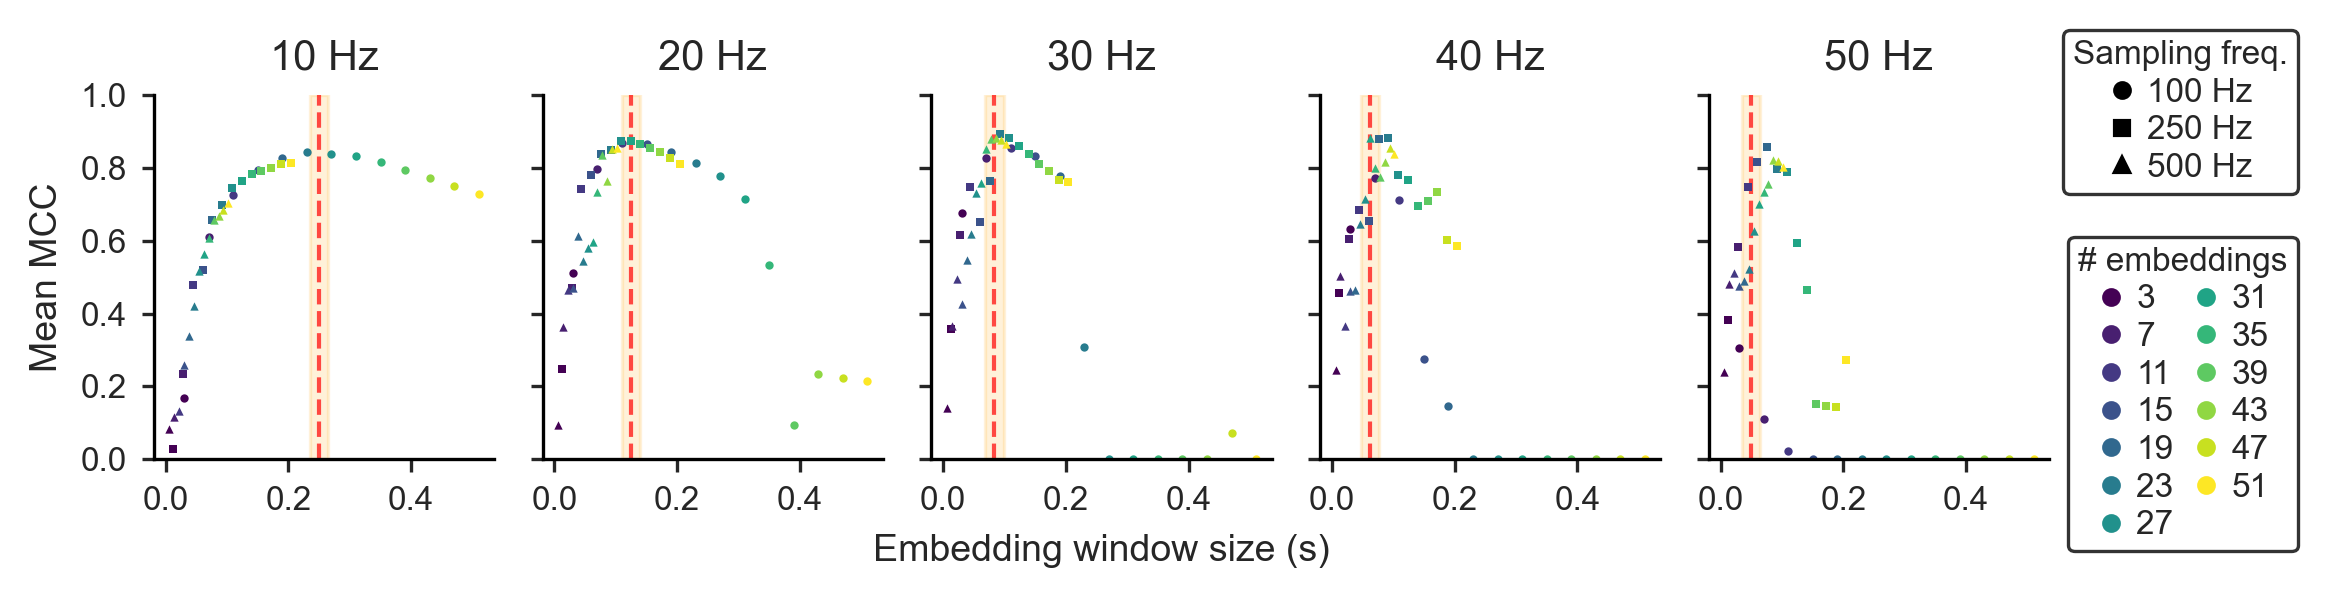

In [306]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.ticker import MultipleLocator

plt.rcParams["axes.edgecolor"] = "black"

# =========================
# CONFIG
# =========================
TRUTH_CYCLES = 2.5          # vertical red line at TRUTH_CYCLES / burst_f (seconds)
SCATTER_SIZE = 4            # points in panels
LEG_FSIZE = 8
TITLE_FSIZE = 8
LEG_MARKERSIZE = 3.5        # marker size inside legends
RIGHT_MARGIN = 0.82         # reserve space for legends (tune 0.78–0.86)
ANCHOR_X = 0.91             # legend x position (keep near 1.0 to avoid wide save)

# =========================
# STABLE ORDERING
# =========================
methods   = list(mean_df["method"].dropna().unique())
burst_fs  = np.sort(mean_df["burst_f"].dropna().unique())
num_embs  = np.sort(mean_df["num_emb"].dropna().unique())
fs_levels = np.sort(mean_df["fs"].dropna().unique())

BAND_HALF_WIDTH = 0.015   # 5 ms on each side -> total 10 ms


# =========================
# COLOR PALETTE (num_emb)
# =========================
cmap = plt.get_cmap("viridis")
if len(num_embs) == 1:
    palette = {num_embs[0]: cmap(0.5)}
else:
    palette = {emb: cmap(i / (len(num_embs) - 1)) for i, emb in enumerate(num_embs)}

# =========================
# MARKER MAP (fs)
# =========================
marker_cycle = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*", "h"]
if len(fs_levels) > len(marker_cycle):
    raise ValueError(f"Too many fs levels ({len(fs_levels)}). Add more markers.")
marker_map = {fs: marker_cycle[i] for i, fs in enumerate(fs_levels)}

# =========================
# FIGURE
# =========================
fig, axes = plt.subplots(
    len(methods), len(burst_fs),
    figsize=(FIG_WIDTH+1, 2),   # you control FIG_WIDTH externally
    sharex=True, sharey=True
)
axes = np.atleast_2d(axes)

# =========================
# PLOTTING
# =========================
for i, method in enumerate(methods):
    for j, bf in enumerate(burst_fs):
        ax = axes[i, j]
        sub_df = mean_df[(mean_df["method"] == method) & (mean_df["burst_f"] == bf)]

        ax.yaxis.set_major_locator(MultipleLocator(0.2))
        ax.xaxis.set_major_locator(MultipleLocator(0.2))
        ax.set_ylim(0, 1)

        # reference: TRUTH_CYCLES cycles of the simulated burst frequency
        ref_x = TRUTH_CYCLES / bf
        # faint orange band: ±5 ms around reference
        ax.axvspan(
            ref_x - BAND_HALF_WIDTH,
            ref_x + BAND_HALF_WIDTH,
            color="orange",
            alpha=0.15,
            zorder=0
        )

        ax.axvline(
            x=ref_x,
            color="red",
            linestyle="--",
            linewidth=1.0,
            alpha=0.7,
            zorder=1
        )

        # color encodes num_emb, shape encodes fs
        for (emb, fs), g in sub_df.groupby(["num_emb", "fs"], dropna=False):
            ax.scatter(
                g["window_size"], g["mean_mcc"],
                color=palette[emb],
                marker=marker_map[fs],
                s=SCATTER_SIZE,
                linewidths=0
            )

        if i == 0:
            ax.set_title(f"{bf:g} Hz")
        if j == 0:
            ax.set_ylabel("Mean MCC")

# x-label: bottom row, middle column
axes[-1, len(burst_fs)//2].set_xlabel("Embedding window size (s)")

# =========================
# LAYOUT: reserve legend strip on the right
# =========================
fig.subplots_adjust(right=RIGHT_MARGIN)
plt.tight_layout(rect=[0, 0, RIGHT_MARGIN, 1])

# =========================
# LEGENDS (your version)
# =========================
emb_handles = [
    mlines.Line2D(
        [], [], color=palette[emb], marker="o", linestyle="None",
        markersize=LEG_MARKERSIZE, label=f"{int(emb)}"
    )
    for emb in num_embs
]

leg1 = fig.legend(
    handles=emb_handles,
    title="# embeddings",
    loc="center right",
    bbox_to_anchor=(ANCHOR_X, 0.35),
    ncol=2,
    frameon=True,

    fontsize=LEG_FSIZE,
    title_fontsize=TITLE_FSIZE,

    borderpad=0.3,
    labelspacing=0.20,
    handletextpad=0.35,
    columnspacing=0.60,
    handlelength=0.8
)
leg1.get_frame().set_edgecolor("black")

fs_handles = [
    mlines.Line2D(
        [], [], color="black", marker=marker_map[fs], linestyle="None",
        markersize=LEG_MARKERSIZE, label=f"{int(fs)} Hz"
    )
    for fs in fs_levels
]

leg2 = fig.legend(
    handles=fs_handles,
    title="Sampling freq.",
    loc="center right",
    bbox_to_anchor=(ANCHOR_X, 0.82),
    ncol=1,
    frameon=True,

    fontsize=LEG_FSIZE,
    title_fontsize=TITLE_FSIZE,

    borderpad=0.3,
    labelspacing=0.20,
    handletextpad=0.35,
    handlelength=0.8
)
leg2.get_frame().set_edgecolor("black")

# =========================
# SAVE + SHOW
# =========================
fig.savefig(
    f"../figures/raw_figure/{sim_cond}_results.png",
    bbox_inches="tight",
    pad_inches=0.05,
)

plt.show()


/var/folders/5z/yggynsqj6632pbql_bb3kqm40000gn/T/ipykernel_90334/2753738861.py:307: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(savepath, dpi=300, bbox_inches="tight", pad_inches=0.03)
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


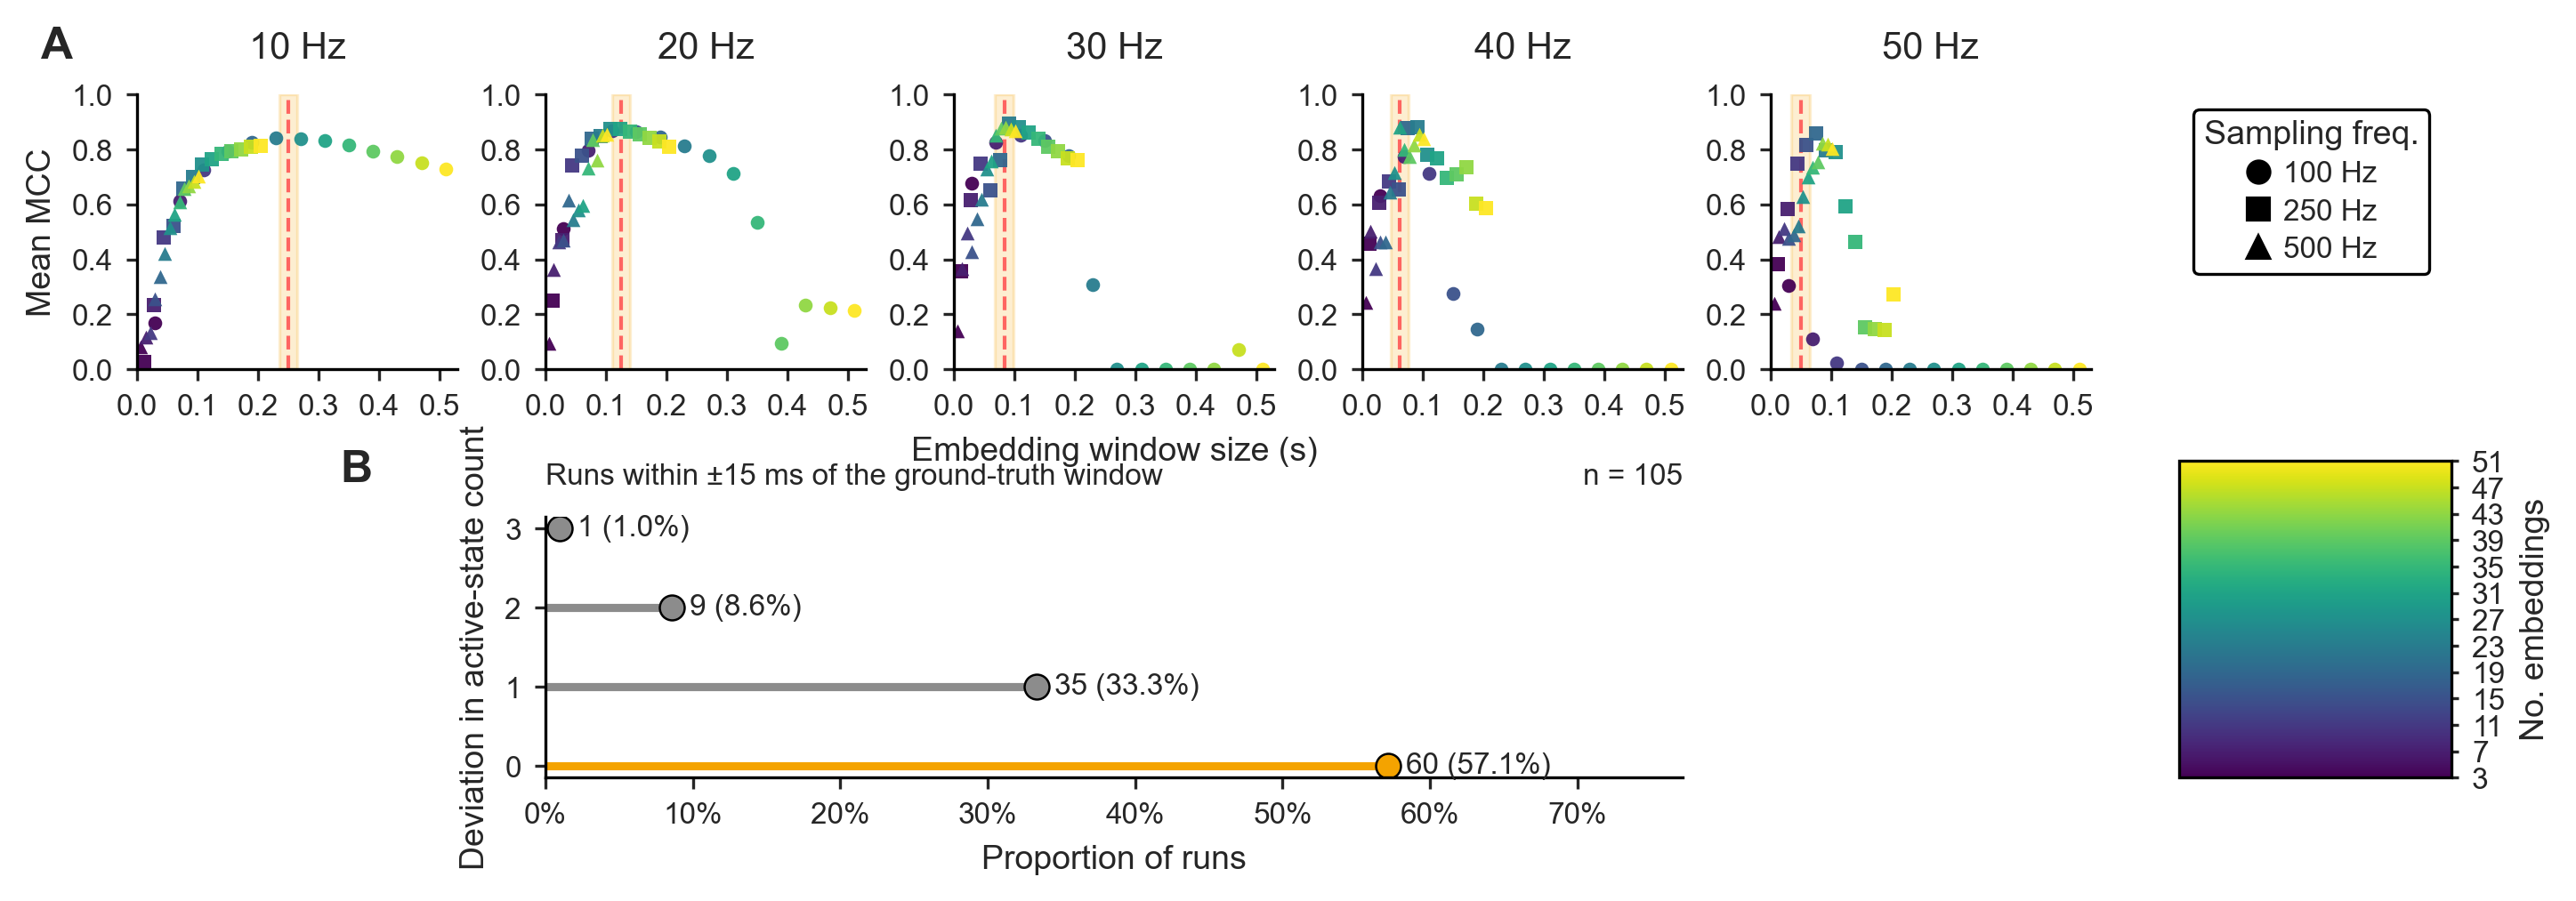

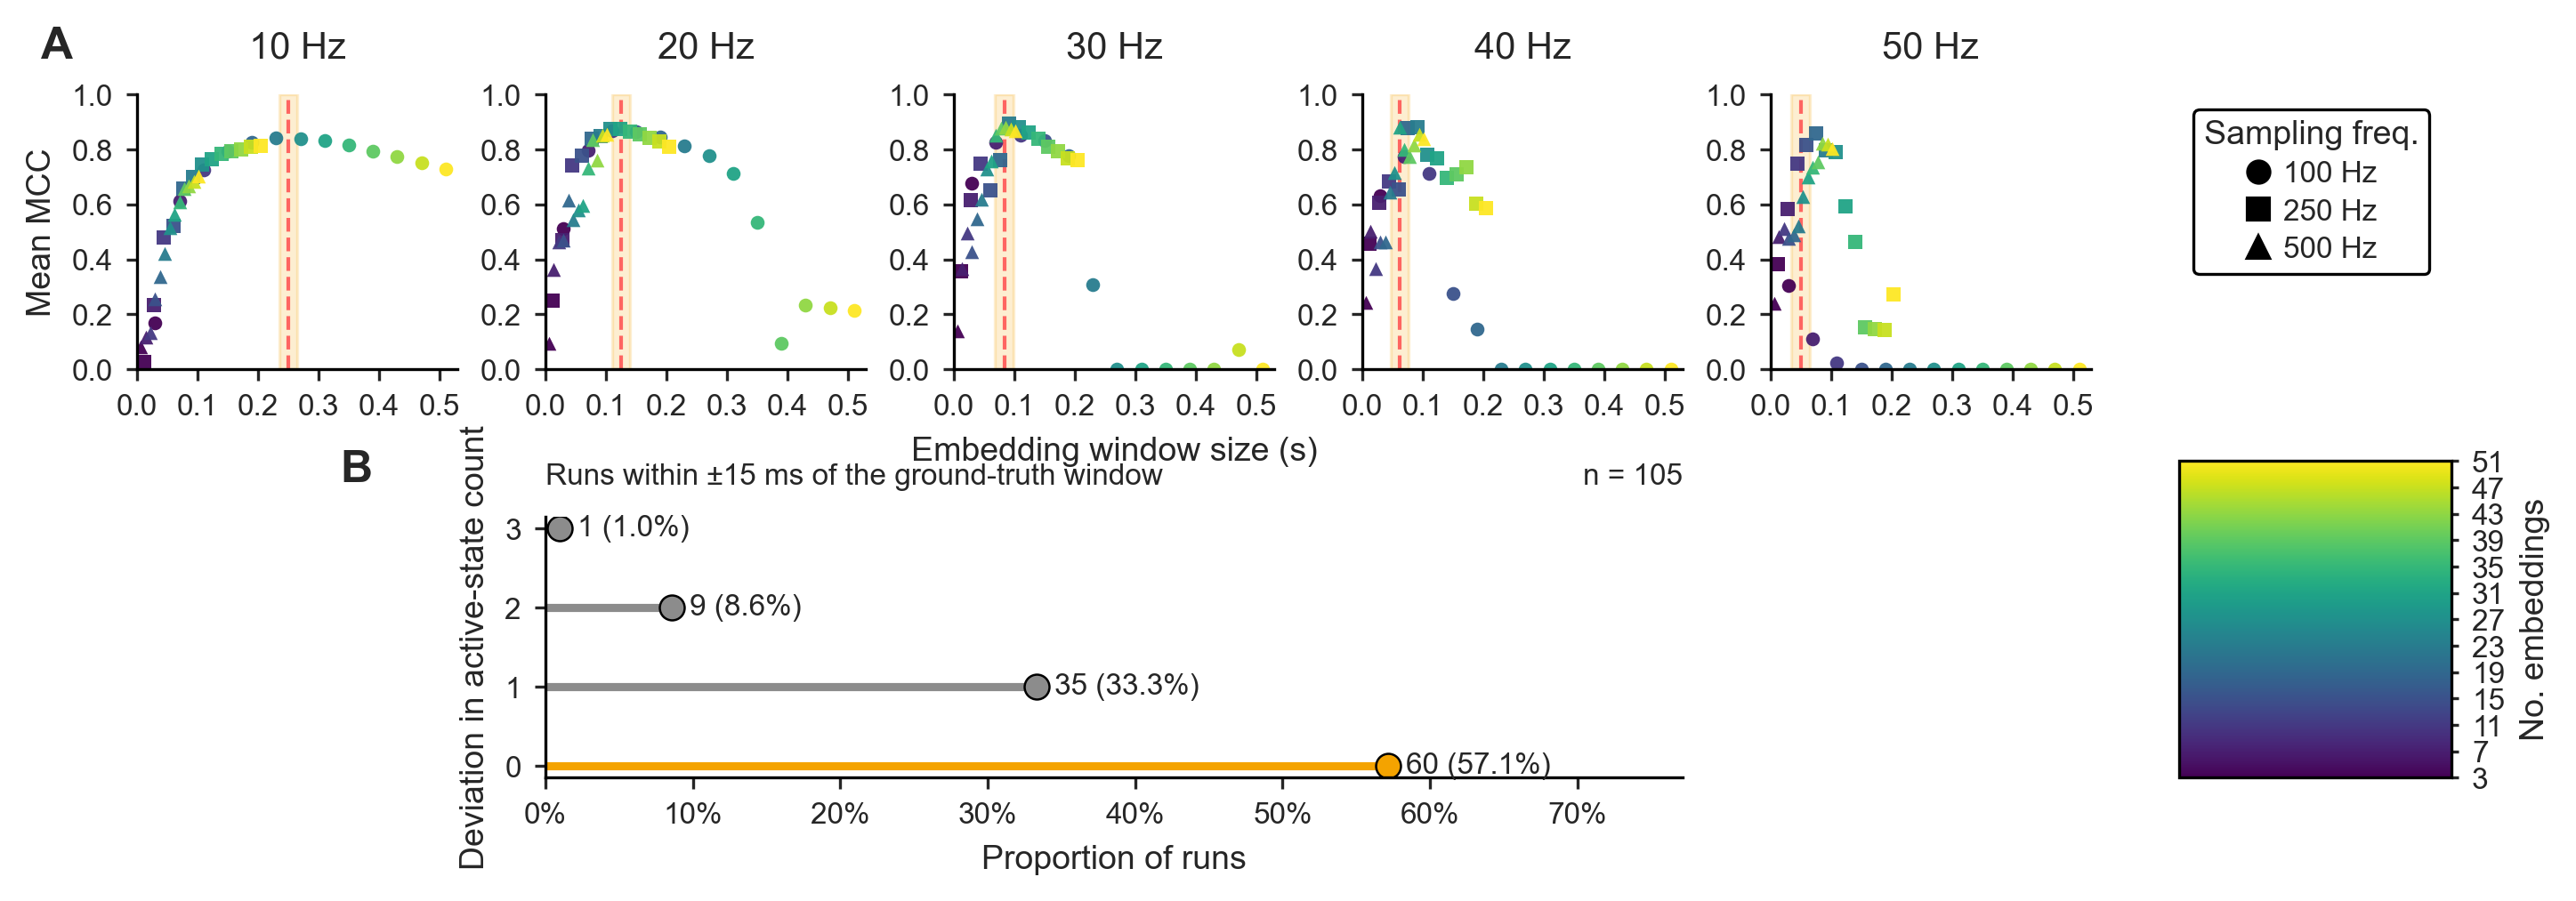

In [307]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.ticker import MultipleLocator, PercentFormatter
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

def plot_manuscript_composite_lollipop(
    mean_df,
    df,
    sim_cond=None,
    savepath=None,
    truth_cycles=2.5,
    band_half_width=0.015,   # 0.015 = ±15 ms
    scatter_size=14,
):
    mean_df = mean_df.copy()
    df = df.copy()

    # -------------------------
    # checks
    # -------------------------
    mean_required = {"burst_f", "num_emb", "fs", "mean_mcc"}
    raw_required  = {"burst_f", "num_emb", "fs", "num_states_active"}

    missing_mean = mean_required - set(mean_df.columns)
    missing_raw  = raw_required  - set(df.columns)

    if missing_mean:
        raise ValueError(f"mean_df is missing columns: {sorted(missing_mean)}")
    if missing_raw:
        raise ValueError(f"df is missing columns: {sorted(missing_raw)}")

    if "method" not in mean_df.columns:
        mean_df["method"] = "method"
    if "method" not in df.columns:
        df["method"] = "method"

    if "window_size" not in mean_df.columns:
        mean_df["window_size"] = mean_df["num_emb"] / mean_df["fs"]
    if "window_size" not in df.columns:
        df["window_size"] = df["num_emb"] / df["fs"]

    methods   = list(mean_df["method"].dropna().unique())
    burst_fs  = np.sort(mean_df["burst_f"].dropna().unique())
    num_embs  = np.sort(mean_df["num_emb"].dropna().unique())
    fs_levels = np.sort(mean_df["fs"].dropna().unique())

    # -------------------------
    # style
    # -------------------------
    plt.rcParams.update({
        "font.size": 8,
        "axes.labelsize": 9,
        "axes.titlesize": 10,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "legend.title_fontsize": 9,
        "axes.edgecolor": "black",
        "axes.linewidth": 0.8,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

    ORANGE = "#F4A300"
    RED    = "#FF4D4D"
    GRAY   = "0.55"
    cmap   = plt.get_cmap("viridis")

    # -------------------------
    # palette / markers
    # -------------------------
    if len(num_embs) == 1:
        norm = Normalize(vmin=num_embs[0] - 0.5, vmax=num_embs[0] + 0.5)
        palette = {num_embs[0]: cmap(0.5)}
    else:
        norm = Normalize(vmin=num_embs.min(), vmax=num_embs.max())
        palette = {emb: cmap(norm(emb)) for emb in num_embs}

    marker_cycle = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*", "h"]
    if len(fs_levels) > len(marker_cycle):
        raise ValueError(f"Too many fs levels ({len(fs_levels)}). Add more markers.")
    marker_map = {fs: marker_cycle[i] for i, fs in enumerate(fs_levels)}

    # -------------------------
    # figure layout
    # -------------------------
    n_methods = len(methods)
    n_burst   = len(burst_fs)

    fig_w = 1.7 * n_burst + 1.7
    fig_h = 1.75 * n_methods + 1.45

    fig = plt.figure(figsize=(fig_w, fig_h))
    gs = fig.add_gridspec(
        nrows=n_methods + 1,
        ncols=n_burst + 1,
        width_ratios=[1] * n_burst + [0.85],
        height_ratios=[1] * n_methods + [0.95],
        wspace=0.28,
        hspace=0.55,
    )

    # -------------------------
    # panel A: scatter panels
    # -------------------------
    axes = np.empty((n_methods, n_burst), dtype=object)
    first_ax = None

    x_min = max(0, mean_df["window_size"].min() - 0.02)
    x_max = mean_df["window_size"].max() + 0.02
    x_step = 0.1 if x_max <= 0.6 else 0.2

    for i, method in enumerate(methods):
        for j, bf in enumerate(burst_fs):
            if first_ax is None:
                ax = fig.add_subplot(gs[i, j])
                first_ax = ax
            else:
                ax = fig.add_subplot(gs[i, j], sharex=first_ax, sharey=first_ax)

            axes[i, j] = ax

            sub_df = mean_df[
                (mean_df["method"] == method) &
                (mean_df["burst_f"] == bf)
            ].copy()

            ref_x = truth_cycles / bf

            ax.axvspan(
                ref_x - band_half_width,
                ref_x + band_half_width,
                color=ORANGE,
                alpha=0.18,
                zorder=0
            )
            ax.axvline(
                ref_x,
                color=RED,
                linestyle="--",
                linewidth=1.0,
                alpha=0.85,
                zorder=1
            )

            for (emb, fs), g in sub_df.groupby(["num_emb", "fs"], dropna=False):
                ax.scatter(
                    g["window_size"],
                    g["mean_mcc"],
                    color=palette[emb],
                    marker=marker_map[fs],
                    s=scatter_size,
                    linewidths=0,
                    alpha=0.95,
                    zorder=2,
                )

            ax.set_xlim(x_min, x_max)
            ax.set_ylim(0, 1.0)
            ax.xaxis.set_major_locator(MultipleLocator(x_step))
            ax.yaxis.set_major_locator(MultipleLocator(0.2))
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            if i == 0:
                ax.set_title(f"{bf:g} Hz", pad=10)

            if j == 0:
                if n_methods == 1:
                    ax.set_ylabel("Mean MCC")
                else:
                    ax.set_ylabel(f"{method}\nMean MCC")

            if i < n_methods - 1:
                ax.tick_params(labelbottom=False)

    axes[-1, n_burst // 2].set_xlabel("Embedding window size (s)")
    axes[0, 0].text(
        -0.30, 1.10, "A",
        transform=axes[0, 0].transAxes,
        fontsize=12, fontweight="bold",
        ha="left", va="bottom"
    )

    # -------------------------
    # panel B: compact lollipop
    # centered under middle columns
    # -------------------------
    if n_burst >= 5:
        ax_sum = fig.add_subplot(gs[-1, 1:4])
    elif n_burst >= 3:
        ax_sum = fig.add_subplot(gs[-1, :3])
    else:
        ax_sum = fig.add_subplot(gs[-1, :-1])

    band_df = df.loc[
        np.abs(df["window_size"] - (truth_cycles / df["burst_f"])) <= band_half_width
    ].copy()

    if len(band_df) == 0:
        raise ValueError("No rows fall inside the selected band.")

    band_df["num_states_active_diff"] = band_df["num_states_active"] - 2

    diff = band_df["num_states_active_diff"].dropna().astype(int)
    order = np.arange(diff.min(), diff.max() + 1)
    counts = diff.value_counts().reindex(order, fill_value=0).sort_index()
    props = counts / counts.sum()

    y = np.arange(len(order))

    for yi, d, p, c in zip(y, order, props.values, counts.values):
        color = ORANGE if d == 0 else GRAY
        ax_sum.hlines(yi, 0, p, color=color, lw=2.2, zorder=1)
        ax_sum.scatter(p, yi, s=45, color=color, edgecolor="black", linewidth=0.6, zorder=2)
        ax_sum.text(
            p + 0.012, yi,
            f"{c} ({100*p:.1f}%)",
            va="center", ha="left", fontsize=8
        )

    ax_sum.set_yticks(y)
    ax_sum.set_yticklabels([str(d) for d in order])
    ax_sum.set_xlabel("Proportion of runs")
    ax_sum.set_ylabel("Deviation in active-state count")
    ax_sum.xaxis.set_major_formatter(PercentFormatter(1.0))
    ax_sum.set_xlim(0, max(props.max() * 1.35, 0.35))

    ax_sum.spines["top"].set_visible(False)
    ax_sum.spines["right"].set_visible(False)

    band_ms = int(round(1000 * band_half_width))
    ax_sum.text(
        0.00, 1.10,
        f"Runs within ±{band_ms} ms of the ground-truth window",
        transform=ax_sum.transAxes,
        ha="left", va="bottom", fontsize=8
    )
    ax_sum.text(
        1.00, 1.10,
        f"n = {len(diff)}",
        transform=ax_sum.transAxes,
        ha="right", va="bottom", fontsize=8
    )

    ax_sum.text(
        -0.18, 1.10, "B",
        transform=ax_sum.transAxes,
        fontsize=12, fontweight="bold",
        ha="left", va="bottom"
    )

    # -------------------------
    # side column: legend + colorbar
    # -------------------------
    side = gs[:, -1].subgridspec(
        nrows=2, ncols=1,
        height_ratios=[0.9, 1.15],
        hspace=0.42
    )

    ax_leg = fig.add_subplot(side[0, 0])
    ax_leg.axis("off")

    fs_handles = [
        mlines.Line2D(
            [], [], color="black",
            marker=marker_map[fs],
            linestyle="None",
            markersize=5.8,
            label=f"{int(fs)} Hz"
        )
        for fs in fs_levels
    ]

    leg = ax_leg.legend(
        handles=fs_handles,
        title="Sampling freq.",
        loc="upper left",
        frameon=True,
        borderpad=0.35,
        labelspacing=0.35,
        handletextpad=0.45,
        handlelength=0.8,
    )
    leg.get_frame().set_edgecolor("black")
    leg.get_frame().set_alpha(1.0)

    ax_cbar = fig.add_subplot(side[1, 0])
    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=ax_cbar, orientation="vertical")
    cbar.set_label("No. embeddings", fontsize=9)
    cbar.set_ticks(num_embs)
    cbar.ax.tick_params(labelsize=8, length=2)

    fig.subplots_adjust(left=0.08, right=0.93, bottom=0.14, top=0.94)

    if savepath is None and sim_cond is not None:
        savepath = f"../figures/raw_figure/{sim_cond}_composite_lollipop.png"

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight", pad_inches=0.03)

    plt.show()
    return fig


# -------------------------
# example call
# -------------------------
plot_manuscript_composite_lollipop(
    mean_df=mean_df,
    df=df,
    sim_cond=sim_cond,
    savepath=None,          # or e.g. "../figures/final/sim_result_composite.pdf"
    truth_cycles=2.5,
    band_half_width=0.015,  # ±15 ms
    scatter_size=14,
)

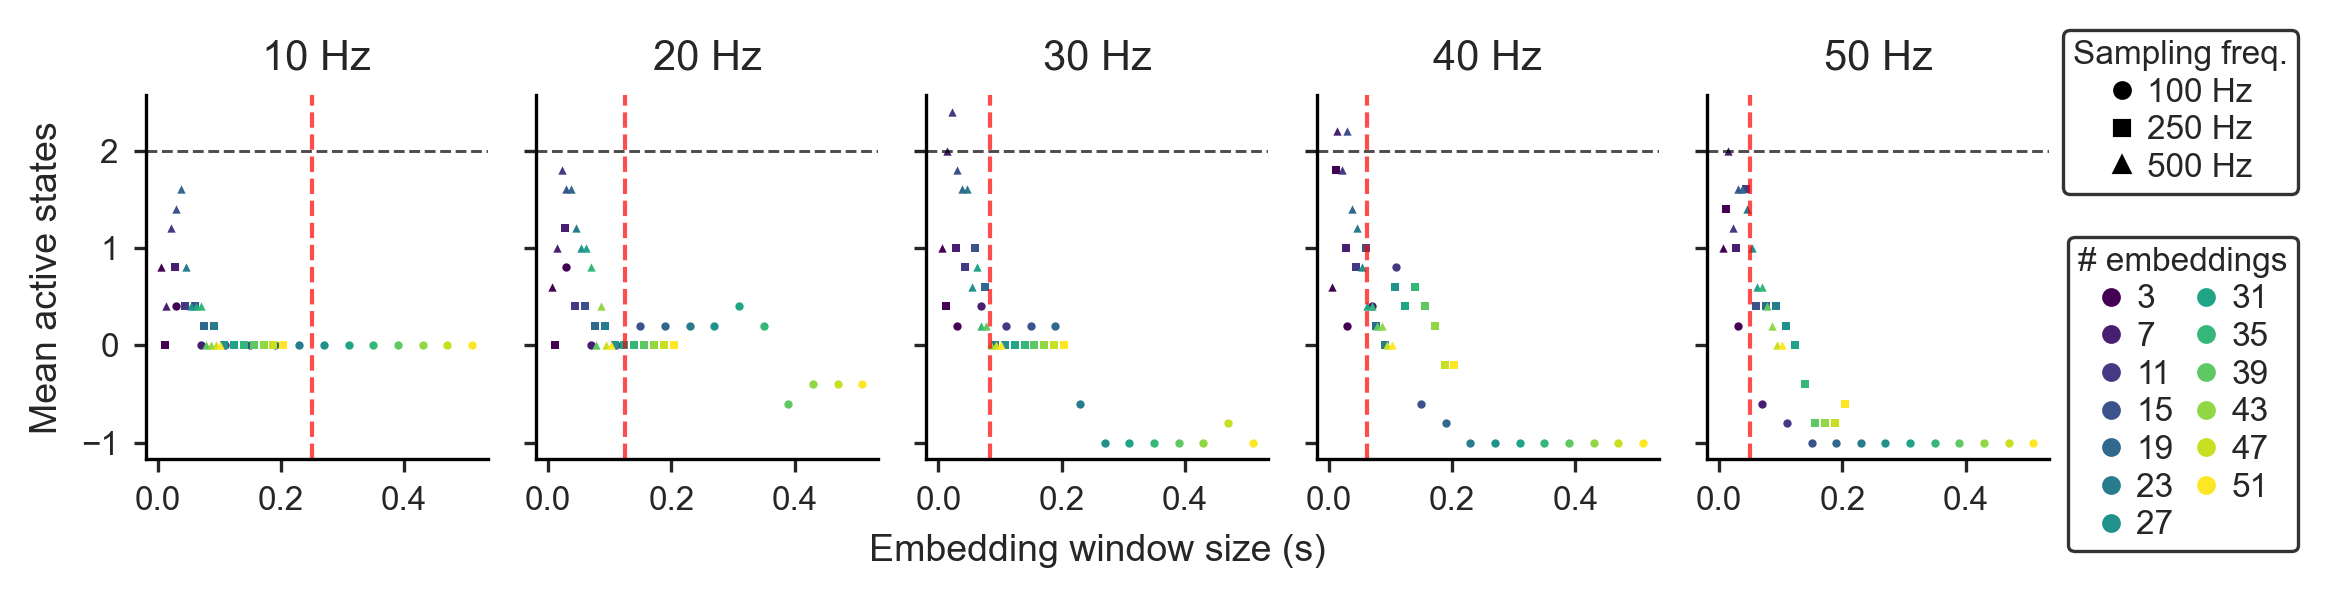

In [308]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.ticker import MultipleLocator

plt.rcParams["axes.edgecolor"] = "black"

# =========================
# CONFIG
# =========================
TRUTH_CYCLES = 2.5          # vertical red line at TRUTH_CYCLES / burst_f (seconds)
SCATTER_SIZE = 4            # points in panels
LEG_FSIZE = 8
TITLE_FSIZE = 8
LEG_MARKERSIZE = 3.5        # marker size inside legends
RIGHT_MARGIN = 0.82         # reserve space for legends (tune 0.78–0.86)
ANCHOR_X = 0.91             # legend x position (keep near 1.0 to avoid wide save)

# =========================
# STABLE ORDERING
# =========================
methods   = list(mean_df["method"].dropna().unique())
burst_fs  = np.sort(mean_df["burst_f"].dropna().unique())
num_embs  = np.sort(mean_df["num_emb"].dropna().unique())
fs_levels = np.sort(mean_df["fs"].dropna().unique())

# =========================
# COLOR PALETTE (num_emb)
# =========================
cmap = plt.get_cmap("viridis")
if len(num_embs) == 1:
    palette = {num_embs[0]: cmap(0.5)}
else:
    palette = {emb: cmap(i / (len(num_embs) - 1)) for i, emb in enumerate(num_embs)}

# =========================
# MARKER MAP (fs)
# =========================
marker_cycle = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*", "h"]
if len(fs_levels) > len(marker_cycle):
    raise ValueError(f"Too many fs levels ({len(fs_levels)}). Add more markers.")
marker_map = {fs: marker_cycle[i] for i, fs in enumerate(fs_levels)}

# =========================
# FIGURE
# =========================
fig, axes = plt.subplots(
    len(methods), len(burst_fs),
    figsize=(FIG_WIDTH+1, 2),   # you control FIG_WIDTH externally
    sharex=True, sharey=True
)
axes = np.atleast_2d(axes)

# =========================
# PLOTTING
# =========================
for i, method in enumerate(methods):
    for j, bf in enumerate(burst_fs):
        ax = axes[i, j]
        sub_df = mean_df[(mean_df["method"] == method) & (mean_df["burst_f"] == bf)]

        ax.yaxis.set_major_locator(MultipleLocator(1))
        ax.xaxis.set_major_locator(MultipleLocator(0.2))

        #ax.set_ylim(0, 1)

        # reference: TRUTH_CYCLES cycles of the simulated burst frequency
        ax.axvline(
            x=TRUTH_CYCLES / bf,
            color="red",
            linestyle="--",
            linewidth = 1,
            alpha=0.7
        )

        ax.axhline(
            y = 2,
            color="black",
            linestyle="--",
            linewidth=0.7,
            alpha=0.7
        )

        # color encodes num_emb, shape encodes fs
        for (emb, fs), g in sub_df.groupby(["num_emb", "fs"], dropna=False):
            ax.scatter(
                g["window_size"], g["mean_active_states_diff"],
                color=palette[emb],
                marker=marker_map[fs],
                s=SCATTER_SIZE,
                linewidths=0
            )

        if i == 0:
            ax.set_title(f"{bf:g} Hz")
        if j == 0:
            ax.set_ylabel("Mean active states")

# x-label: bottom row, middle column
axes[-1, len(burst_fs)//2].set_xlabel("Embedding window size (s)")

# =========================
# LAYOUT: reserve legend strip on the right
# =========================
fig.subplots_adjust(right=RIGHT_MARGIN)
plt.tight_layout(rect=[0, 0, RIGHT_MARGIN, 1])

# =========================
# LEGENDS (your version)
# =========================
emb_handles = [
    mlines.Line2D(
        [], [], color=palette[emb], marker="o", linestyle="None",
        markersize=LEG_MARKERSIZE, label=f"{int(emb)}"
    )
    for emb in num_embs
]

leg1 = fig.legend(
    handles=emb_handles,
    title="# embeddings",
    loc="center right",
    bbox_to_anchor=(ANCHOR_X, 0.35),
    ncol=2,
    frameon=True,

    fontsize=LEG_FSIZE,
    title_fontsize=TITLE_FSIZE,

    borderpad=0.3,
    labelspacing=0.20,
    handletextpad=0.35,
    columnspacing=0.60,
    handlelength=0.8
)
leg1.get_frame().set_edgecolor("black")

fs_handles = [
    mlines.Line2D(
        [], [], color="black", marker=marker_map[fs], linestyle="None",
        markersize=LEG_MARKERSIZE, label=f"{int(fs)} Hz"
    )
    for fs in fs_levels
]

leg2 = fig.legend(
    handles=fs_handles,
    title="Sampling freq.",
    loc="center right",
    bbox_to_anchor=(ANCHOR_X, 0.82),
    ncol=1,
    frameon=True,

    fontsize=LEG_FSIZE,
    title_fontsize=TITLE_FSIZE,

    borderpad=0.3,
    labelspacing=0.20,
    handletextpad=0.35,
    handlelength=0.8
)
leg2.get_frame().set_edgecolor("black")

# =========================
# SAVE + SHOW
# =========================
fig.savefig(
    f"../figures/raw_figure/{sim_cond}_results_active_states.png",
    bbox_inches="tight",
    pad_inches=0.05,
)

plt.show()


In [309]:
df.head()

,method,signal,true_states,burst_f,fs,snr,est_params,loss_best,model_id_best,seed_best,...,pred_t,total_time,num_states,num_emb,est_states,order,summary_stats,mcc,loss,num_states_active
0,DP-GMM,"[-1.0609110797619747, -0.9366573169036332, -1....","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",10,100,2,"{'alpha': 0.3327488, 'weights': [0.58107513, 0...",1.0388715,3,1294949329,...,0.479630,208.539275,10,3,"[0, 0, 0, 0, 1, 1, 0, 0, 2, 1, 0, 0, 0, 0, 0, ...","[0, 1, 2]",None,0.278203,1.0388715,3
1,DP-GMM,"[-1.0609110797619747, -0.9366573169036332, -1....","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",10,100,2,"{'alpha': 0.43607274, 'weights': [0.57460296, ...",0.92060703,6,3662778295,...,0.470522,240.966439,10,7,"[0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, ...","[0, 1]",None,0.620227,0.92060703,2
2,DP-GMM,"[-1.0609110797619747, -0.9366573169036332, -1....","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",10,100,2,"{'alpha': 0.38393718, 'weights': [0.6416584, 0...",0.87017757,8,3280534322,...,0.534986,263.985551,10,11,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, ...","[0, 1]",None,0.743840,0.87017757,2
3,DP-GMM,"[-1.0609110797619747, -0.9366573169036332, -1....","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",10,100,2,"{'alpha': 0.34910107, 'weights': [0.67004824, ...",0.8452438,5,3812921341,...,0.553054,287.700452,10,15,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, ...","[0, 1]",None,0.818288,0.8452438,2
4,DP-GMM,"[-1.0609110797619747, -0.9366573169036332, -1....","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",10,100,2,"{'alpha': 0.34097785, 'weights': [0.68662995, ...",0.83191717,7,2663218682,...,0.600937,323.647696,10,19,"[1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 1]",None,0.851378,0.83191717,2


Rows inside orange band: 30


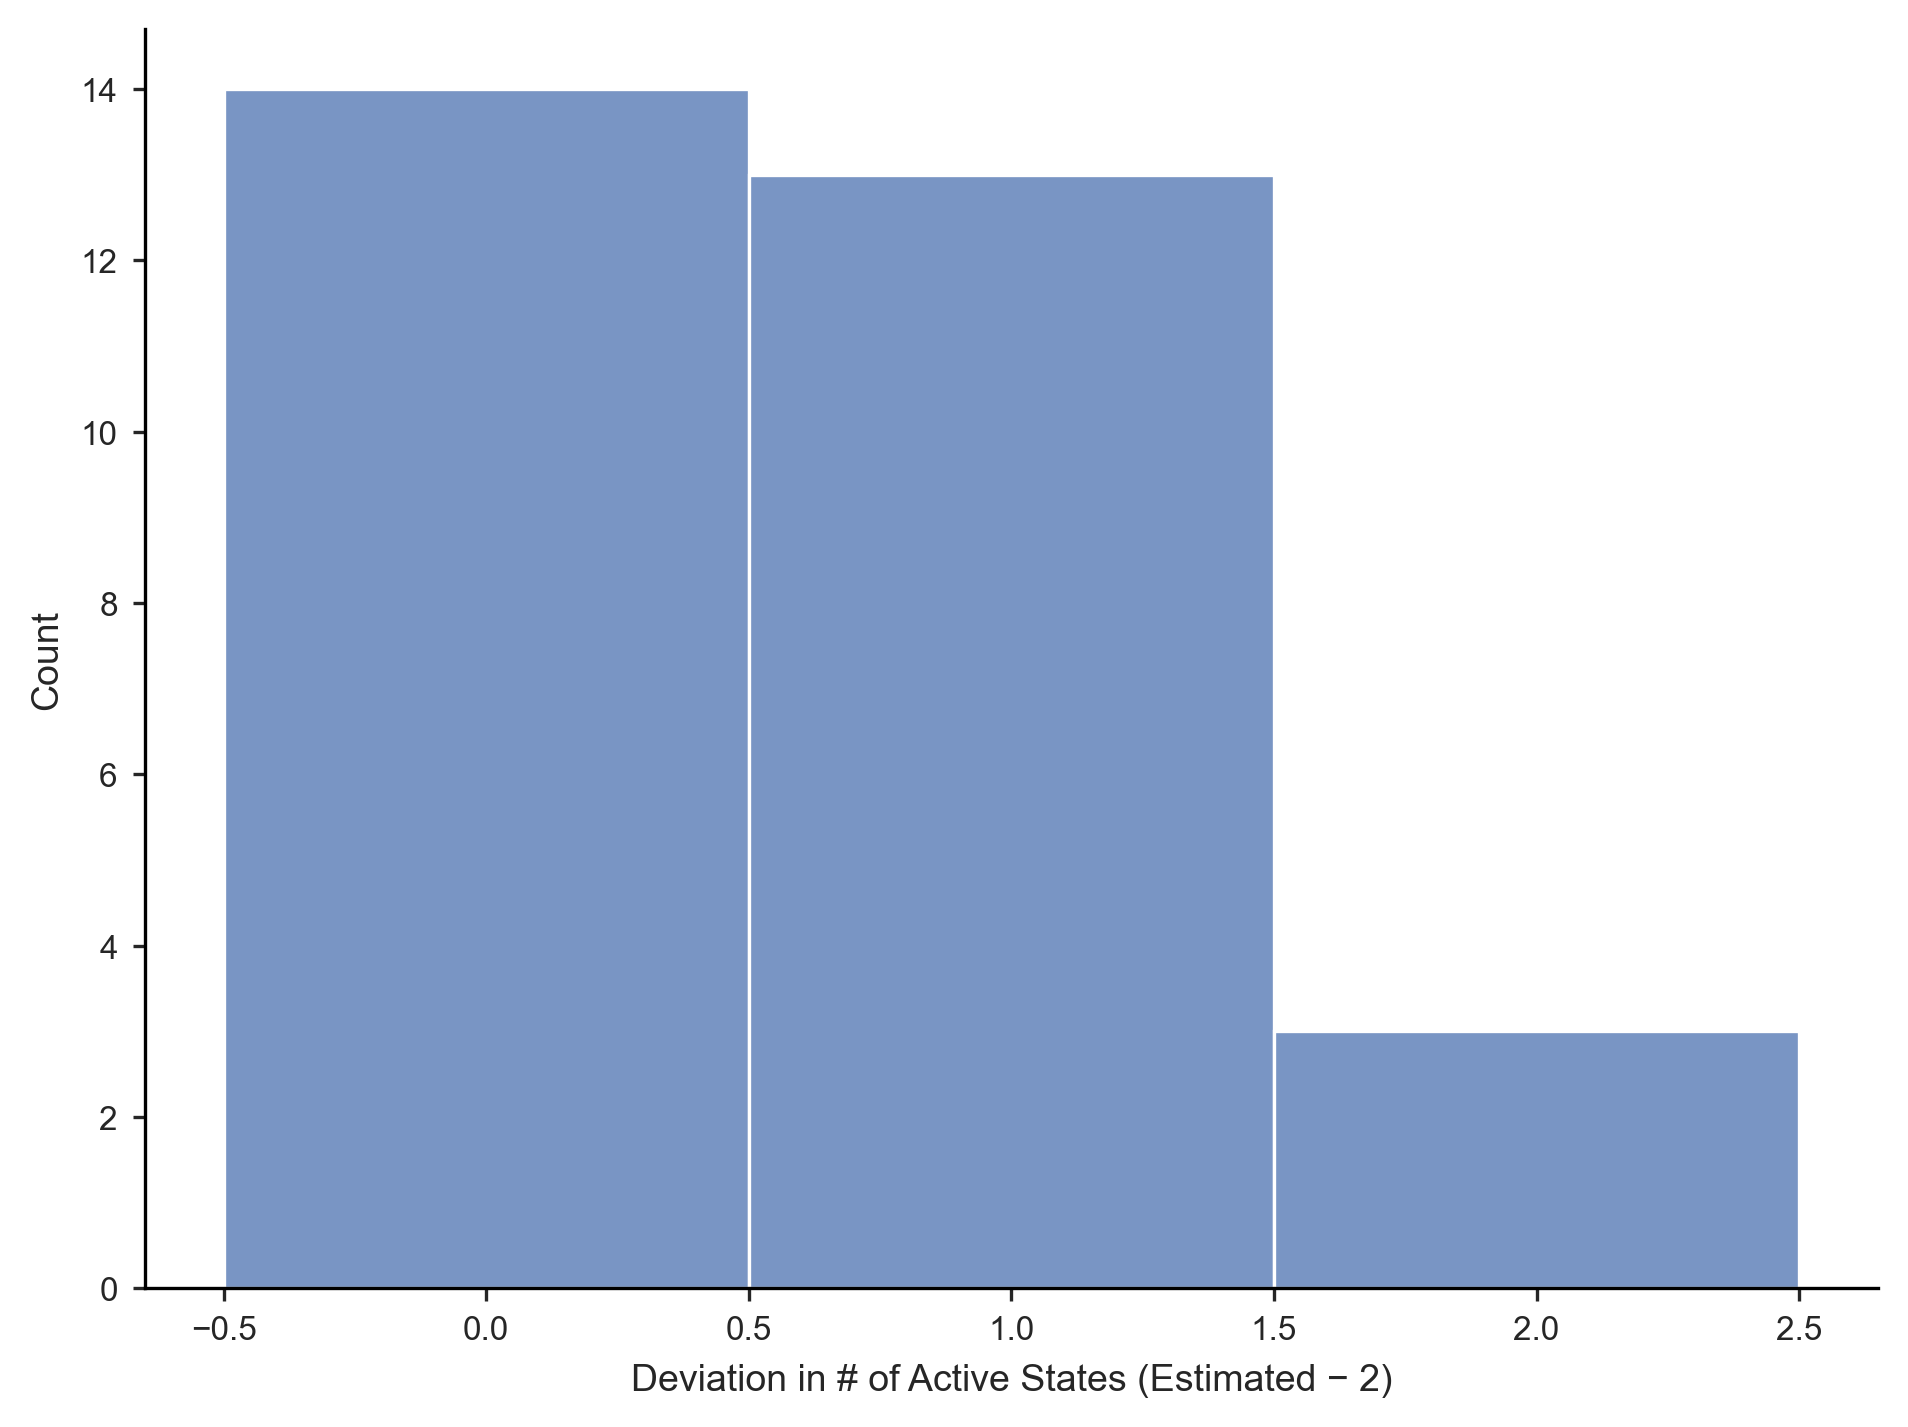

In [310]:
df["window_size"] = 1/ df["fs"].values * df["num_emb"].values


BAND_HALF_WIDTH = 0.005   # ±5 ms, total 10 ms

band_df = df.loc[
    np.abs(df["window_size"] - (TRUTH_CYCLES / df["burst_f"])) <= BAND_HALF_WIDTH
].copy()

band_df["num_states_active_diff"] = band_df["num_states_active"] - 2

print(f"Rows inside orange band: {len(band_df)}")

sns.histplot(data=band_df, x="num_states_active_diff", discrete=True)
plt.xlabel("Deviation in # of Active States (Estimated − 2)")
plt.ylabel("Count")
plt.show()

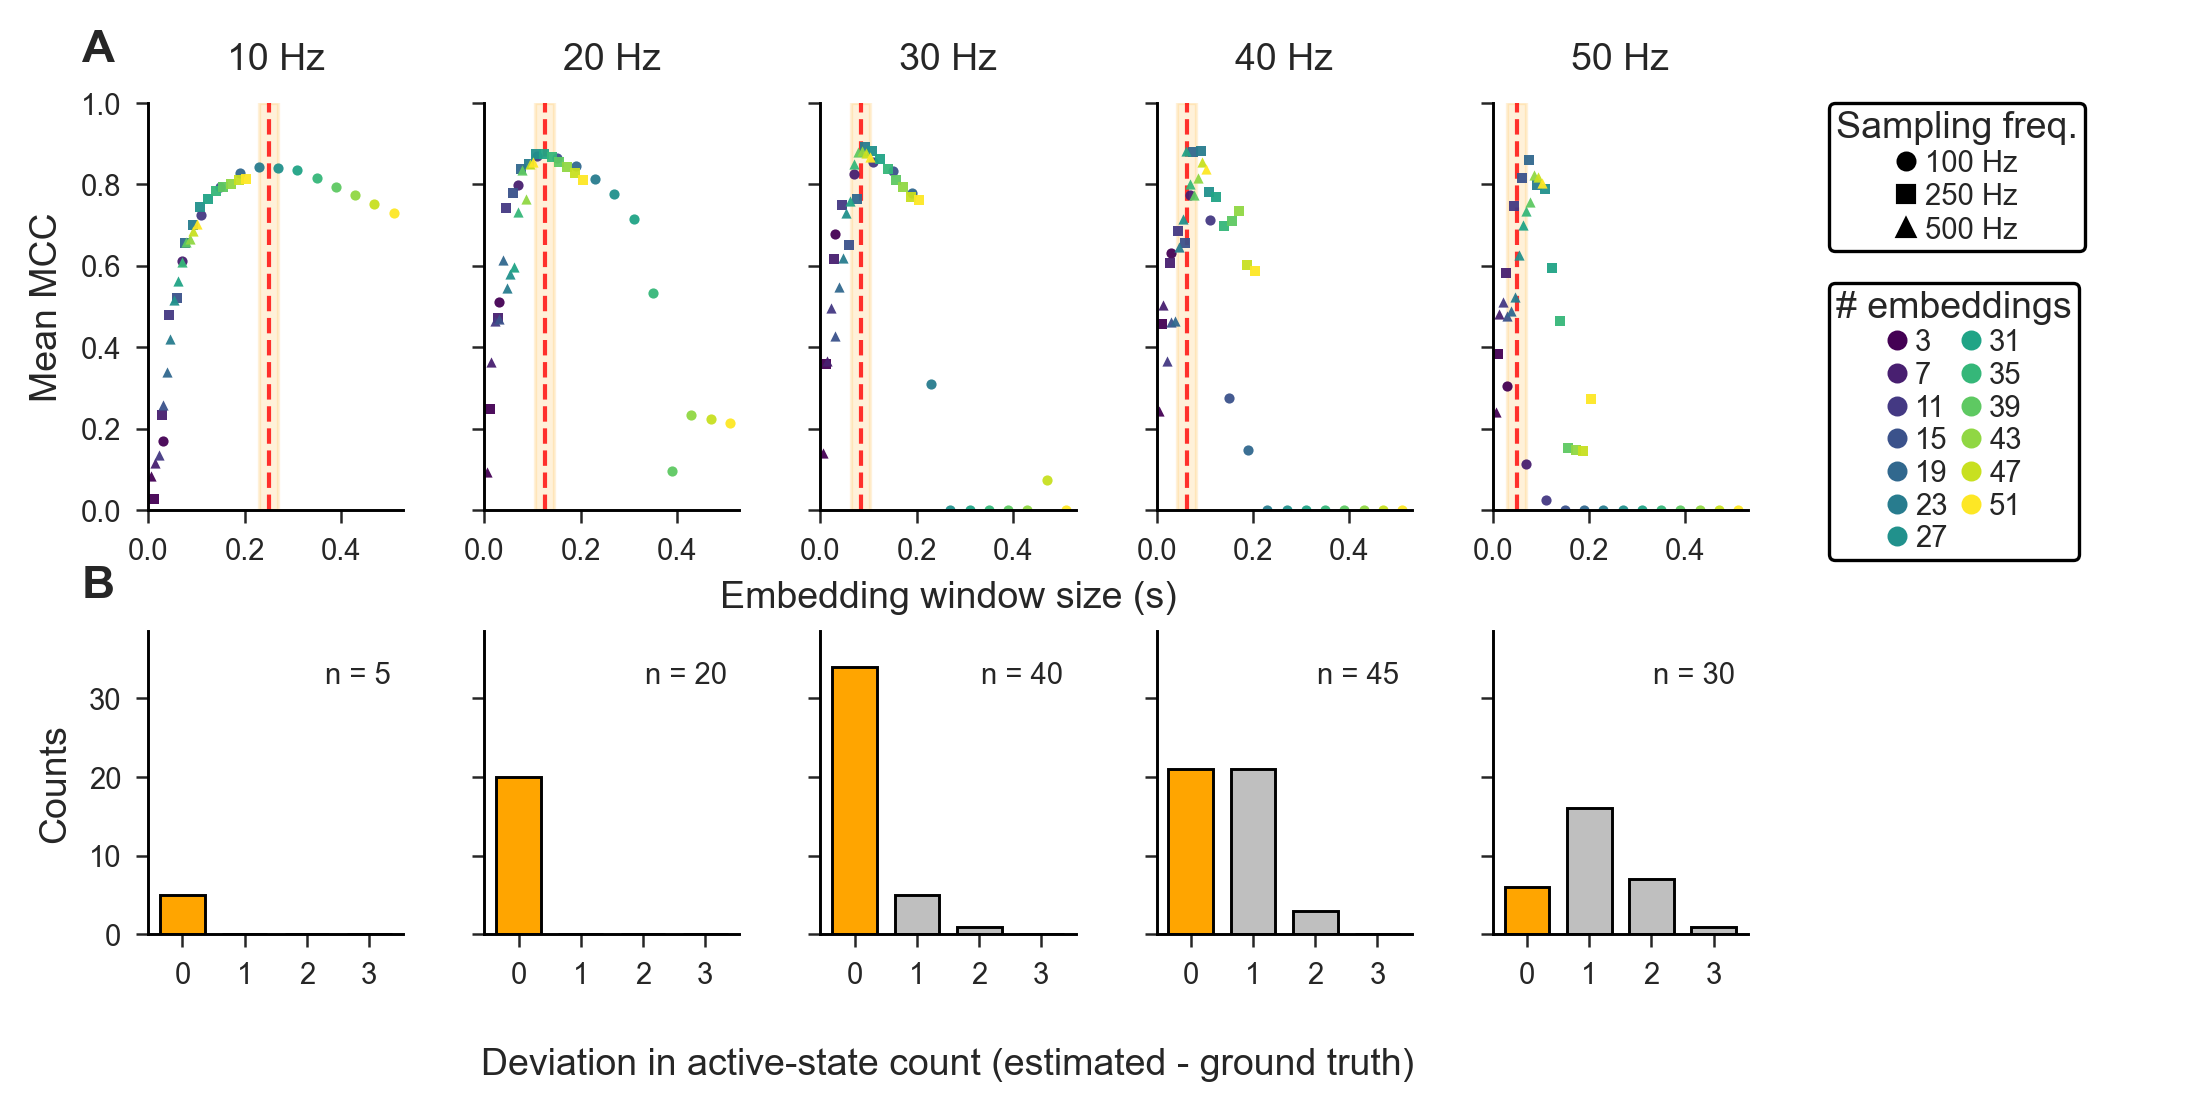

In [332]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.ticker import MultipleLocator, FormatStrFormatter

# =========================================================
# USER STYLE
# =========================================================
FIG_WIDTH = 7.5
FIG_HEIGHT = 3.6

MY_FONT_SIZE = 9
TICK_FONT_SIZE = 7
LEG_FONT_SIZE = 7
TITLE_FONT_SIZE = 9

plt.rcParams.update({
    # --- Fonts ---
    "font.family": "Arial",
    "font.size": MY_FONT_SIZE,

    # --- Legend ---
    "legend.fontsize": LEG_FONT_SIZE,
    "legend.frameon": False,

    # --- Titles ---
    "figure.titlesize": MY_FONT_SIZE,
    "axes.titleweight": "normal",
    "axes.titlesize": TITLE_FONT_SIZE,

    # --- Axes ---
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": True,
    "axes.spines.bottom": True,
    "axes.edgecolor": "black",
    "axes.linewidth": 0.7,
    "axes.unicode_minus": True,
    "axes.labelsize": MY_FONT_SIZE,

    # --- Lines & markers ---
    "lines.linewidth": 1.0,
    "lines.markersize": 0.7,

    # --- Ticks ---
    "xtick.labelsize": TICK_FONT_SIZE,
    "ytick.labelsize": TICK_FONT_SIZE,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.bottom": True,
    "ytick.left": True,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,

    # --- Grid ---
    "axes.grid": False,

    # --- Layout ---
    "figure.autolayout": False,

    # --- DPI ---
    "savefig.dpi": 900,
    "figure.dpi": 300,
})

# =========================================================
# CONFIG
# =========================================================
TRUTH_CYCLES = 2.5
BAND_HALF_WIDTH = 0.02   # 0.02 s = ±20 ms
SCATTER_SIZE = 13

LEG_MARKERSIZE = 3.8
TRUTH_BAND_COLOR = "orange"
TRUTH_LINE_COLOR = "red"
BAR_COLOR = "0.75"

METHOD_TO_PLOT = mean_df["method"].dropna().unique()[0]

# =========================================================
# COPY DATA
# =========================================================
mean_df = mean_df.copy()
df = df.copy()

if "window_size" not in mean_df.columns:
    mean_df["window_size"] = mean_df["num_emb"] / mean_df["fs"]

if "window_size" not in df.columns:
    df["window_size"] = df["num_emb"] / df["fs"]

df["num_states_active_diff"] = df["num_states_active"] - 2

mean_sub = mean_df[mean_df["method"] == METHOD_TO_PLOT].copy()
if "method" in df.columns:
    df_sub = df[df["method"] == METHOD_TO_PLOT].copy()
else:
    df_sub = df.copy()

# =========================================================
# ORDERING
# =========================================================
burst_fs = np.sort(mean_sub["burst_f"].dropna().unique())
num_embs = np.sort(mean_sub["num_emb"].dropna().unique())
fs_levels = np.sort(mean_sub["fs"].dropna().unique())

# =========================================================
# COLOR PALETTE (num_emb)
# =========================================================
cmap = plt.get_cmap("viridis")
if len(num_embs) == 1:
    palette = {num_embs[0]: cmap(0.5)}
else:
    palette = {emb: cmap(i / (len(num_embs) - 1)) for i, emb in enumerate(num_embs)}

# =========================================================
# MARKER MAP (fs)
# =========================================================
marker_cycle = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*", "h"]
if len(fs_levels) > len(marker_cycle):
    raise ValueError(f"Too many fs levels ({len(fs_levels)}). Add more markers.")
marker_map = {fs: marker_cycle[i] for i, fs in enumerate(fs_levels)}

# =========================================================
# PRECOMPUTE BOTTOM COUNTS
# =========================================================
bottom_counts = {}
global_devs = set()
max_count = 0

for bf in burst_fs:
    tmp = df_sub[df_sub["burst_f"] == bf].copy()
    ref_x = TRUTH_CYCLES / bf

    band_tmp = tmp.loc[
        np.abs(tmp["window_size"] - ref_x) <= BAND_HALF_WIDTH
    ].copy()

    x = band_tmp["num_states_active_diff"].dropna().astype(int)

    if len(x) == 0:
        bottom_counts[bf] = {"counts": None, "n": 0}
        continue

    order = np.arange(x.min(), x.max() + 1)
    counts = x.value_counts().reindex(order, fill_value=0).sort_index()

    bottom_counts[bf] = {"counts": counts, "n": len(x)}
    global_devs.update(order.tolist())
    max_count = max(max_count, counts.max())

if len(global_devs) == 0:
    raise ValueError("No runs fall inside the selected window band.")

global_order = np.arange(min(global_devs), max(global_devs) + 1)

# =========================================================
# FIGURE LAYOUT
# =========================================================
fig = plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT))
gs = fig.add_gridspec(
    nrows=2,
    ncols=len(burst_fs) + 1,
    width_ratios=[1, 1, 1, 1, 1, 1.35],   # wider legend column
    height_ratios=[1.18, 0.88],
    wspace=0.30,
    hspace=0.34,
)

top_axes = []
bottom_axes = []

# =========================================================
# TOP ROW
# =========================================================
x_min = max(0, mean_sub["window_size"].min() - 0.02)
x_max = mean_sub["window_size"].max() + 0.02
x_step = 0.2   # force sparser x ticks to avoid overlap

first_top_ax = None
for j, bf in enumerate(burst_fs):
    if first_top_ax is None:
        ax = fig.add_subplot(gs[0, j])
        first_top_ax = ax
    else:
        ax = fig.add_subplot(gs[0, j], sharex=first_top_ax, sharey=first_top_ax)

    top_axes.append(ax)
    sub_df = mean_sub[mean_sub["burst_f"] == bf].copy()
    ref_x = TRUTH_CYCLES / bf

    ax.axvspan(
        ref_x - BAND_HALF_WIDTH,
        ref_x + BAND_HALF_WIDTH,
        color=TRUTH_BAND_COLOR,
        alpha=0.15,
        zorder=0,
    )
    ax.axvline(
        x=ref_x,
        color=TRUTH_LINE_COLOR,
        linestyle="--",
        linewidth=1.0,
        alpha=0.8,
        zorder=1,
    )

    for (emb, fs), g in sub_df.groupby(["num_emb", "fs"], dropna=False):
        ax.scatter(
            g["window_size"],
            g["mean_mcc"],
            color=palette[emb],
            marker=marker_map[fs],
            s=SCATTER_SIZE-7,
            linewidths=0,
            alpha=0.95,
            zorder=2,
        )

    ax.set_title(f"{bf:g} Hz", pad=8)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0, 1.0)
    ax.xaxis.set_major_locator(MultipleLocator(x_step))
    ax.xaxis.set_major_formatter(FormatStrFormatter("%.1f"))
    ax.yaxis.set_major_locator(MultipleLocator(0.2))
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))

    if j == 0:
        ax.set_ylabel("Mean MCC")
    else:
        ax.tick_params(labelleft=False)

# =========================================================
# BOTTOM ROW
# =========================================================
first_bottom_ax = None
for j, bf in enumerate(burst_fs):
    if first_bottom_ax is None:
        ax = fig.add_subplot(gs[1, j])
        first_bottom_ax = ax
    else:
        ax = fig.add_subplot(gs[1, j], sharex=first_bottom_ax, sharey=first_bottom_ax)

    bottom_axes.append(ax)
    info = bottom_counts[bf]

    if info["counts"] is not None:
        counts = info["counts"].reindex(global_order, fill_value=0)

        colors = [BAR_COLOR] * len(global_order)
        if 0 in global_order:
            zero_idx = np.where(global_order == 0)[0][0]
            colors[zero_idx] = TRUTH_BAND_COLOR

        ax.bar(
            global_order,
            counts.values,
            width=0.72,
            color=colors,
            edgecolor="black",
            linewidth=0.7,
            zorder=2,
        )



        ax.text(
            0.95, 0.90, f"n = {info['n']}",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=LEG_FONT_SIZE,
        )
    else:
        ax.text(
            0.5, 0.5, "No runs\nin band",
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=LEG_FONT_SIZE,
        )

    ax.set_xticks(global_order)
    ax.set_xlim(global_order.min() - 0.55, global_order.max() + 0.55)
    ax.set_ylim(0, max_count * 1.12 + 0.5)
    ax.yaxis.set_major_locator(MultipleLocator(10))

    if j == 0:
        ax.set_ylabel("Counts")
    else:
        ax.tick_params(labelleft=False)

# blank lower-right cell
ax_blank = fig.add_subplot(gs[1, -1])
ax_blank.axis("off")

# =========================================================
# LEGENDS IN TOP-RIGHT COLUMN: SPLIT INTO TWO REAL PANELS
# =========================================================
leg_gs = gs[0, -1].subgridspec(
    nrows=2, ncols=1,
    height_ratios=[0.80, 1.20],
    hspace=0.15
)

ax_leg_top = fig.add_subplot(leg_gs[0, 0])
ax_leg_top.axis("off")

ax_leg_bottom = fig.add_subplot(leg_gs[1, 0])
ax_leg_bottom.axis("off")

fs_handles = [
    mlines.Line2D(
        [], [], color="black",
        marker=marker_map[fs],
        linestyle="None",
        markersize=LEG_MARKERSIZE,
        label=f"{int(fs)} Hz"
    )
    for fs in fs_levels
]

leg_fs = ax_leg_top.legend(
    handles=fs_handles,
    title="Sampling freq.",
    loc="upper left",
    frameon=True,
    borderaxespad=0.0,
    fontsize=LEG_FONT_SIZE,
    title_fontsize=TITLE_FONT_SIZE,
    borderpad=0.25,
    labelspacing=0.18,
    handletextpad=0.30,
    handlelength=0.7,
)
leg_fs.get_frame().set_edgecolor("black")
leg_fs.get_frame().set_alpha(1.0)

emb_handles = [
    mlines.Line2D(
        [], [], color=palette[emb], marker="o", linestyle="None",
        markersize=LEG_MARKERSIZE,
        label=f"{int(emb)}"
    )
    for emb in num_embs
]

leg_emb = ax_leg_bottom.legend(
    handles=emb_handles,
    title="# embeddings",
    loc="upper left",
    ncol=2,
    frameon=True,
    borderaxespad=0.0,
    fontsize=LEG_FONT_SIZE,
    title_fontsize=TITLE_FONT_SIZE,
    borderpad=0.25,
    labelspacing=0.16,
    handletextpad=0.28,
    columnspacing=0.45,
    handlelength=0.7,
)
leg_emb.get_frame().set_edgecolor("black")
leg_emb.get_frame().set_alpha(1.0)

# =========================================================
# PANEL LETTERS
# =========================================================
top_axes[0].text(
    -0.26, 1.08, "A",
    transform=top_axes[0].transAxes,
    fontsize=MY_FONT_SIZE + 2,
    fontweight="bold",
    ha="left",
    va="bottom"
)

bottom_axes[0].text(
    -0.26, 1.08, "B",
    transform=bottom_axes[0].transAxes,
    fontsize=MY_FONT_SIZE + 2,
    fontweight="bold",
    ha="left",
    va="bottom"
)

# =========================================================
# FINAL SPACING
# =========================================================
fig.subplots_adjust(left=0.08, right=0.98, bottom=0.18, top=0.95)

fig.canvas.draw()

x_center = 0.5 * (top_axes[0].get_position().x0 + top_axes[-1].get_position().x1)

gap_top = top_axes[0].get_position().y0
gap_bottom = bottom_axes[0].get_position().y1
y_top_xlabel = gap_bottom + 0.28 * (gap_top - gap_bottom)
y_bottom_xlabel = bottom_axes[0].get_position().y0 - 0.12

fig.text(
    x_center,
    y_top_xlabel,
    "Embedding window size (s)",
    ha="center",
    va="center",
    fontsize=MY_FONT_SIZE,
)

fig.text(
    x_center,
    y_bottom_xlabel,
    "Deviation in active-state count (estimated - ground truth)",
    ha="center",
    va="center",
    fontsize=MY_FONT_SIZE,
)

# fig.savefig("../figures/raw_figure/sim_cond_2x5_final.png",
#             bbox_inches="tight", pad_inches=0.02)

plt.show()

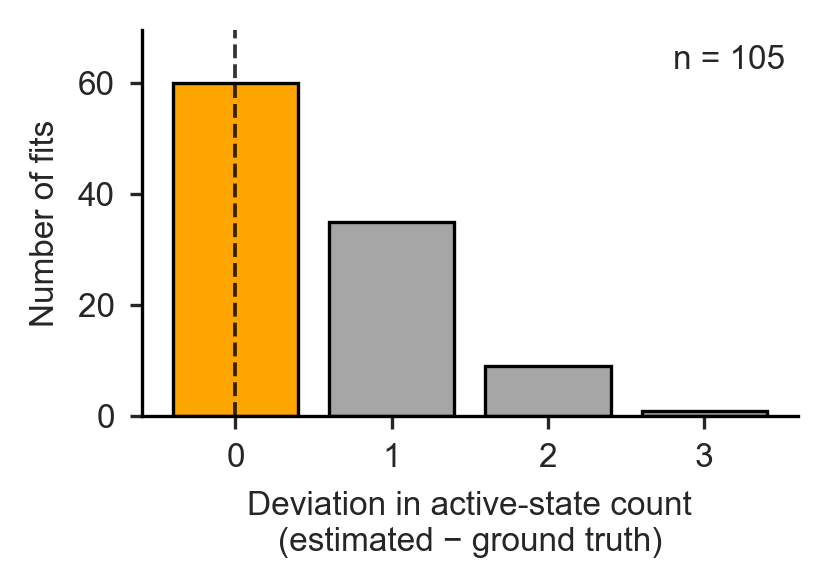

In [315]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# SHARED STYLE
# -------------------------
plt.rcParams.update({
    "axes.edgecolor": "black",
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "legend.fontsize": 8,
    "savefig.dpi": 300,
})

TRUTH_COLOR = "orange"
BAR_COLOR = "0.65"

# -------------------------
# COMPUTE BAND DATA
# -------------------------
df = df.copy()
df["window_size"] = df["num_emb"] / df["fs"]

BAND_HALF_WIDTH = 0.015   # ±15 ms; fix this if you intended ±5 ms

band_df = df.loc[
    np.abs(df["window_size"] - (TRUTH_CYCLES / df["burst_f"])) <= BAND_HALF_WIDTH
].copy()

band_df["num_states_active_diff"] = band_df["num_states_active"] - 2

x = band_df["num_states_active_diff"].dropna().astype(int)
order = np.arange(x.min(), x.max() + 1)
counts = x.value_counts().reindex(order, fill_value=0)

# -------------------------
# PLOT
# -------------------------
fig, ax = plt.subplots(figsize=(2.8, 2.0))

bar_colors = [BAR_COLOR] * len(order)
if 0 in order:
    zero_idx = np.where(order == 0)[0][0]
    bar_colors[zero_idx] = TRUTH_COLOR

ax.bar(
    order,
    counts.values,
    width=0.8,
    color=bar_colors,
    edgecolor="black",
    linewidth=0.8
)

# reference line at correct estimate
if 0 in order:
    ax.axvline(0, color="black", linestyle="--", linewidth=0.9, alpha=0.8)

ax.set_xlabel("Deviation in active-state count\n(estimated − ground truth)")
ax.set_ylabel("Number of fits")   # or: "Number of settings"

ax.set_xticks(order)
ax.set_xlim(order.min() - 0.6, order.max() + 0.6)
ax.set_ylim(0, counts.max() * 1.15 + 0.5)

# sample size
ax.text(
    0.98, 0.96, f"n = {len(x)}",
    transform=ax.transAxes,
    ha="right", va="top", fontsize=8
)

# cleaner spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [245]:
df["num_states_active_diff"] = df["num_states_active"] - 2



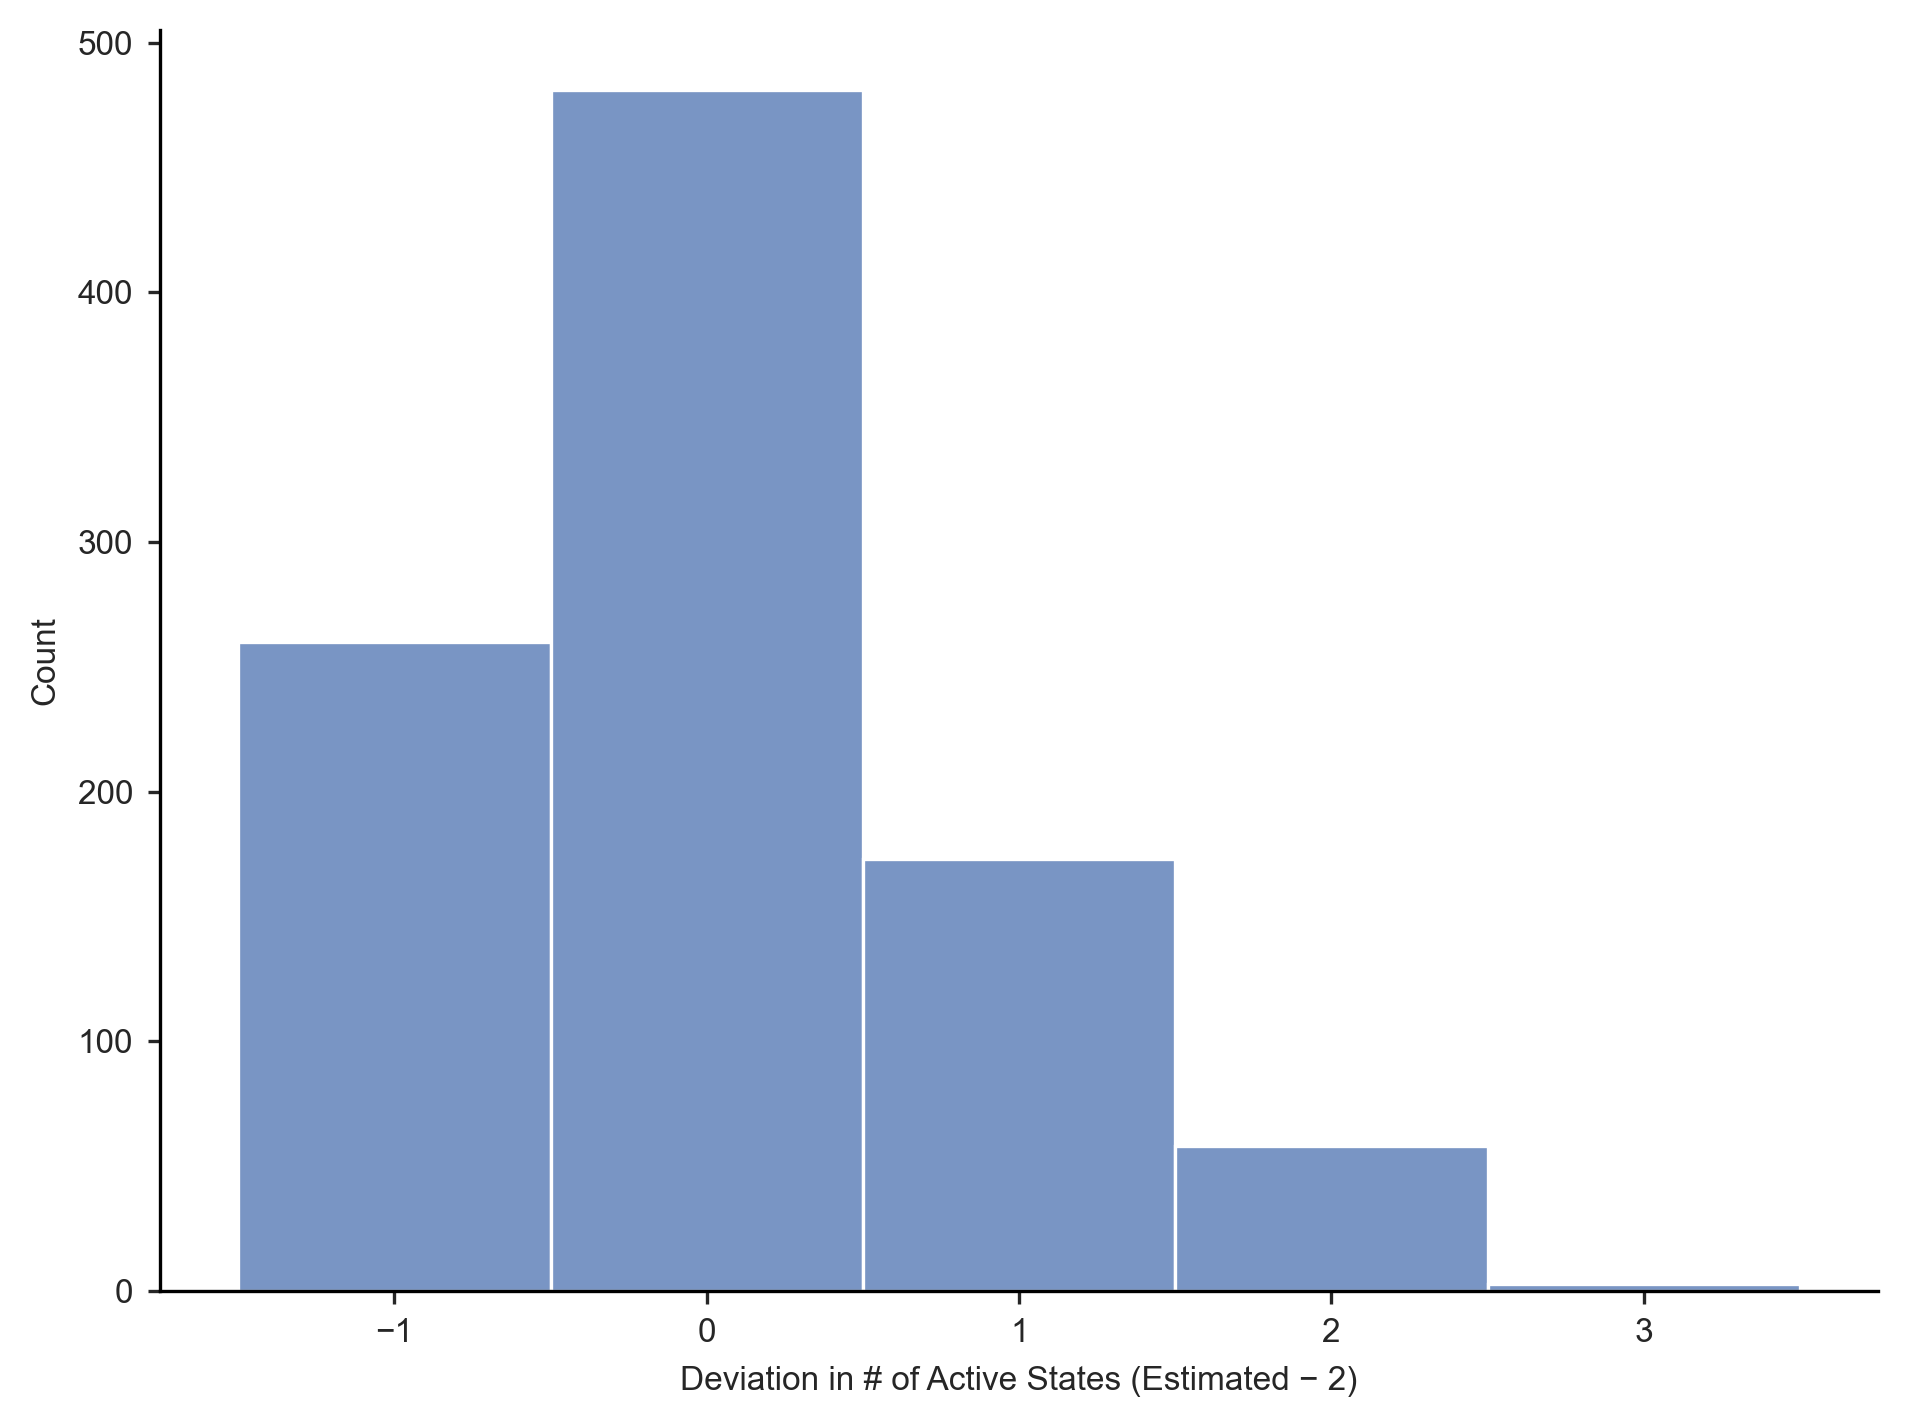

In [246]:
sns.histplot(data=df, x="num_states_active_diff", discrete=True)
plt.xlabel("Deviation in # of Active States (Estimated − 2)")
plt.ylabel("Count")
plt.show()

# 3-state scenario

In [497]:
from nds_toolbox.preprocessing.features import choose_embedding_dim, trim_data


fs = 250         # Sampling frequency in Hz.
n_seconds = 60   # Total duration in seconds.
time_vec = np.linspace(0, n_seconds, int(fs * n_seconds))


# Condition 1: frequency distances (3 states)
freqs_dist_range = [[10, 40], [15, 40], [20, 40], [25, 40], [30, 40],[35, 40]]  #30, 25, 20, 15, 10, 5Hz diff

# Condition 2: Signal-to-noise ratio (in dB)
snr_range = np.arange(-10, 11, 2)  # varying SNRs from -10 to 10 dB




In [498]:
sim_cond_data = "3states"

# Condition 2: Signal-to-noise ratio (in dB)
snr_range = np.arange(-10, 11, 2)  # varying SNRs from -10 to 10 dB


signal_dir = "../data/simulations"
sim_data = np.load(f'{signal_dir}/{sim_cond_data}_data.npz')


#load the simulated data
signal_sample = sim_data['signal_sample']
states_sample = sim_data['states_sample']
bursts_sample = sim_data['bursts_sample']

print("shape of signal_sample", signal_sample.shape)

shape of signal_sample (5, 6, 11, 45000)


In [499]:
snr_range

array([-10,  -8,  -6,  -4,  -2,   0,   2,   4,   6,   8,  10])

In [500]:

sim_cond = "3states_est_k"


performance_dir = "../data/performance"
file_path = f"{performance_dir}/results_{sim_cond}.pkl"

import pickle
with open(file_path, "rb") as f:
    res = pickle.load(f)

df_list = [pd.DataFrame(r) for r in res]
gmm_df_3states = pd.concat(df_list, axis = 0, ignore_index = True)

gmm_df_3states["burst_f"] = gmm_df_3states["burst_f"].apply(tuple)

gmm_df_3states.head()

,method,signal,true_states,burst_f,fs,snr,est_params,loss_best,model_id_best,seed_best,...,fit_t,pred_t,total_time,num_states,num_emb,est_states,order,summary_stats,mcc,loss
0,DP-GMM,"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(10, 40)",250,-10,"{'alpha': 0.34912992, 'weights': [1.0], 'means...",0.74737823,9,1096927421,...,471.850467,0.593510,472.443977,11,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[0],None,0.0,0.74737823
1,DP-GMM (Imputed),"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(10, 40)",250,-10,"{'alpha': 0.34912992, 'weights': [1.0], 'means...",0.74737823,9,1096927421,...,471.850467,0.593510,472.443977,11,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[0],None,0.0,0.74737823
2,DP-GMM,"[1.1215779014010478, 0.2241747638346373, 0.649...","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(10, 40)",250,-8,"{'alpha': 0.3865584, 'weights': [1.0], 'means'...",0.6587726,4,1137696081,...,455.921826,0.008466,455.930292,11,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[0],None,0.0,0.6587726
3,DP-GMM (Imputed),"[1.1215779014010478, 0.2241747638346373, 0.649...","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(10, 40)",250,-8,"{'alpha': 0.3865584, 'weights': [1.0], 'means'...",0.6587726,4,1137696081,...,455.921826,0.008466,455.930292,11,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[0],None,0.0,0.6587726
4,DP-GMM,"[0.45555721858453097, 0.7632128996220084, 0.37...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(10, 40)",250,-6,"{'alpha': 0.31855208, 'weights': [1.0], 'means...",0.7379326,6,3333691205,...,474.792988,0.007965,474.800954,11,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",[0],None,0.0,0.7379326


In [501]:



performance_dir = "../data/performance"
file_path = f"{performance_dir}/{sim_cond_data}_results.pkl"

import pickle
with open(file_path, "rb") as f:
    res = pickle.load(f)

df_list = [pd.DataFrame(r) for r in res]
df_3states = pd.concat(df_list, axis = 0, ignore_index = True)

df_3states["burst_f"] = df_3states["burst_f"].apply(tuple)

df_3states.head()

,method,signal,true_states,burst_f,fs,snr,est_params,loss_best,model_id_best,seed_best,...,pred_t,total_time,num_states,num_emb,est_states,order,summary_stats,mcc,loss,best_model_id
0,DP-GMM,"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(10, 40)",250,-10,"{'alpha': 1481.1799, 'weights': [0.0002643804,...",0.74750763,4.0,1.221368e+09,...,0.600014,84.720967,3,25,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 2, 0]",None,0.004152,0.74750763,NaN
1,DP-GMM (Imputed),"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(10, 40)",250,-10,"{'alpha': 1481.1799, 'weights': [0.0002643804,...",0.74750763,4.0,1.221368e+09,...,0.600014,84.720967,3,25,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 2, 0]",None,0.000000,0.74750763,NaN
2,HMM,"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(10, 40)",250,-10,"{'initial_probs': [0.31679845, 0.32383534, 0.3...",0.722242,NaN,NaN,...,0.111238,38.693617,3,25,"[2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 2]",None,0.024007,0.722242,5.0
3,HMM (Imputed),"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(10, 40)",250,-10,"{'initial_probs': [0.31679845, 0.32383534, 0.3...",0.722242,NaN,NaN,...,0.111238,38.693617,3,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 2]",None,0.021481,0.722242,5.0
4,Thresholding,"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(10, 40)",250,-10,"{'envelped_signal': [[0.17682067, 0.18038164, ...",NaN,NaN,NaN,...,0.001223,2.789531,3,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, ...","[0, 1, 2]",None,0.198367,"[[0.4, 0.4], [0.4, 0.4]]",NaN


In [459]:
gmm_df_3states["method"]

0                DP-GMM
1      DP-GMM (Imputed)
2                DP-GMM
3      DP-GMM (Imputed)
4                DP-GMM
             ...       
655    DP-GMM (Imputed)
656              DP-GMM
657    DP-GMM (Imputed)
658              DP-GMM
659    DP-GMM (Imputed)
Name: method, Length: 660, dtype: object

In [460]:
freq

array([35, 40])

In [461]:
fs

250

In [502]:
from sklearn.metrics import matthews_corrcoef
from nds_toolbox.analysis.utils import imputing_mode


for i in range(len(gmm_df_3states)):
    
    method = gmm_df_3states.iloc[i]["method"]
    freq = np.array(gmm_df_3states.iloc[i]["burst_f"])
    snr = gmm_df_3states.iloc[i]["snr"]
    print(f"snr = {snr}; freqs = {freq}")
    
    

    
    true_states = gmm_df_3states.iloc[i]["true_states"]
    old_mcc = gmm_df_3states.iloc[i]["mcc"]
    est_params = gmm_df_3states.iloc[i]["est_params"]
    alpha = est_params["alpha"]
    weights = est_params["untrunc_weights"]
    means = est_params["untrunc_means"]
    covs = est_params["untrunc_covs"]
    signal = gmm_df_3states.iloc[i]["signal"]
    num_emb = gmm_df_3states.iloc[i]["num_emb"]
    tde_data = compute_tde(signal, num_emb)

    trunc_means, trunc_covs, trunc_weights, trunc_info = truncate(means, covs, weights, verbose=True, return_info= True, edge_states_cv = 0.2)


    num_active_states = int(len(trunc_weights))

    #the estimated states with truncated params
    est_states = get_states(tde_data, trunc_means, trunc_covs, trunc_weights)
    
    if method == "DP-GMM (Imputed)":
        
    #knn imputation
        min_samples = np.round((2/np.max(freq))*fs).astype(int)

        est_states = imputing_mode(est_states, min_samples = min_samples)

    est_states_onehot = np.eye(num_active_states)[est_states]

    trimmed_states = trim_data(true_states, num_emb, verbose = False)


    true_states_onehot = np.eye(trimmed_states.max()+1, dtype=np.float32)[trimmed_states]



    order, reordered_est_states_onehot = match_states(
        true_states_onehot, est_states_onehot, verbose=False
    )
    est_states = np.argmax(reordered_est_states_onehot, axis=1)
    


    mcc = matthews_corrcoef(trimmed_states, est_states)
    
    est_params = {
    "alpha": alpha,
    "weights": trunc_weights,
    "means": trunc_means,
    "covs": trunc_covs,
    "untrunc_means": means,
    "untrunc_covs": covs,
    "untrunc_weights": weights,
    "num_states_active":num_active_states,
    "trunc_info": trunc_info,}

    

    gmm_df_3states.at[i, "est_params"] = est_params
    gmm_df_3states.at[i, "mcc"] = float(mcc)
    gmm_df_3states.at[i, "est_states"] = np.asarray(est_states)
    gmm_df_3states.at[i, "num_active_states"] = num_active_states
    #print("mcc", old_mcc)
    #print("new mcc", mcc)
    #print()
    #print()

snr = -10; freqs = [10 40]
12 data points were lost from both ends.
data shape: (44976, 25)
[truncate] mass_threshold=0.990 | kept 1/11 | mass kept=0.9995 | mass dropped=0.0005 | removed_edge=0 (cv>0.2)
snr = -10; freqs = [10 40]
12 data points were lost from both ends.
data shape: (44976, 25)
[truncate] mass_threshold=0.990 | kept 1/11 | mass kept=0.9995 | mass dropped=0.0005 | removed_edge=0 (cv>0.2)
snr = -8; freqs = [10 40]
12 data points were lost from both ends.
data shape: (44976, 25)
[truncate] mass_threshold=0.990 | kept 1/11 | mass kept=0.9997 | mass dropped=0.0003 | removed_edge=0 (cv>0.2)
snr = -8; freqs = [10 40]
12 data points were lost from both ends.
data shape: (44976, 25)
[truncate] mass_threshold=0.990 | kept 1/11 | mass kept=0.9997 | mass dropped=0.0003 | removed_edge=0 (cv>0.2)
snr = -6; freqs = [10 40]
12 data points were lost from both ends.
data shape: (44976, 25)
[truncate] mass_threshold=0.990 | kept 1/11 | mass kept=0.9916 | mass dropped=0.0084 | removed_edge

In [503]:
methods = ["DP-GMM (Imputed)", "DP-GMM"]

# 1) drop old DP-GMM rows
df_keep = df_3states.loc[~df_3states["method"].isin(methods)].copy()

# 2) append new DP-GMM rows (your source of truth)
df_3states = pd.concat([df_keep, gmm_df_3states.copy()], ignore_index=True)


In [504]:
df_3states

,method,signal,true_states,burst_f,fs,snr,est_params,loss_best,model_id_best,seed_best,...,total_time,num_states,num_emb,est_states,order,summary_stats,mcc,loss,best_model_id,num_active_states
0,HMM,"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(10, 40)",250,-10,"{'initial_probs': [0.31679845, 0.32383534, 0.3...",0.722242,NaN,NaN,...,38.693617,3,25,"[2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 2]",None,0.024007,0.722242,5.0,NaN
1,HMM (Imputed),"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(10, 40)",250,-10,"{'initial_probs': [0.31679845, 0.32383534, 0.3...",0.722242,NaN,NaN,...,38.693617,3,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 2]",None,0.021481,0.722242,5.0,NaN
2,Thresholding,"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(10, 40)",250,-10,"{'envelped_signal': [[0.17682067, 0.18038164, ...",NaN,NaN,NaN,...,2.789531,3,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, ...","[0, 1, 2]",None,0.198367,"[[0.4, 0.4], [0.4, 0.4]]",NaN,NaN
3,Thresholding (Imputed),"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(10, 40)",250,-10,"{'envelped_signal': [[0.17682067, 0.18038164, ...",NaN,NaN,NaN,...,2.789531,3,25,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[0, 1, 2]",None,0.202390,"[[0.4, 0.4], [0.4, 0.4]]",NaN,NaN
4,HMM,"[1.1215779014010478, 0.2241747638346373, 0.649...","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(10, 40)",250,-8,"{'initial_probs': [0.34434733, 0.3593983, 0.29...",0.63744,NaN,NaN,...,39.445304,3,25,"[1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, ...","[0, 1, 2]",None,0.067480,0.63744,6.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1975,DP-GMM (Imputed),"[-0.585752840657076, -0.5225019175848771, 0.72...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","(35, 40)",250,6,"{'alpha': 1.9817915, 'weights': [0.6373161, 0....",0.8030345,6.0,4.240274e+09,...,394.727823,11,17,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 3, 2, 1]",None,0.740456,0.8030345,NaN,4.0
1976,DP-GMM,"[-0.5602830309228354, -0.4702556864406927, -0....","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(35, 40)",250,8,"{'alpha': 1.5930029, 'weights': [0.71591496, 0...",0.7600445,8.0,5.824903e+08,...,371.495489,11,17,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 2, 3, 1, 4, 5, 6, 7, 8]",None,0.787633,0.7600445,NaN,4.0
1977,DP-GMM (Imputed),"[-0.5602830309228354, -0.4702556864406927, -0....","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(35, 40)",250,8,"{'alpha': 1.5930029, 'weights': [0.71591496, 0...",0.7600445,8.0,5.824903e+08,...,371.495489,11,17,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 2, 3, 1]",None,0.888400,0.7600445,NaN,4.0
1978,DP-GMM,"[1.9687612318889252, 1.5823072164536132, 2.372...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","(35, 40)",250,10,"{'alpha': 1.9158964, 'weights': [0.52301335, 0...",0.62610006,0.0,3.531131e+09,...,395.763816,11,17,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 2, 3, 1, 4, 5, 6, 7, 8, 9]",None,0.425928,0.62610006,NaN,4.0


In [505]:
res = df_3states.query("burst_f == @plot_f and snr == @snr_db")
dpgmm_res = res.query("method == 'DP-GMM (Imputed)'").iloc[sample_id]


In [506]:
num_states = 3
snr_db = 0
snr_id = np.where(snr_range == snr_db)[0][0]
plot_f = (20, 40)
freq_id = np.where((np.array(freqs_dist_range) == np.array(plot_f)).all(axis=1))[0][0]

sample_id = 0

res = df_3states.query("burst_f == @plot_f and snr == @snr_db")
dpgmm_res = res.query("method == 'DP-GMM (Imputed)'").iloc[sample_id]
hmm_res = res.query("method == 'HMM (Imputed)'").iloc[sample_id]
thresh_res = res.query("method == 'Thresholding (Imputed)'").iloc[sample_id]


num_emb = int(res.num_emb.values[0])


dpgmm_states =dpgmm_res.est_states
dpgmm_mcc = dpgmm_res.mcc
dpgmm_states_onehot = np.eye(num_states)[dpgmm_states]

hmm_states = hmm_res.est_states
hmm_mcc = hmm_res.mcc
hmm_states_onehot = np.eye(num_states)[hmm_states]

thresh_states = thresh_res.est_states
thresh_mcc = thresh_res.mcc
thresh_states_onehot = np.eye(num_states)[thresh_states]





trimmed_signal = trim_data(signal_sample[sample_id, freq_id, snr_id], num_emb)
trimmed_states = trim_data(states_sample[sample_id, freq_id, snr_id], num_emb).astype(int)
trimmed_bursts = trim_data(bursts_sample[sample_id, freq_id, snr_id], num_emb)


trimmed_time_vec = np.linspace(0, len(trimmed_states)/fs, len(trimmed_states))
states_onehot = np.eye(num_states)[trimmed_states]

Lost 10 data points were lost from both ends.
data shape: (44980,)
Lost 10 data points were lost from both ends.
data shape: (44980,)
Lost 10 data points were lost from both ends.
data shape: (44980,)


In [507]:
df_3states.query("burst_f == @plot_f")

,method,signal,true_states,burst_f,fs,snr,est_params,loss_best,model_id_best,seed_best,...,total_time,num_states,num_emb,est_states,order,summary_stats,mcc,loss,best_model_id,num_active_states
88,HMM,"[0.324849481937262, 0.5456342563612496, -0.218...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 40)",250,-10,"{'initial_probs': [0.43100742, 0.28147048, 0.2...",0.84669,NaN,NaN,...,31.124852,3,21,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 0, 2]",None,0.056091,0.84669,3.0,NaN
89,HMM (Imputed),"[0.324849481937262, 0.5456342563612496, -0.218...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 40)",250,-10,"{'initial_probs': [0.43100742, 0.28147048, 0.2...",0.84669,NaN,NaN,...,31.124852,3,21,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 0, 2]",None,0.060624,0.84669,3.0,NaN
90,Thresholding,"[0.324849481937262, 0.5456342563612496, -0.218...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 40)",250,-10,"{'envelped_signal': [[0.08172642, 0.08020275, ...",NaN,NaN,NaN,...,2.113748,3,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2]",None,0.179011,"[[0.4, 0.30000000000000004], [0.4, 0.4]]",NaN,NaN
91,Thresholding (Imputed),"[0.324849481937262, 0.5456342563612496, -0.218...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 40)",250,-10,"{'envelped_signal': [[0.08172642, 0.08020275, ...",NaN,NaN,NaN,...,2.113748,3,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2]",None,0.178622,"[[0.4, 0.30000000000000004], [0.4, 0.4]]",NaN,NaN
92,HMM,"[-1.5008340711002028, -0.4961152241150958, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(20, 40)",250,-8,"{'initial_probs': [0.534522, 0.27629435, 0.189...",0.692557,NaN,NaN,...,32.410867,3,21,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, ...","[1, 2, 0]",None,0.117607,0.692557,3.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1909,DP-GMM (Imputed),"[1.3634175400290127, 0.8228606460439072, 1.475...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","(20, 40)",250,6,"{'alpha': 1.7601112, 'weights': [0.8551336, 0....",0.7836977,5.0,4.106136e+09,...,432.171839,11,21,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 1, 2, 3]",None,0.956844,0.7836977,NaN,3.0
1910,DP-GMM,"[0.29867663374114295, 0.46863098951003174, 1.1...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","(20, 40)",250,8,"{'alpha': 0.777952, 'weights': [0.8671084, 0.0...",0.70233077,2.0,1.624846e+09,...,404.996364,11,21,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 1, 3, 2, 4, 5, 6, 7, 8]",None,0.797219,0.70233077,NaN,4.0
1911,DP-GMM (Imputed),"[0.29867663374114295, 0.46863098951003174, 1.1...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","(20, 40)",250,8,"{'alpha': 0.777952, 'weights': [0.8671084, 0.0...",0.70233077,2.0,1.624846e+09,...,404.996364,11,21,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 1, 3, 2]",None,0.824335,0.70233077,NaN,4.0
1912,DP-GMM,"[0.6722647544305983, 0.6033643623014291, 0.923...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 40)",250,10,"{'alpha': 0.72906035, 'weights': [0.5670564, 0...",0.6389441,8.0,3.618344e+09,...,428.586736,11,21,"[0, 3, 0, 0, 0, 3, 3, 0, 3, 0, 0, 0, 0, 3, 0, ...","[0, 2, 4, 1, 3, 5, 6, 7]",None,0.559206,0.6389441,NaN,5.0


In [468]:
df_3states.head()

,method,signal,true_states,burst_f,fs,snr,est_params,loss_best,model_id_best,seed_best,...,total_time,num_states,num_emb,est_states,order,summary_stats,mcc,loss,best_model_id,num_active_states
0,HMM,"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(10, 40)",250,-10,"{'initial_probs': [0.31679845, 0.32383534, 0.3...",0.722242,NaN,NaN,...,38.693617,3,25,"[2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 2]",None,0.024007,0.722242,5.0,NaN
1,HMM (Imputed),"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(10, 40)",250,-10,"{'initial_probs': [0.31679845, 0.32383534, 0.3...",0.722242,NaN,NaN,...,38.693617,3,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 2]",None,0.021481,0.722242,5.0,NaN
2,Thresholding,"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(10, 40)",250,-10,"{'envelped_signal': [[0.17682067, 0.18038164, ...",NaN,NaN,NaN,...,2.789531,3,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, ...","[0, 1, 2]",None,0.198367,"[[0.4, 0.4], [0.4, 0.4]]",NaN,NaN
3,Thresholding (Imputed),"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(10, 40)",250,-10,"{'envelped_signal': [[0.17682067, 0.18038164, ...",NaN,NaN,NaN,...,2.789531,3,25,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[0, 1, 2]",None,0.202390,"[[0.4, 0.4], [0.4, 0.4]]",NaN,NaN
4,HMM,"[1.1215779014010478, 0.2241747638346373, 0.649...","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(10, 40)",250,-8,"{'initial_probs': [0.34434733, 0.3593983, 0.29...",0.63744,NaN,NaN,...,39.445304,3,25,"[1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, ...","[0, 1, 2]",None,0.067480,0.63744,6.0,NaN


In [508]:

df_avg = (
    df_3states.query("burst_f == @plot_f")
    .groupby(["method", "snr"], as_index = False)
    .agg(
        mcc_mean = ("mcc", "mean"),
        mcc_median = ("mcc", "median"),
        mcc_sem = ("mcc", lambda x: np.std(x, ddof = 1) / np.sqrt(len(x))),
        mcc_std = ("mcc", "std"),))




In [509]:

df_avg.head()


,method,snr,mcc_mean,mcc_median,mcc_sem,mcc_std
0,DP-GMM,-10,0.016635,0.006821,0.010336,0.023112
1,DP-GMM,-8,0.025744,0.005842,0.015318,0.034252
2,DP-GMM,-6,0.111636,0.099939,0.019931,0.044568
3,DP-GMM,-4,0.507209,0.508073,0.010688,0.023900
4,DP-GMM,-2,0.664358,0.666410,0.004385,0.009806


In [510]:
df_3states.method.values


array(['HMM', 'HMM (Imputed)', 'Thresholding', ..., 'DP-GMM (Imputed)',
       'DP-GMM', 'DP-GMM (Imputed)'], shape=(1980,), dtype=object)

In [511]:
def relabel_freqs(burst_f):
    f0, f1 = burst_f 
    label = f"{str(f0)}&{str(f1)}"
    return label


df_3states["burst_f"] = df_3states["burst_f"].apply(relabel_freqs)


In [512]:
df_3states["snr"].value_counts()

snr
-10    180
-8     180
-6     180
-4     180
-2     180
 0     180
 2     180
 4     180
 6     180
 8     180
 10    180
Name: count, dtype: int64

/var/folders/5z/yggynsqj6632pbql_bb3kqm40000gn/T/ipykernel_90334/1008184529.py:117: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


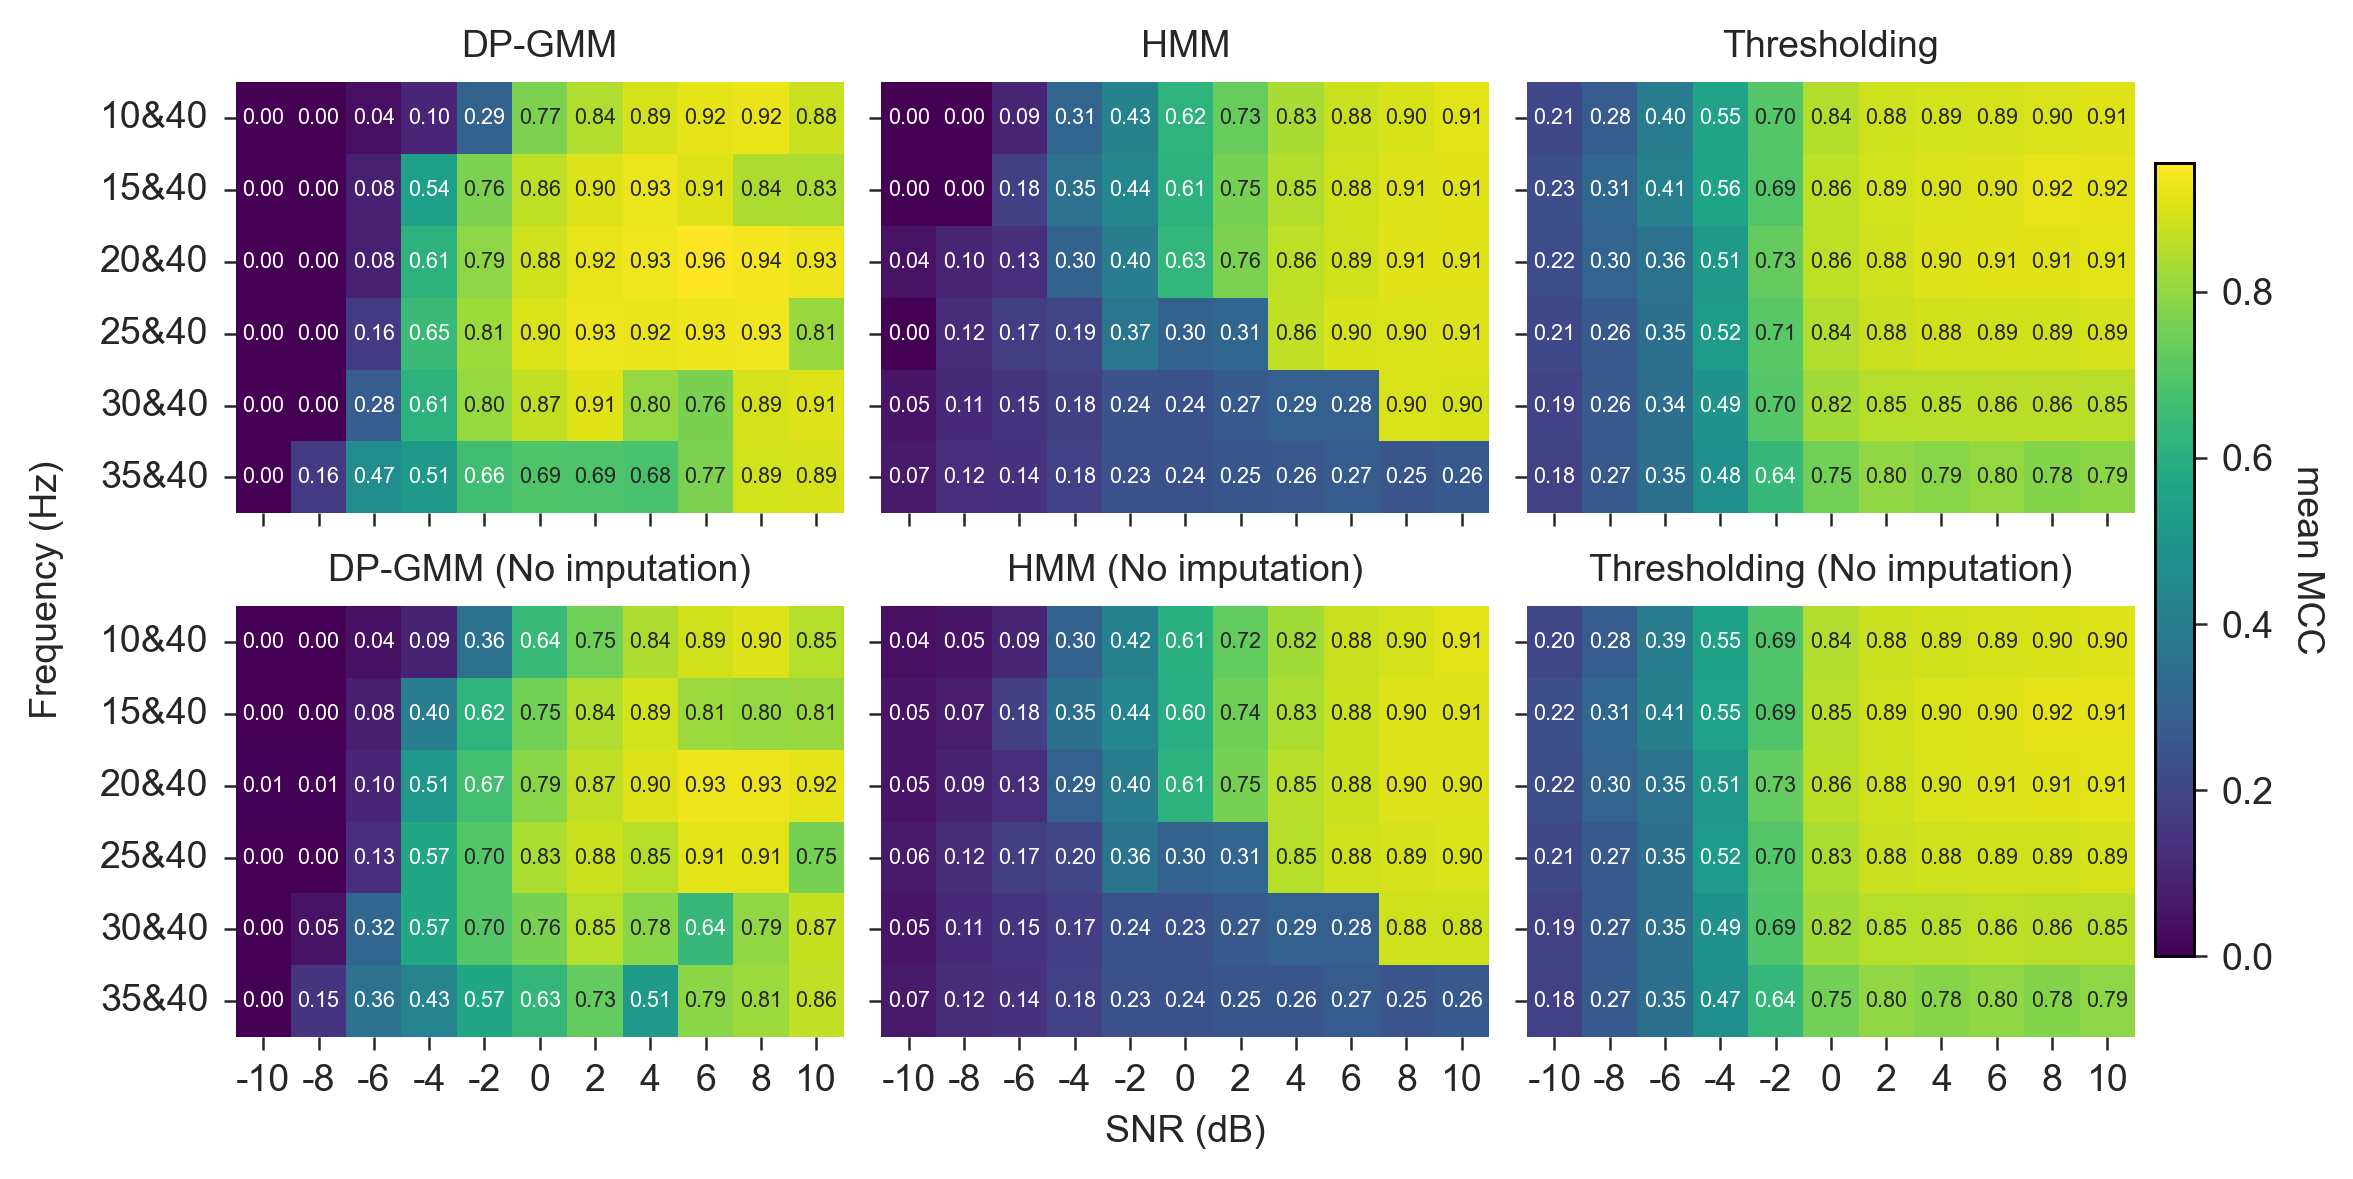

In [524]:
import numpy as np
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import MaxNLocator



method_names = set(df_3states.method.values)




aggfunc = "median"

dpgmm_heat = (df_3states.query("method == 'DP-GMM'")
        .pivot_table(index="burst_f", columns="snr", values="mcc", aggfunc=aggfunc)
        .sort_index(axis=0)
        .sort_index(axis=1))

hmm_heat = (df_3states.query("method == 'HMM'")
        .pivot_table(index="burst_f", columns="snr", values="mcc", aggfunc=aggfunc)
        .sort_index(axis=0)   # freq ascending
        .sort_index(axis=1))  # snr ascending



thresh_heat = (df_3states.query("method == 'Thresholding'")
        .pivot_table(index="burst_f", columns="snr", values="mcc", aggfunc=aggfunc)
        .sort_index(axis=0) 
        .sort_index(axis=1))




dpgmm_imputed_heat = (df_3states.query("method == 'DP-GMM (Imputed)'")
        .pivot_table(index="burst_f", columns="snr", values="mcc", aggfunc = aggfunc)
        .sort_index(axis=0) 
        .sort_index(axis=1))


hmm_imputed_heat = (df_3states.query("method == 'HMM (Imputed)'")
        .pivot_table(index="burst_f", columns="snr", values="mcc", aggfunc=aggfunc)
        .sort_index(axis=0)   # freq ascending
        .sort_index(axis=1))  # snr ascending


thresh_imputed_heat = (df_3states.query("method == 'Thresholding (Imputed)'")
        .pivot_table(index="burst_f", columns="snr", values="mcc", aggfunc=aggfunc)
        .sort_index(axis=0) 
        .sort_index(axis=1))




mats = [
    dpgmm_heat, hmm_heat, thresh_heat,
    dpgmm_imputed_heat, hmm_imputed_heat, thresh_imputed_heat
]

vmin = np.nanmin([m.to_numpy() for m in mats])
vmax = np.nanmax([m.to_numpy() for m in mats])




common = dict(
    annot=True, fmt=".2f", annot_kws={"size": 5.2},
    cmap="viridis", vmin=vmin, vmax=vmax,
    cbar=False
)


fig, ax = plt.subplots(2, 3, figsize=(FIG_WIDTH, 4), sharex=True, sharey=True)

sns.heatmap(dpgmm_imputed_heat, **common, ax=ax[0,0])
ax[0,0].set_title("DP-GMM")

sns.heatmap(hmm_imputed_heat, **common, ax=ax[0,1])
ax[0,1].set_title("HMM")

sns.heatmap(thresh_imputed_heat, **common, ax=ax[0,2])
ax[0,2].set_title("Thresholding")

sns.heatmap(dpgmm_heat, **common, ax=ax[1,0])
ax[1,0].xaxis.set_major_locator(MaxNLocator(6))
ax[1,0].set_title("DP-GMM (No imputation)")

sns.heatmap(hmm_heat, **common, ax=ax[1,1])
ax[1,1].set_title("HMM (No imputation)")

sns.heatmap(thresh_heat, **common, ax=ax[1,2])
ax[1,2].set_title("Thresholding (No imputation)")






sm = ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap="viridis")
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax.ravel().tolist(), fraction=0.02, pad=-0.05)
cbar.set_label("mean MCC",  rotation=270, labelpad=12)




for a in ax.flat:
    a.set_xlabel("")
    a.set_ylabel("")
    

fig.supylabel("Frequency (Hz)", fontsize = MY_FONT_SIZE)

ax[1,1].set_xlabel("SNR (dB)", fontsize = MY_FONT_SIZE)


plt.tight_layout()

fig.savefig(
    f"../figures/raw_figure/{sim_cond}heatmaps.jpg",
    bbox_inches="tight"
)





In [475]:


gmm_df_3states["num_states_active"] = [gmm_df_3states.iloc[i]["est_params"]["num_states_active"] for i in range(len(gmm_df_3states))]



In [476]:
mask = gmm_df_3states["method"].eq("DP-GMM (Imputed)")

gmm_df_3states[mask]["num_states_active"] = [len(np.unique(gmm_df_3states[mask].iloc[i]["est_states"])) for i in range(len(gmm_df_3states[mask]))]

/var/folders/5z/yggynsqj6632pbql_bb3kqm40000gn/T/ipykernel_90334/3519516940.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gmm_df_3states[mask]["num_states_active"] = [len(np.unique(gmm_df_3states[mask].iloc[i]["est_states"])) for i in range(len(gmm_df_3states[mask]))]


In [477]:
mask = gmm_df_3states["snr"].eq(6)
mask2 = gmm_df_3states["num_emb"].eq(21)

gmm_df_3states[mask&mask2]

,method,signal,true_states,burst_f,fs,snr,est_params,loss_best,model_id_best,seed_best,...,total_time,num_states,num_emb,est_states,order,summary_stats,mcc,loss,num_active_states,num_states_active
60,DP-GMM,"[-0.6691059679504556, -1.0328219928776812, -0....","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","(20, 40)",250,6,"{'alpha': 1.3905241, 'weights': [0.85749936, 0...",0.6971371,4,1984830934,...,417.356419,11,21,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8]",None,0.935826,0.6971371,3.0,3
61,DP-GMM (Imputed),"[-0.6691059679504556, -1.0328219928776812, -0....","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","(20, 40)",250,6,"{'alpha': 1.3905241, 'weights': [0.85749936, 0...",0.6971371,4,1984830934,...,417.356419,11,21,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 1, 2, 3, 4]",None,0.955327,0.6971371,3.0,3
82,DP-GMM,"[1.9539421894300137, 1.9357757252233807, 2.214...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(25, 40)",250,6,"{'alpha': 2.3176122, 'weights': [0.8785267, 0....",0.67153263,3,1290277151,...,410.220665,11,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]",None,0.924092,0.67153263,3.0,3
83,DP-GMM (Imputed),"[1.9539421894300137, 1.9357757252233807, 2.214...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(25, 40)",250,6,"{'alpha': 2.3176122, 'weights': [0.8785267, 0....",0.67153263,3,1290277151,...,410.220665,11,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2, 3]",None,0.940783,0.67153263,3.0,3
192,DP-GMM,"[-0.48085976855387796, -0.9785573214415595, 0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(20, 40)",250,6,"{'alpha': 1.6681455, 'weights': [0.84275144, 0...",0.7286228,1,518726512,...,427.588606,11,21,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]",None,0.926740,0.7286228,4.0,4
193,DP-GMM (Imputed),"[-0.48085976855387796, -0.9785573214415595, 0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(20, 40)",250,6,"{'alpha': 1.6681455, 'weights': [0.84275144, 0...",0.7286228,1,518726512,...,427.588606,11,21,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[0, 1, 2]",None,0.955105,0.7286228,4.0,4
214,DP-GMM,"[-1.6640094528793576, -1.2929135208758926, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(25, 40)",250,6,"{'alpha': 1.4618232, 'weights': [0.88708675, 0...",0.78617185,2,3775597811,...,408.402361,11,21,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]",None,0.923661,0.78617185,3.0,3
215,DP-GMM (Imputed),"[-1.6640094528793576, -1.2929135208758926, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","(25, 40)",250,6,"{'alpha': 1.4618232, 'weights': [0.88708675, 0...",0.78617185,2,3775597811,...,408.402361,11,21,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[0, 1, 2, 3]",None,0.937326,0.78617185,3.0,3
324,DP-GMM,"[0.1278159875319836, 1.097646277564559, 0.8719...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 40)",250,6,"{'alpha': 1.5993137, 'weights': [0.8060328, 0....",0.77957463,0,4075163257,...,426.339041,11,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2, 3, 4, 5, 6]",None,0.931361,0.77957463,3.0,3
325,DP-GMM (Imputed),"[0.1278159875319836, 1.097646277564559, 0.8719...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 40)",250,6,"{'alpha': 1.5993137, 'weights': [0.8060328, 0....",0.77957463,0,4075163257,...,426.339041,11,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2, 3, 4]",None,0.947835,0.77957463,3.0,3


In [478]:
gmm_df_3states.iloc[457][

SyntaxError: incomplete input (537815817.py, line 1)

In [479]:
active_states_df = gmm_df_3states.groupby(["method", "snr"], as_index = False).agg(
    mean_active_states=("num_states_active", "mean"),
)


mask = gmm_df_3states["method"].eq("DP-GMM")


active_states_df = gmm_df_3states[mask].groupby(["snr"], as_index = False).agg(
    mean_active_states=("num_states_active", "mean"),
)

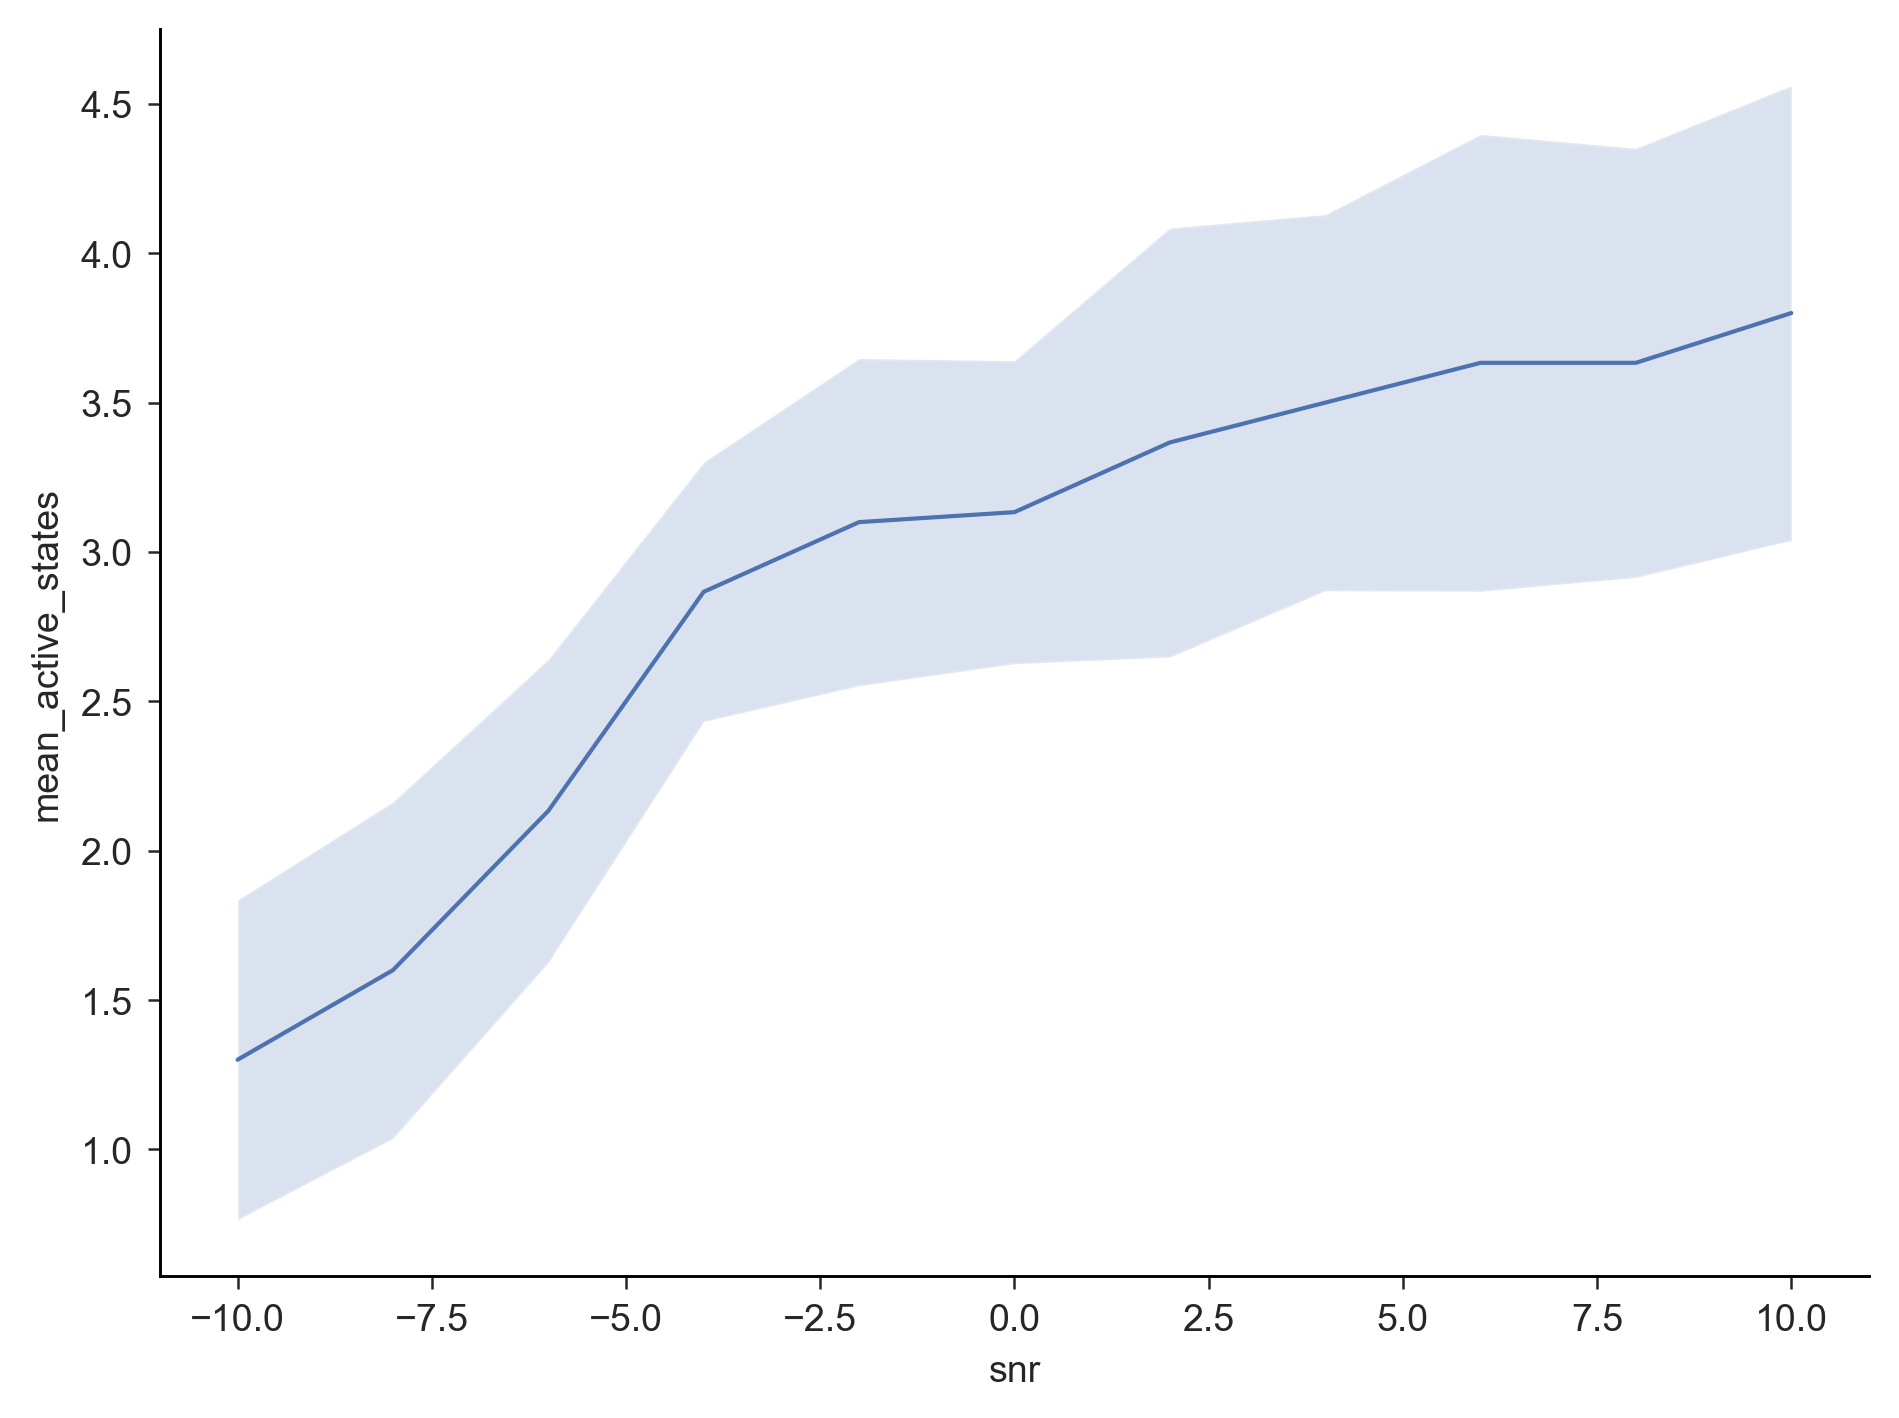

In [480]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

active_states_df = (
    gmm_df_3states.loc[mask]
    .groupby("snr", as_index=False)
    .agg(
        mean_active_states=("num_states_active", "mean"),
        std_active_states =("num_states_active", "std"),
    )
    .sort_values("snr")
)

ax = sns.lineplot(data=active_states_df, x="snr", y="mean_active_states")

x = active_states_df["snr"].to_numpy()
m = active_states_df["mean_active_states"].to_numpy()
s = active_states_df["std_active_states"].fillna(0).to_numpy()  # std=NaN if n=1

ax.fill_between(x, m - s, m + s, alpha=0.2)

plt.xlabel("snr")
plt.ylabel("mean_active_states")
plt.show()


/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 43.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 36.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 50.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 40.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/envs/pymc_env/lib/python3.12/

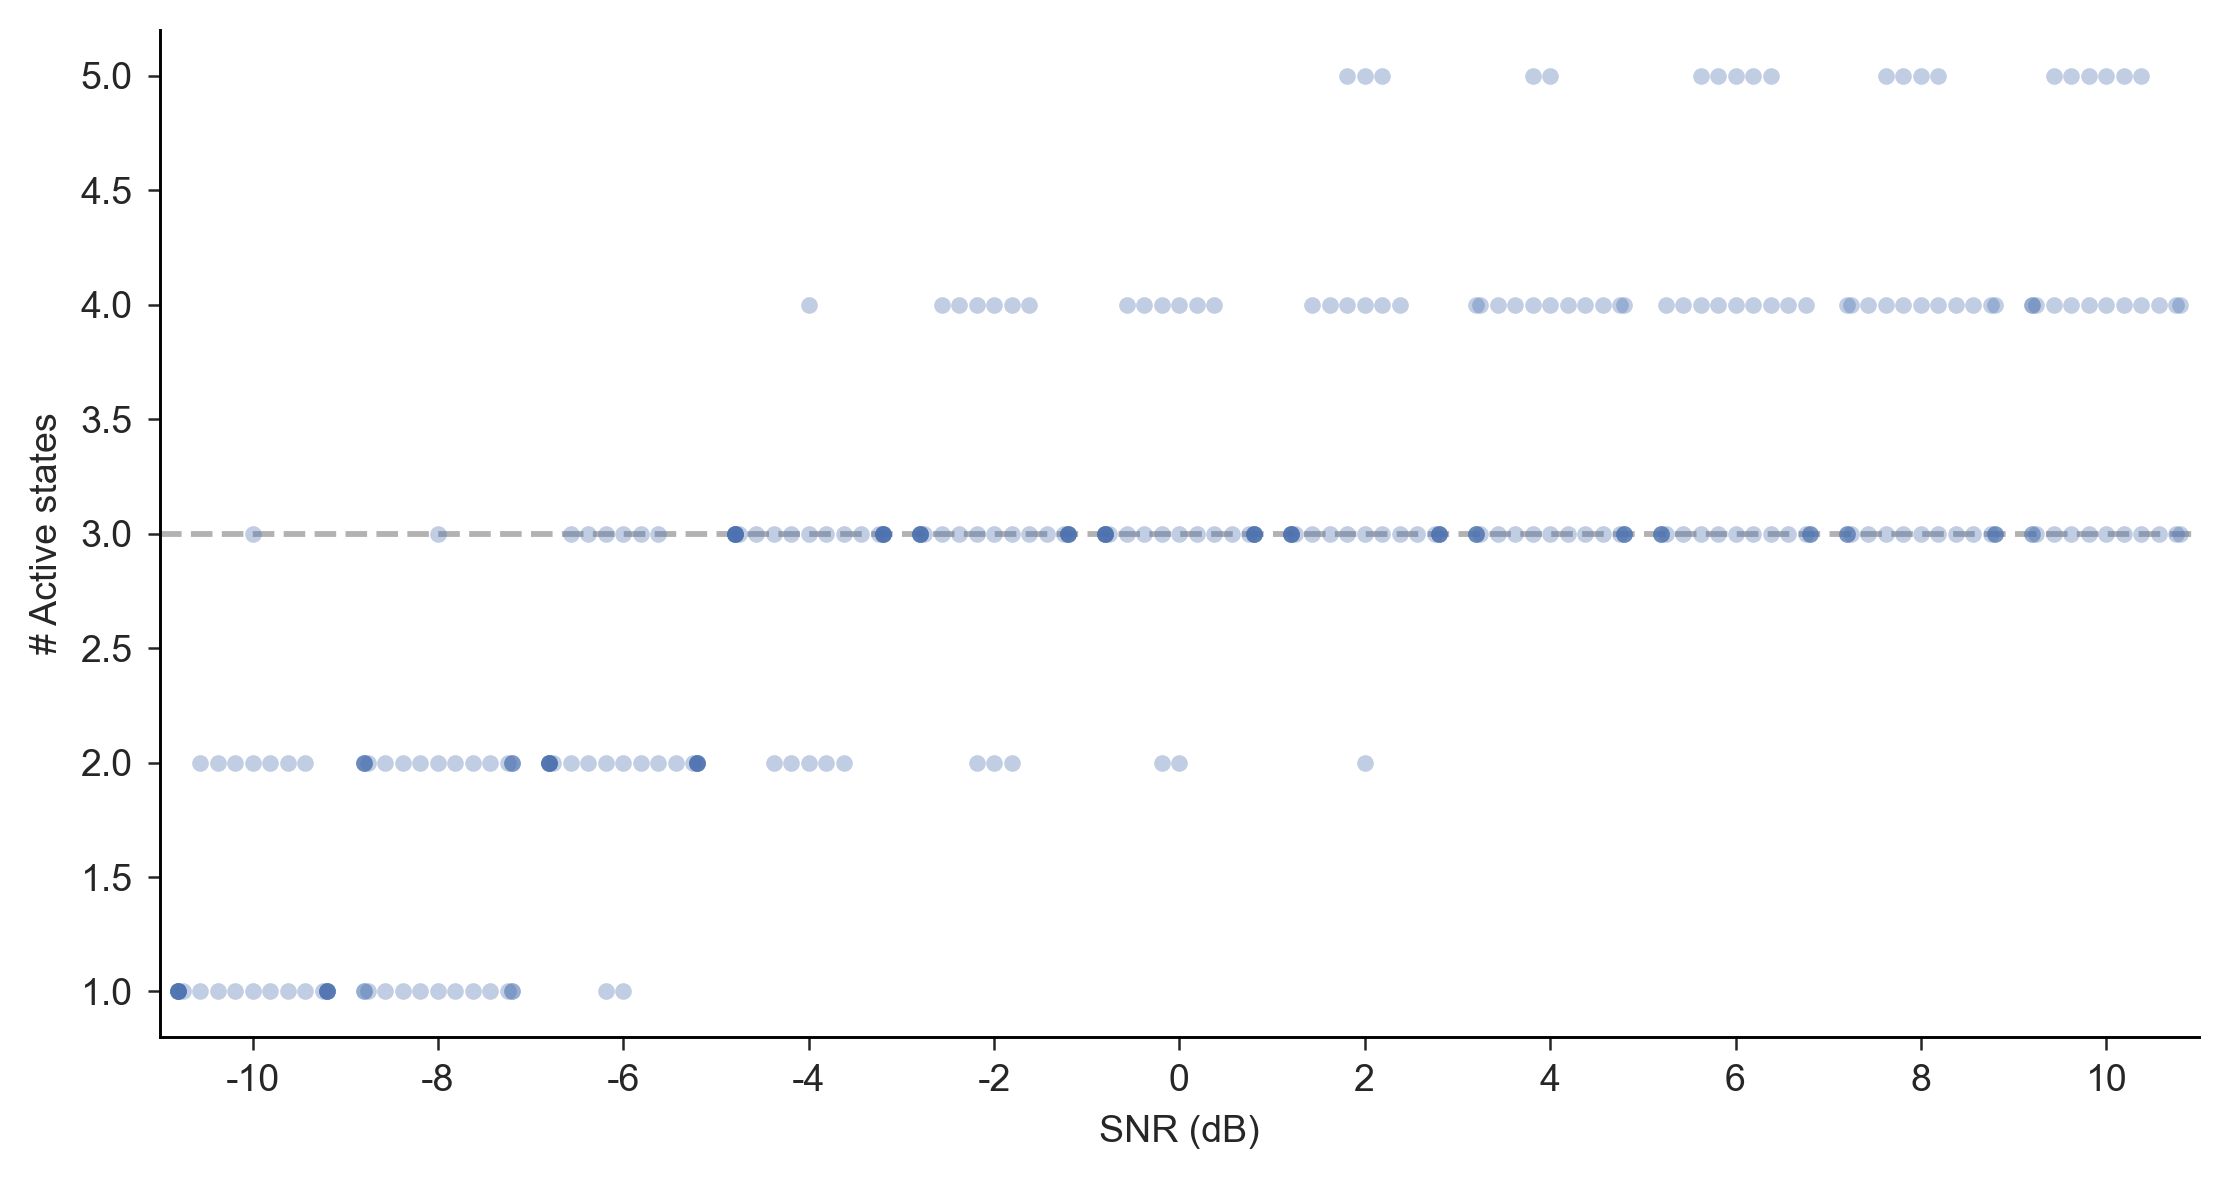

In [481]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(FIG_WIDTH,4))
ax = sns.swarmplot(
    data=gmm_df_3states.loc[mask],
    x="snr", y="num_states_active",
    size=4.0, alpha=0.35
)

ax.axhline(y=3, linestyle="--", linewidth=1.4, color = "black", alpha = 0.3)  # horizontal reference line

sns.despine(ax=ax)
ax.set_xlabel("SNR (dB)", fontsize = MY_FONT_SIZE)
ax.set_ylabel("# Active states", fontsize = MY_FONT_SIZE)
plt.tight_layout()
plt.show()


In [482]:
df_3states.head()

,method,signal,true_states,burst_f,fs,snr,est_params,loss_best,model_id_best,seed_best,...,total_time,num_states,num_emb,est_states,order,summary_stats,mcc,loss,best_model_id,num_active_states
0,HMM,"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...",10&40,250,-10,"{'initial_probs': [0.31679845, 0.32383534, 0.3...",0.722242,NaN,NaN,...,38.693617,3,25,"[2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 2]",None,0.024007,0.722242,5.0,NaN
1,HMM (Imputed),"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...",10&40,250,-10,"{'initial_probs': [0.31679845, 0.32383534, 0.3...",0.722242,NaN,NaN,...,38.693617,3,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 2]",None,0.021481,0.722242,5.0,NaN
2,Thresholding,"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...",10&40,250,-10,"{'envelped_signal': [[0.17682067, 0.18038164, ...",NaN,NaN,NaN,...,2.789531,3,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, ...","[0, 1, 2]",None,0.198367,"[[0.4, 0.4], [0.4, 0.4]]",NaN,NaN
3,Thresholding (Imputed),"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...",10&40,250,-10,"{'envelped_signal': [[0.17682067, 0.18038164, ...",NaN,NaN,NaN,...,2.789531,3,25,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[0, 1, 2]",None,0.202390,"[[0.4, 0.4], [0.4, 0.4]]",NaN,NaN
4,HMM,"[1.1215779014010478, 0.2241747638346373, 0.649...","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...",10&40,250,-8,"{'initial_probs': [0.34434733, 0.3593983, 0.29...",0.63744,NaN,NaN,...,39.445304,3,25,"[1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, ...","[0, 1, 2]",None,0.067480,0.63744,6.0,NaN


In [483]:
plot_f = "20&40"

In [484]:

df_avg = (
    df_3states.query("burst_f == @plot_f")
    .groupby(["method", "snr"], as_index = False)
    .agg(
        mcc_mean = ("mcc", "mean"),
        mcc_sem = ("mcc", lambda x: np.std(x, ddof = 1) / np.sqrt(len(x))),
        mcc_std = ("mcc", "std"),))




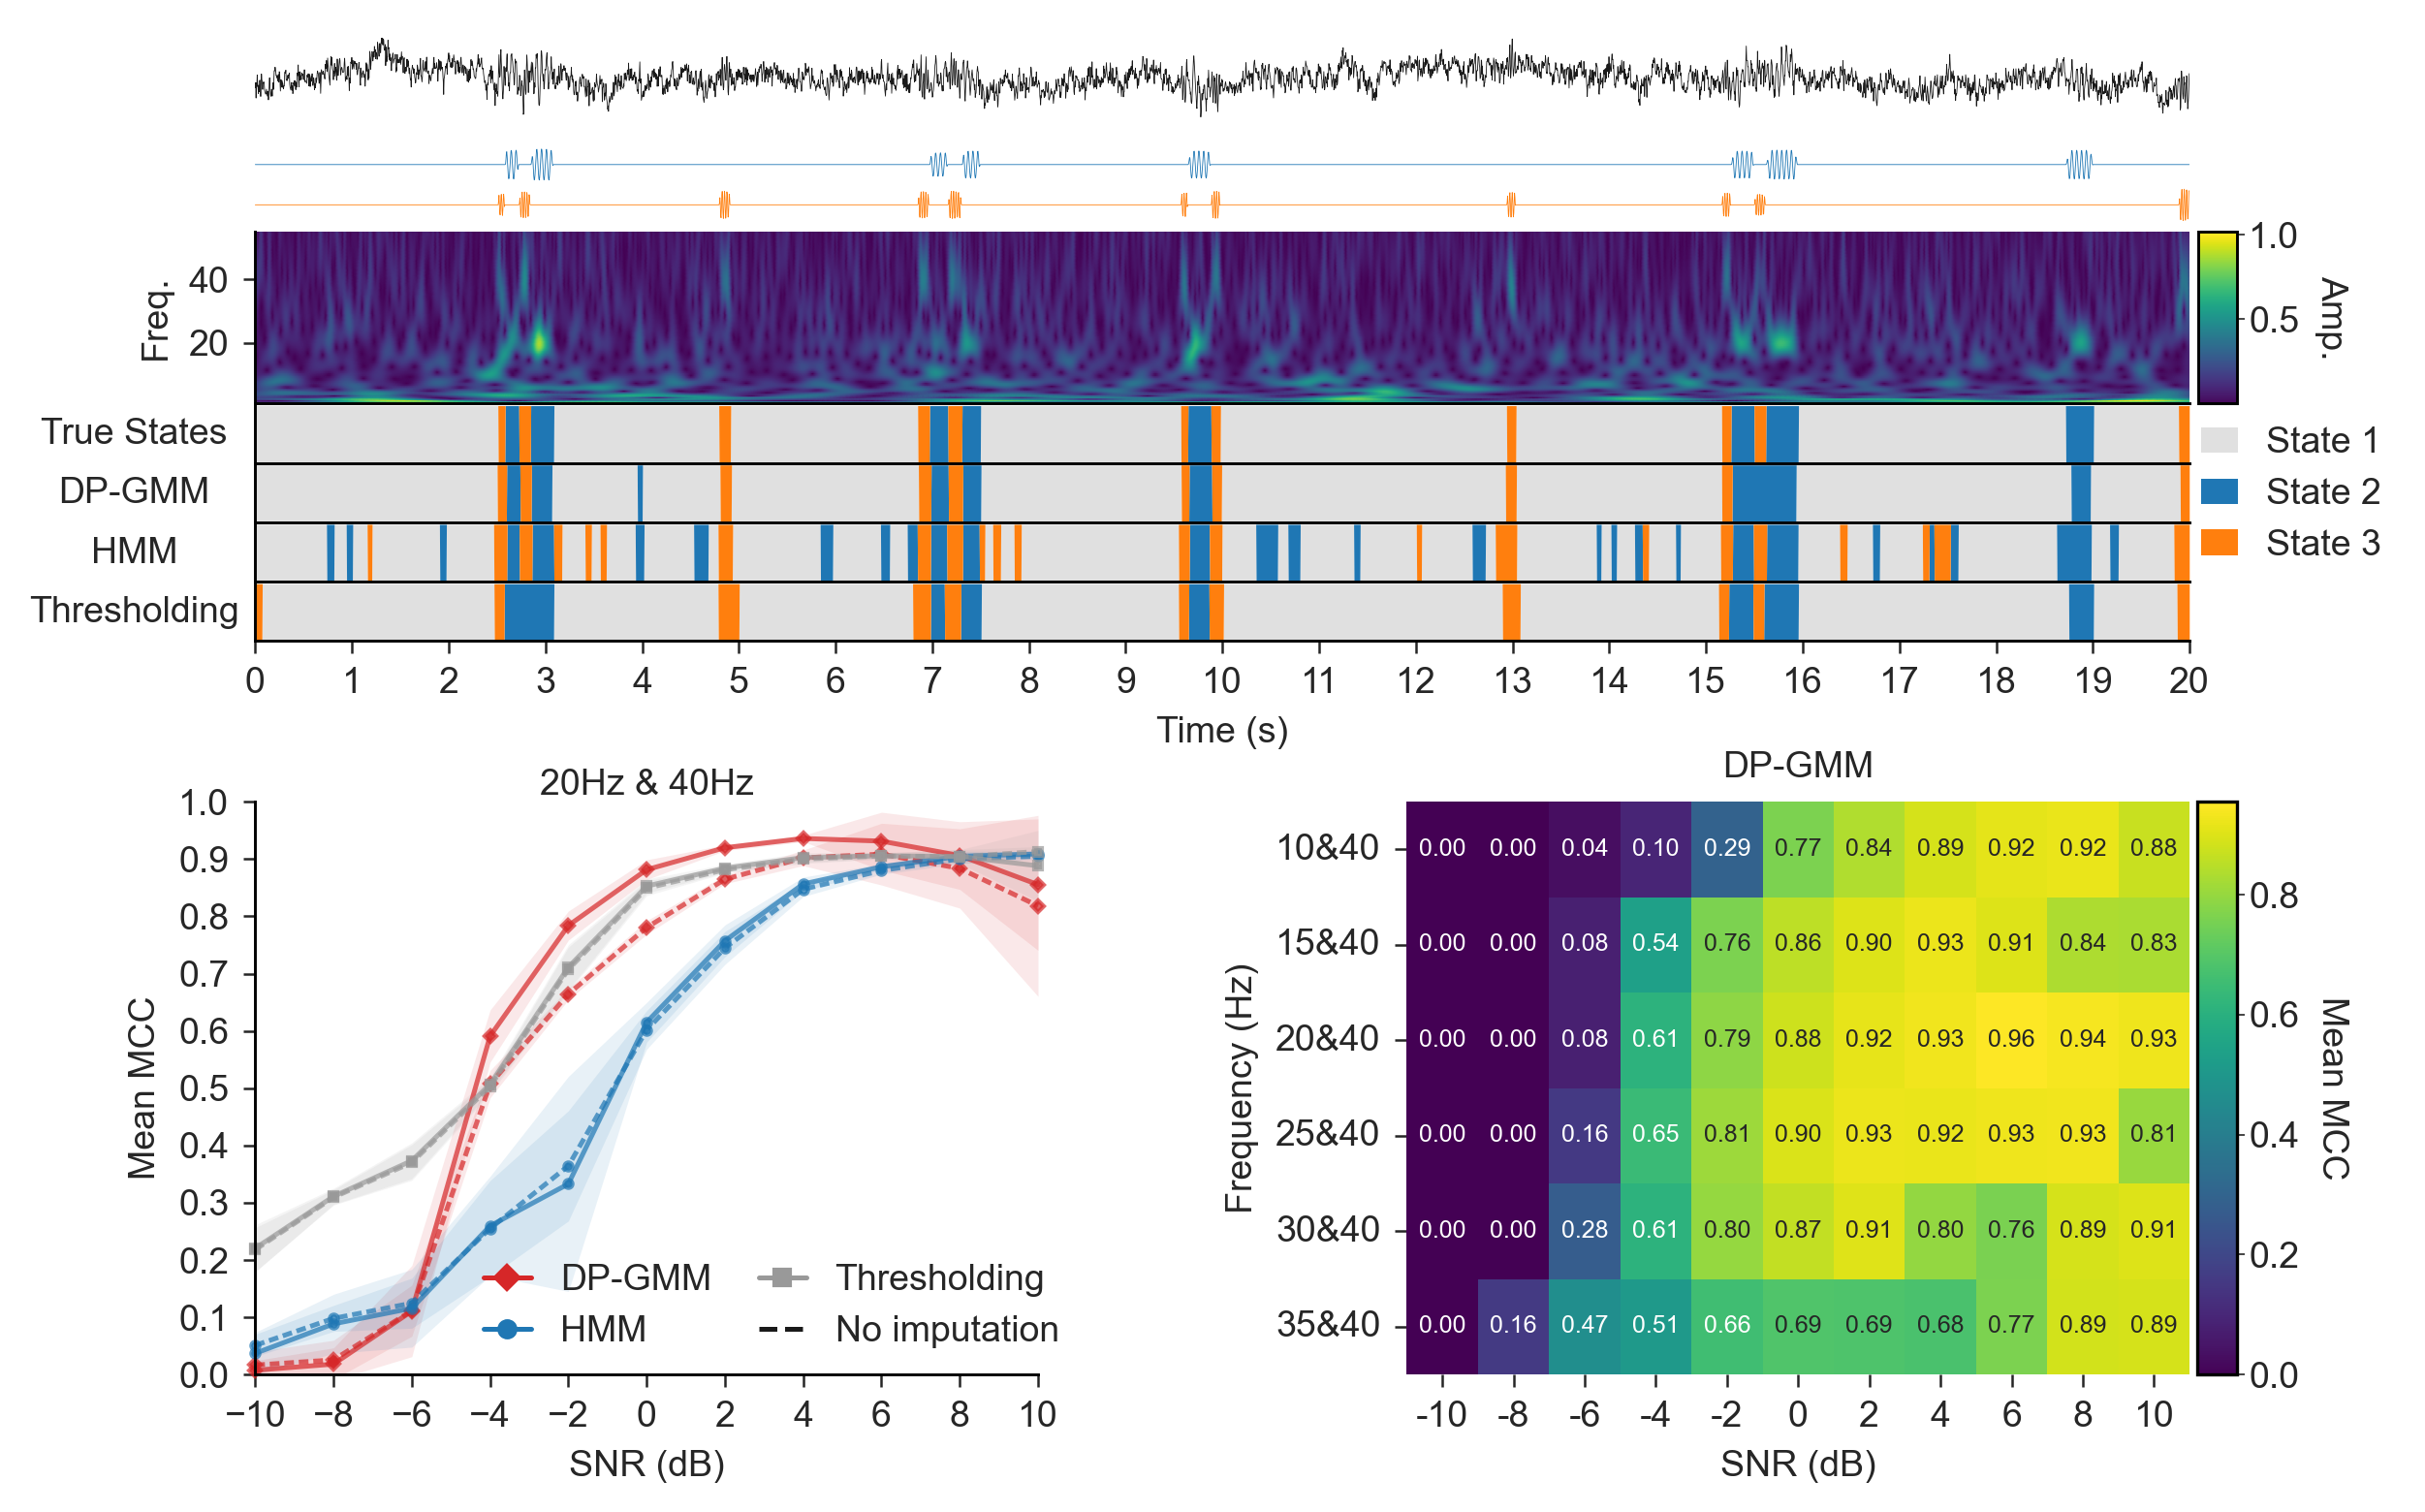

In [518]:

plt.close("all")

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D







plot_t = 20
#compute wavelet
t, f, amp = compute_wavelet(trimmed_signal[:plot_t*fs], fs, f_min = 1, f_max = 80, df = 0.5, wavelet = "cmor1.5-1.0")






cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(num_states)]
grey = ["#E0E0E0"]
colors = grey + colors
state_labels = [f"State {i+1}" for i in range(num_states)]



mosaic = [["b1", "b1"],
          ["b2", "b2"],
          ["b3", "b3"],
          ["b4", "b4"],
          ["b5", "b5"],
          ["b6", "b6"],
          ["a", "c"]
         ]

fig, axes = plt.subplot_mosaic(
    mosaic,
    figsize=(FIG_WIDTH, 5),  # a hair taller
    constrained_layout=True,
    gridspec_kw={"height_ratios":[0.7,0.6,0.2,0.2, 0.2,0.2,2]}
)
fig.set_constrained_layout_pads(w_pad=0., h_pad=0., hspace=0.01)




thresh_color = "#999999" # grey
hmm_color   = "#1f77b4"  # vivid blue
dpgmm_color   = "#d62728"

palette = {
    "Thresholding":                 thresh_color,
    "Thresholding (Imputed)":     thresh_color,
    "HMM":                   hmm_color,
    "HMM (Imputed)":       hmm_color,
    "DP-GMM":                 dpgmm_color,
    "DP-GMM (Imputed)":     dpgmm_color,
}

dashes = {
    "Thresholding":               (2, 1),      # dashed
    "Thresholding (Imputed)":   (None, None),# solid
    "HMM":                 (2, 1),
    "HMM (Imputed)":     (None, None),
    "DP-GMM":               (2, 1),
    "DP-GMM (Imputed)":   (None, None),
}

markers = {
    "Thresholding":               "s",   # square
    "Thresholding (Imputed)":   "s",
    "HMM":                 "o",   # circle
    "HMM (Imputed)":     "o",
    "DP-GMM":               "D",   # diamond
    "DP-GMM (Imputed)":   "D",
}


handles_left = [
    Line2D([0], [0], color=dpgmm_color, marker="D", lw=1.2, ms=4, linestyle="-", label="DP-GMM"),
    Line2D([0], [0], color=hmm_color, marker="o", lw=1.2, ms=4, linestyle="-", label="HMM"),
    Line2D([0], [0], color=thresh_color, marker="s", lw=1.2, ms=4, linestyle="-", label="Thresholding"),
]

handles_right = [
    Line2D([0], [0], color="k", lw=1.2, linestyle="--", label="No imputation")  # dashed example
]
handles = handles_left + handles_right
labels  = [h.get_label() for h in handles]

axes["a"].legend(
    handles, labels,
    ncols=2,
    loc="best",  # or adjust position
    frameon=False,
    bbox_to_anchor=(0.25, 0.25),
    columnspacing=1.3,
    handlelength=1.3
)



for method in df_avg["method"].unique():
    df_sub = df_avg[df_avg["method"] == method]
    label = method.replace("_", " ")
    axes["a"].plot(
        df_sub["snr"], df_sub["mcc_mean"],
        label=label,
        color=palette[method],
        marker=markers[method],
        linestyle='-' if dashes[method] == (None, None) else (0, dashes[method]),
        lw=1.2, ms=2, alpha=0.7, clip_on=False)
        # Shaded std band
    axes["a"].fill_between(
        df_sub["snr"],
        df_sub["mcc_mean"] - df_sub["mcc_std"],
        df_sub["mcc_mean"] + df_sub["mcc_std"],
        color=palette[method],
        alpha=0.1, clip_on=True,
        linewidth=0
    )
axes["a"].set_xticks(snr_range)
axes["a"].set_xlim(min(snr_range), max(snr_range))
axes["a"].set_ylim(0, 1)
axes["a"].yaxis.set_major_locator(MultipleLocator(0.1))
#axes["a"].yaxis.set_minor_locator(MultipleLocator(0.05))
#axes["a"].grid(True, which="both", linestyle=":", linewidth=0.5, alpha=0.5)
axes["a"].set_xlabel("SNR (dB)")
axes["a"].set_ylabel("Mean MCC")
#axes["a"].set_title(f"{plot_f[0]} Hz & {plot_f[1]} Hz",pad = 0.3)
axes["a"].set_title(f"20Hz & 40Hz",pad = 0.3)




axes["b1"].plot(trimmed_time_vec[:plot_t*fs], trimmed_signal[:plot_t*fs], lw=0.2, color="k")
axes["b1"].grid(False)
axes["b1"].set_frame_on(False)
#axes["b1"].set_title(f"Raw signal (SNR = {snr_db} dB)", pad= 0.3)


axes["b1"].plot(trimmed_time_vec[:plot_t*fs], -2+ trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 1), lw=0.2, color=colors[1])
axes["b1"].plot(trimmed_time_vec[:plot_t*fs], -3+ trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 2), lw=0.2, color=colors[2])




axes["b1"].set_yticks([])
axes["b1"].set_xticks([])






for s in ("top","right","bottom","left"):
    axes["b1"].spines[s].set_visible(False)
axes["b1"].set_frame_on(False)
axes["b1"].tick_params(axis='both', which='both',
                       bottom=False, top=False, left=False, right=False,
                       labelbottom=False, labelleft=False)





im = axes["b2"].imshow(
    amp, extent=[t[0], t[-1], f[0], f[-1]],
    origin="lower", aspect="auto", cmap="viridis",
    vmin=amp.min(), vmax=amp.max()
)
axes["b2"].set_ylabel("Freq.")
#axes["b2"].set_title("Wavelet Transform", pad = 0.3)





#axes["b2"].tick_params(axis='y', which='both', left=True, labelleft=True, l)
axes["b2"].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, labeltop=False)
axes["b2"].yaxis.set_major_locator(MultipleLocator(20))

axes["b2"].set_ylim(1, 55)


cax = inset_axes(
    axes["b2"],              # parent axis
    width="2%",              # width as percentage of a2
    height="100%",           # match the height
    loc="center right",      # position inside a2
    borderpad=-1.3             # negative value moves it outside slightly
)

# Add the colorbar to the inset axis
cb = fig.colorbar(im, cax=cax)
cb.set_label("Amp.", rotation = 270, labelpad = 12)
cb.ax.tick_params(which="both", length=2, width=0.4, pad=1)



axes["b3"].stackplot(trimmed_time_vec[:plot_t*fs], states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = state_labels)
axes["b3"].set_ylabel(f"True States", rotation = 0, labelpad=30, va="center")
axes["b3"].tick_params(axis='y', which='both', left=False, labelleft=False)


axes["b4"].stackplot(trimmed_time_vec[:plot_t*fs], dpgmm_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = [f"MCC = {dpgmm_mcc:.2f}"] + [None]*(num_states-1))
axes["b4"].set_ylabel(f"DP-GMM", rotation = 0, labelpad=30, va="center")



axes["b5"].stackplot(trimmed_time_vec[:plot_t*fs], hmm_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels =  f"MCC = {hmm_mcc:.2f}")
axes["b5"].set_ylabel(f"HMM", rotation = 0, labelpad=30, va="center")

axes["b6"].stackplot(trimmed_time_vec[:plot_t*fs], thresh_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = f"MCC = {thresh_mcc:.2f}")
axes["b6"].set_ylabel(f"Thresholding", rotation = 0, labelpad=30, va="center")



for key in ["b3", "b4", "b5"]:
    axes[key].tick_params(axis='x', which='both', bottom=False, labelbottom=False, length = 0)
    axes[key].tick_params(axis='y', which='both', left=False, labelleft=False)
    axes[key].set_yticks([])
    axes[key].set_xticks([])
    axes[key].spines["bottom"].set_visible(True)
    axes[key].set_ylim(0, 1)
    
for key in ["b1","b2", "b3", "b4", "b5", "b6"]:
    axes[key].sharex(axes["b1"])




axes["b6"].set_xlabel("Time (s)")
axes["b6"].xaxis.set_major_locator(MultipleLocator(1.0))
#axes["b6"].tick_params(axis='x', which='both', bottom=True, labelbottom=True, length = 0)
axes["b6"].tick_params(axis='y', which='both', left=False, labelleft=False)
axes["b6"].set_ylim(0, 1)
axes["b6"].set_xlim(0, plot_t)


axes["b6"].spines["bottom"].set_visible(True)   # keep x-axis frame


#axes["a"].tick_params(direction='in', length=3, width=0.4, bottom=True, left=True)

cax_heat = inset_axes(
    axes["c"],
    width="5%", height="100%",
    loc="center right",
    borderpad=-1.3
)

sns.heatmap(
    dpgmm_imputed_heat,
    annot=True, fmt=".2f", annot_kws={"size": 6},
    cmap="viridis", vmin=vmin, vmax=vmax,
    cbar=True, cbar_ax=cax_heat,
    ax=axes["c"]
)


cbar = axes["c"].collections[0].colorbar
cbar.set_label("Mean MCC", rotation=270, labelpad=12)
cbar.ax.tick_params(which="both", length=2, width=0.4, pad=1)
cbar.outline.set_visible(True)
cbar.outline.set_linewidth(0.8)

axes["c"].set_title("DP-GMM")
axes["c"].set_xlabel("SNR (dB)")
axes["c"].set_ylabel("Frequency (Hz)")






handles, labels = axes["b3"].get_legend_handles_labels()

fig.legend(handles, labels,
           loc="center left",
           bbox_to_anchor=(0.981, 0.68), # (x, y) in figure coordinates
           frameon=False,
           handlelength=1)



cb.solids.set_edgecolor("face")
cbar.solids.set_edgecolor("face")


fig.savefig(
    f"../figures/raw_figure/{sim_cond}_results.jpg",
    bbox_inches="tight"
)





## performance before imputation

In [486]:


dpgmm_res = gmm_df_3states.iloc[456]
hmm_res = res.query("method == 'HMM'").iloc[sample_id]
thresh_res = res.query("method == 'Thresholding'").iloc[sample_id]


dpgmm_states =dpgmm_res.est_states
dpgmm_mcc = dpgmm_res.mcc
dpgmm_states_onehot = np.eye(num_states+1)[dpgmm_states]

hmm_states = hmm_res.est_states
hmm_mcc = hmm_res.mcc
hmm_states_onehot = np.eye(num_states)[hmm_states]

thresh_states = thresh_res.est_states
thresh_mcc = thresh_res.mcc
thresh_states_onehot = np.eye(num_states)[thresh_states]



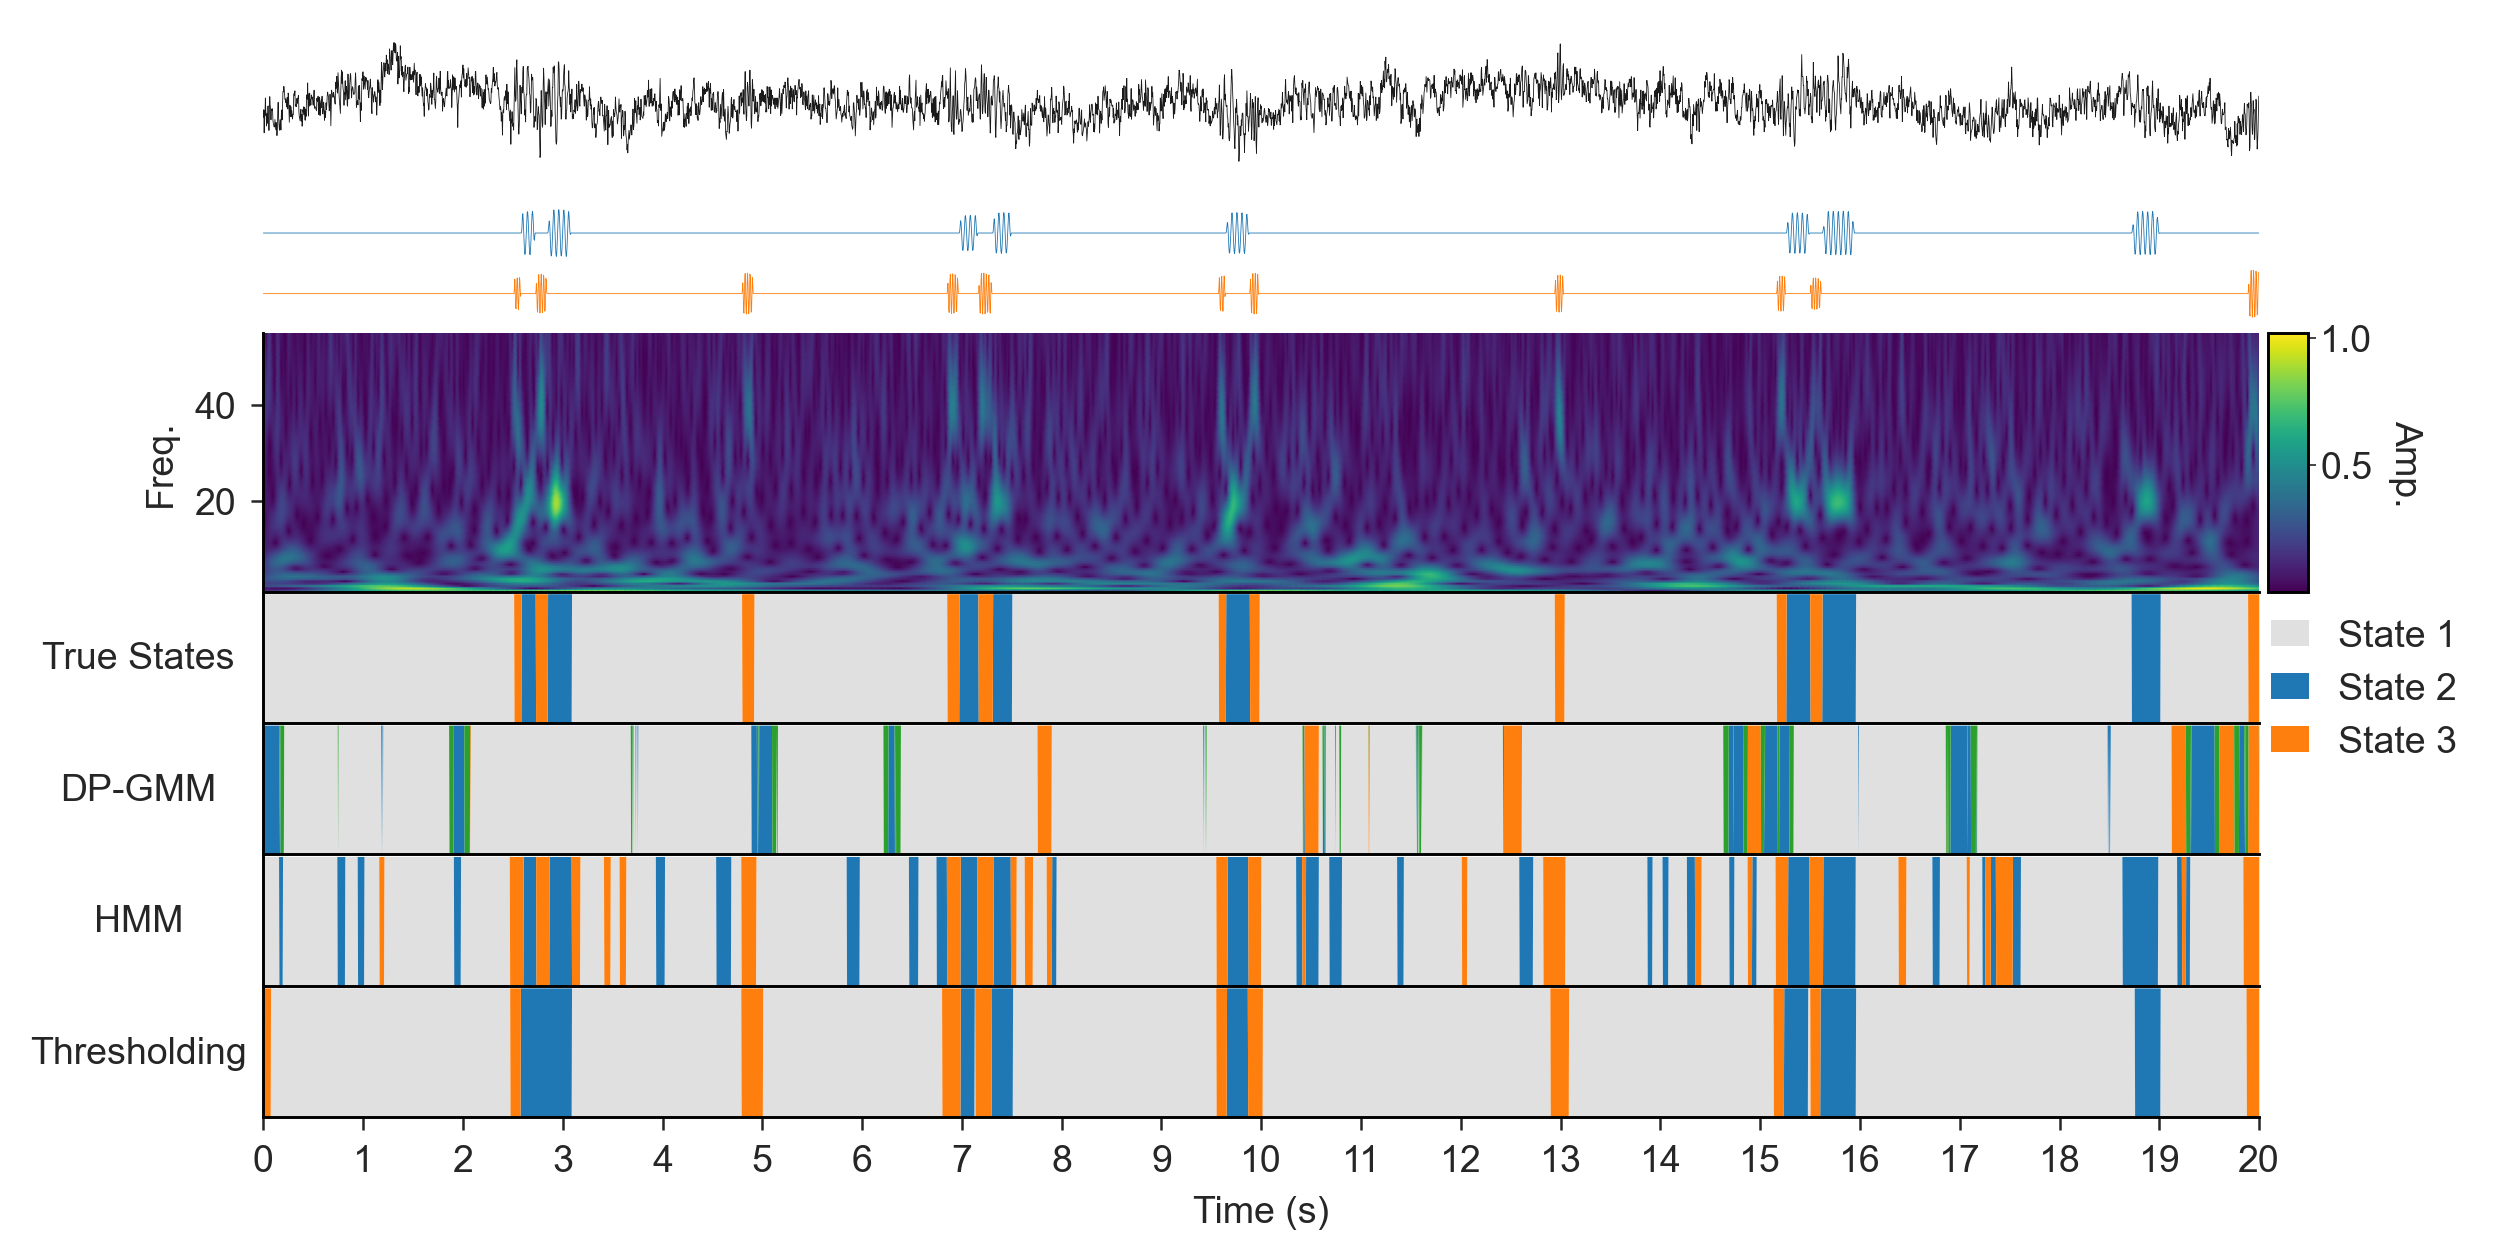

In [487]:


import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes







plot_t = 20
#compute wavelet
t, f, amp = compute_wavelet(trimmed_signal[:plot_t*fs], fs, f_min = 1, f_max = 80, df = 0.5, wavelet = "cmor1.5-1.0")






cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(num_states)]
grey = ["#E0E0E0"]
colors = grey + colors
state_labels = [f"State {i+1}" for i in range(num_states)]



mosaic = [["b1", "b1"],
          ["b2", "b2"],
          ["b3", "b3"],
          ["b4", "b4"],
          ["b5", "b5"],
          ["b6", "b6"],

         ]

fig, axes = plt.subplot_mosaic(
    mosaic,
    figsize=(FIG_WIDTH, 4),  # a hair taller
    constrained_layout=True,
    gridspec_kw={"height_ratios":[0.7,0.6,0.3,0.3, 0.3, 0.3]}
)
fig.set_constrained_layout_pads(w_pad=0., h_pad=0., hspace=0.01)





axes["b1"].plot(trimmed_time_vec[:plot_t*fs], trimmed_signal[:plot_t*fs], lw=0.2, color="k")
axes["b1"].grid(False)
axes["b1"].set_frame_on(False)
#axes["b1"].set_title(f"Raw signal (SNR = {snr_db} dB)", pad= 0.3)


axes["b1"].plot(trimmed_time_vec[:plot_t*fs], -2+ trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 1), lw=0.2, color=colors[1])
axes["b1"].plot(trimmed_time_vec[:plot_t*fs], -3+ trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 2), lw=0.2, color=colors[2])




axes["b1"].set_yticks([])
axes["b1"].set_xticks([])






for s in ("top","right","bottom","left"):
    axes["b1"].spines[s].set_visible(False)
axes["b1"].set_frame_on(False)
axes["b1"].tick_params(axis='both', which='both',
                       bottom=False, top=False, left=False, right=False,
                       labelbottom=False, labelleft=False)





im = axes["b2"].imshow(
    amp, extent=[t[0], t[-1], f[0], f[-1]],
    origin="lower", aspect="auto", cmap="viridis",
    vmin=amp.min(), vmax=amp.max()
)
axes["b2"].set_ylabel("Freq.")
#axes["b2"].set_title("Wavelet Transform", pad = 0.3)





#axes["b2"].tick_params(axis='y', which='both', left=True, labelleft=True, l)
axes["b2"].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, labeltop=False)
axes["b2"].yaxis.set_major_locator(MultipleLocator(20))

axes["b2"].set_ylim(1, 55)


cax = inset_axes(
    axes["b2"],              # parent axis
    width="2%",              # width as percentage of a2
    height="100%",           # match the height
    loc="center right",      # position inside a2
    borderpad=-1.3             # negative value moves it outside slightly
)

# Add the colorbar to the inset axis
cb = fig.colorbar(im, cax=cax)
cb.set_label("Amp.", rotation = 270, labelpad = 12)
cb.ax.tick_params(which="both", length=2, width=0.4, pad=1)



axes["b3"].stackplot(trimmed_time_vec[:plot_t*fs], states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = state_labels)
axes["b3"].set_ylabel(f"True States", rotation = 0, labelpad=30, va="center")
axes["b3"].tick_params(axis='y', which='both', left=False, labelleft=False)


axes["b4"].stackplot(trimmed_time_vec[:plot_t*fs], dpgmm_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = [f"MCC = {dpgmm_mcc:.2f}"] + [None]*(num_states-1))
axes["b4"].set_ylabel(f"DP-GMM", rotation = 0, labelpad=30, va="center")



axes["b5"].stackplot(trimmed_time_vec[:plot_t*fs], hmm_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels =  f"MCC = {hmm_mcc:.2f}")
axes["b5"].set_ylabel(f"HMM", rotation = 0, labelpad=30, va="center")

axes["b6"].stackplot(trimmed_time_vec[:plot_t*fs], thresh_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = f"MCC = {thresh_mcc:.2f}")
axes["b6"].set_ylabel(f"Thresholding", rotation = 0, labelpad=30, va="center")



for key in ["b3", "b4", "b5"]:
    axes[key].tick_params(axis='x', which='both', bottom=False, labelbottom=False, length = 0)
    axes[key].tick_params(axis='y', which='both', left=False, labelleft=False)
    axes[key].set_yticks([])
    axes[key].set_xticks([])
    axes[key].spines["bottom"].set_visible(True)
    axes[key].set_ylim(0, 1)
    
for key in ["b1","b2", "b3", "b4", "b5", "b6"]:
    axes[key].sharex(axes["b1"])




axes["b6"].set_xlabel("Time (s)")
axes["b6"].xaxis.set_major_locator(MultipleLocator(1.0))
#axes["b6"].tick_params(axis='x', which='both', bottom=True, labelbottom=True, length = 0)
axes["b6"].tick_params(axis='y', which='both', left=False, labelleft=False)
axes["b6"].set_ylim(0, 1)
axes["b6"].set_xlim(0, plot_t)


axes["b6"].spines["bottom"].set_visible(True)   # keep x-axis frame






handles, labels = axes["b3"].get_legend_handles_labels()

fig.legend(handles, labels,
           loc="center left",          # anchor to left of the bbox
           bbox_to_anchor=(0.981, 0.45), # (x, y) in figure coordinates
           frameon=False,
           handlelength=1)


fig.savefig(
    f"../figures/raw_figure/{sim_cond}_before_imputation.jpg",
    bbox_inches="tight"
)





In [488]:
res

,method,signal,true_states,burst_f,fs,snr,est_params,loss_best,model_id_best,seed_best,...,total_time,num_states,num_emb,est_states,order,summary_stats,mcc,loss,best_model_id,num_active_states
108,HMM,"[1.5445020337595194, 1.1558912845145457, 1.250...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 40)",250,0,"{'initial_probs': [0.6759958, 0.2201278, 0.103...",0.79147,NaN,NaN,...,33.217954,3,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 2, 0]",None,0.614318,0.79147,4.0,NaN
109,HMM (Imputed),"[1.5445020337595194, 1.1558912845145457, 1.250...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 40)",250,0,"{'initial_probs': [0.6759958, 0.2201278, 0.103...",0.79147,NaN,NaN,...,33.217954,3,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 2, 0]",None,0.627482,0.79147,4.0,NaN
110,Thresholding,"[1.5445020337595194, 1.1558912845145457, 1.250...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 40)",250,0,"{'envelped_signal': [[0.26119015, 0.25823346, ...",NaN,NaN,NaN,...,1.417694,3,21,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[0, 1, 2]",None,0.856723,"[[1.5, 1.3], [1.5, 1.4000000000000001]]",NaN,NaN
111,Thresholding (Imputed),"[1.5445020337595194, 1.1558912845145457, 1.250...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 40)",250,0,"{'envelped_signal': [[0.26119015, 0.25823346, ...",NaN,NaN,NaN,...,1.417694,3,21,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[0, 1, 2]",None,0.859918,"[[1.5, 1.3], [1.5, 1.4000000000000001]]",NaN,NaN
372,HMM,"[0.0913365564686968, 0.4198725313872575, 0.313...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","(20, 40)",250,0,"{'initial_probs': [0.60570526, 0.22362876, 0.1...",0.781568,NaN,NaN,...,33.751017,3,21,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 0, 2]",None,0.595465,0.781568,1.0,NaN
373,HMM (Imputed),"[0.0913365564686968, 0.4198725313872575, 0.313...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","(20, 40)",250,0,"{'initial_probs': [0.60570526, 0.22362876, 0.1...",0.781568,NaN,NaN,...,33.751017,3,21,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 0, 2]",None,0.608290,0.781568,1.0,NaN
374,Thresholding,"[0.0913365564686968, 0.4198725313872575, 0.313...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","(20, 40)",250,0,"{'envelped_signal': [[0.5237863, 0.54249674, 0...",NaN,NaN,NaN,...,1.389082,3,21,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 1, 2]",None,0.841283,"[[1.5, 1.4000000000000001], [1.6, 1.5]]",NaN,NaN
375,Thresholding (Imputed),"[0.0913365564686968, 0.4198725313872575, 0.313...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","(20, 40)",250,0,"{'envelped_signal': [[0.5237863, 0.54249674, 0...",NaN,NaN,NaN,...,1.389082,3,21,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 1, 2]",None,0.845770,"[[1.5, 1.4000000000000001], [1.6, 1.5]]",NaN,NaN
636,HMM,"[-0.3805633923897862, -0.008341560298572132, -...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 40)",250,0,"{'initial_probs': [0.59881675, 0.1620018, 0.23...",0.764077,NaN,NaN,...,27.390202,3,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 2]",None,0.626689,0.764077,7.0,NaN
637,HMM (Imputed),"[-0.3805633923897862, -0.008341560298572132, -...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","(20, 40)",250,0,"{'initial_probs': [0.59881675, 0.1620018, 0.23...",0.764077,NaN,NaN,...,27.390202,3,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 2]",None,0.641968,0.764077,7.0,NaN


In [489]:
df_3states.head()

,method,signal,true_states,burst_f,fs,snr,est_params,loss_best,model_id_best,seed_best,...,total_time,num_states,num_emb,est_states,order,summary_stats,mcc,loss,best_model_id,num_active_states
0,HMM,"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...",10&40,250,-10,"{'initial_probs': [0.31679845, 0.32383534, 0.3...",0.722242,NaN,NaN,...,38.693617,3,25,"[2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 2]",None,0.024007,0.722242,5.0,NaN
1,HMM (Imputed),"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...",10&40,250,-10,"{'initial_probs': [0.31679845, 0.32383534, 0.3...",0.722242,NaN,NaN,...,38.693617,3,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 2]",None,0.021481,0.722242,5.0,NaN
2,Thresholding,"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...",10&40,250,-10,"{'envelped_signal': [[0.17682067, 0.18038164, ...",NaN,NaN,NaN,...,2.789531,3,25,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, ...","[0, 1, 2]",None,0.198367,"[[0.4, 0.4], [0.4, 0.4]]",NaN,NaN
3,Thresholding (Imputed),"[-1.0699453867332631, -0.5765764895141492, -0....","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...",10&40,250,-10,"{'envelped_signal': [[0.17682067, 0.18038164, ...",NaN,NaN,NaN,...,2.789531,3,25,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[0, 1, 2]",None,0.202390,"[[0.4, 0.4], [0.4, 0.4]]",NaN,NaN
4,HMM,"[1.1215779014010478, 0.2241747638346373, 0.649...","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...",10&40,250,-8,"{'initial_probs': [0.34434733, 0.3593983, 0.29...",0.63744,NaN,NaN,...,39.445304,3,25,"[1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, ...","[0, 1, 2]",None,0.067480,0.63744,6.0,NaN


In [490]:
dpgmm_states.max()

np.int64(3)

In [521]:
num_states = 3
snr_db = 10
snr_id = np.where(snr_range == snr_db)[0][0]
plot_f = (30, 40)
freq_id = np.where((np.array(freqs_dist_range) == np.array(plot_f)).all(axis=1))[0][0]

sample_id = 4

res = gmm_df_3states.query("burst_f == @plot_f and snr == @snr_db")
dpgmm_res = res.query("method == 'DP-GMM'").iloc[sample_id]


num_emb = int(res.num_emb.values[0])

dpgmm_states =dpgmm_res.est_states
num_active_states = dpgmm_states.max()+1

dpgmm_mcc = dpgmm_res.mcc
dpgmm_states_onehot = np.eye(num_active_states)[dpgmm_states]





trimmed_signal = trim_data(signal_sample[sample_id, freq_id, snr_id], num_emb)
trimmed_states = trim_data(states_sample[sample_id, freq_id, snr_id], num_emb).astype(int)
trimmed_bursts = trim_data(bursts_sample[sample_id, freq_id, snr_id], num_emb)


trimmed_time_vec = np.linspace(0, len(trimmed_states)/fs, len(trimmed_states))
states_onehot = np.eye(num_states)[trimmed_states]



print("num_active_states", num_active_states)
print("mcc", dpgmm_mcc)


Lost 9 data points were lost from both ends.
data shape: (44982,)
Lost 9 data points were lost from both ends.
data shape: (44982,)
Lost 9 data points were lost from both ends.
data shape: (44982,)
num_active_states 4
mcc 0.7348502037255896


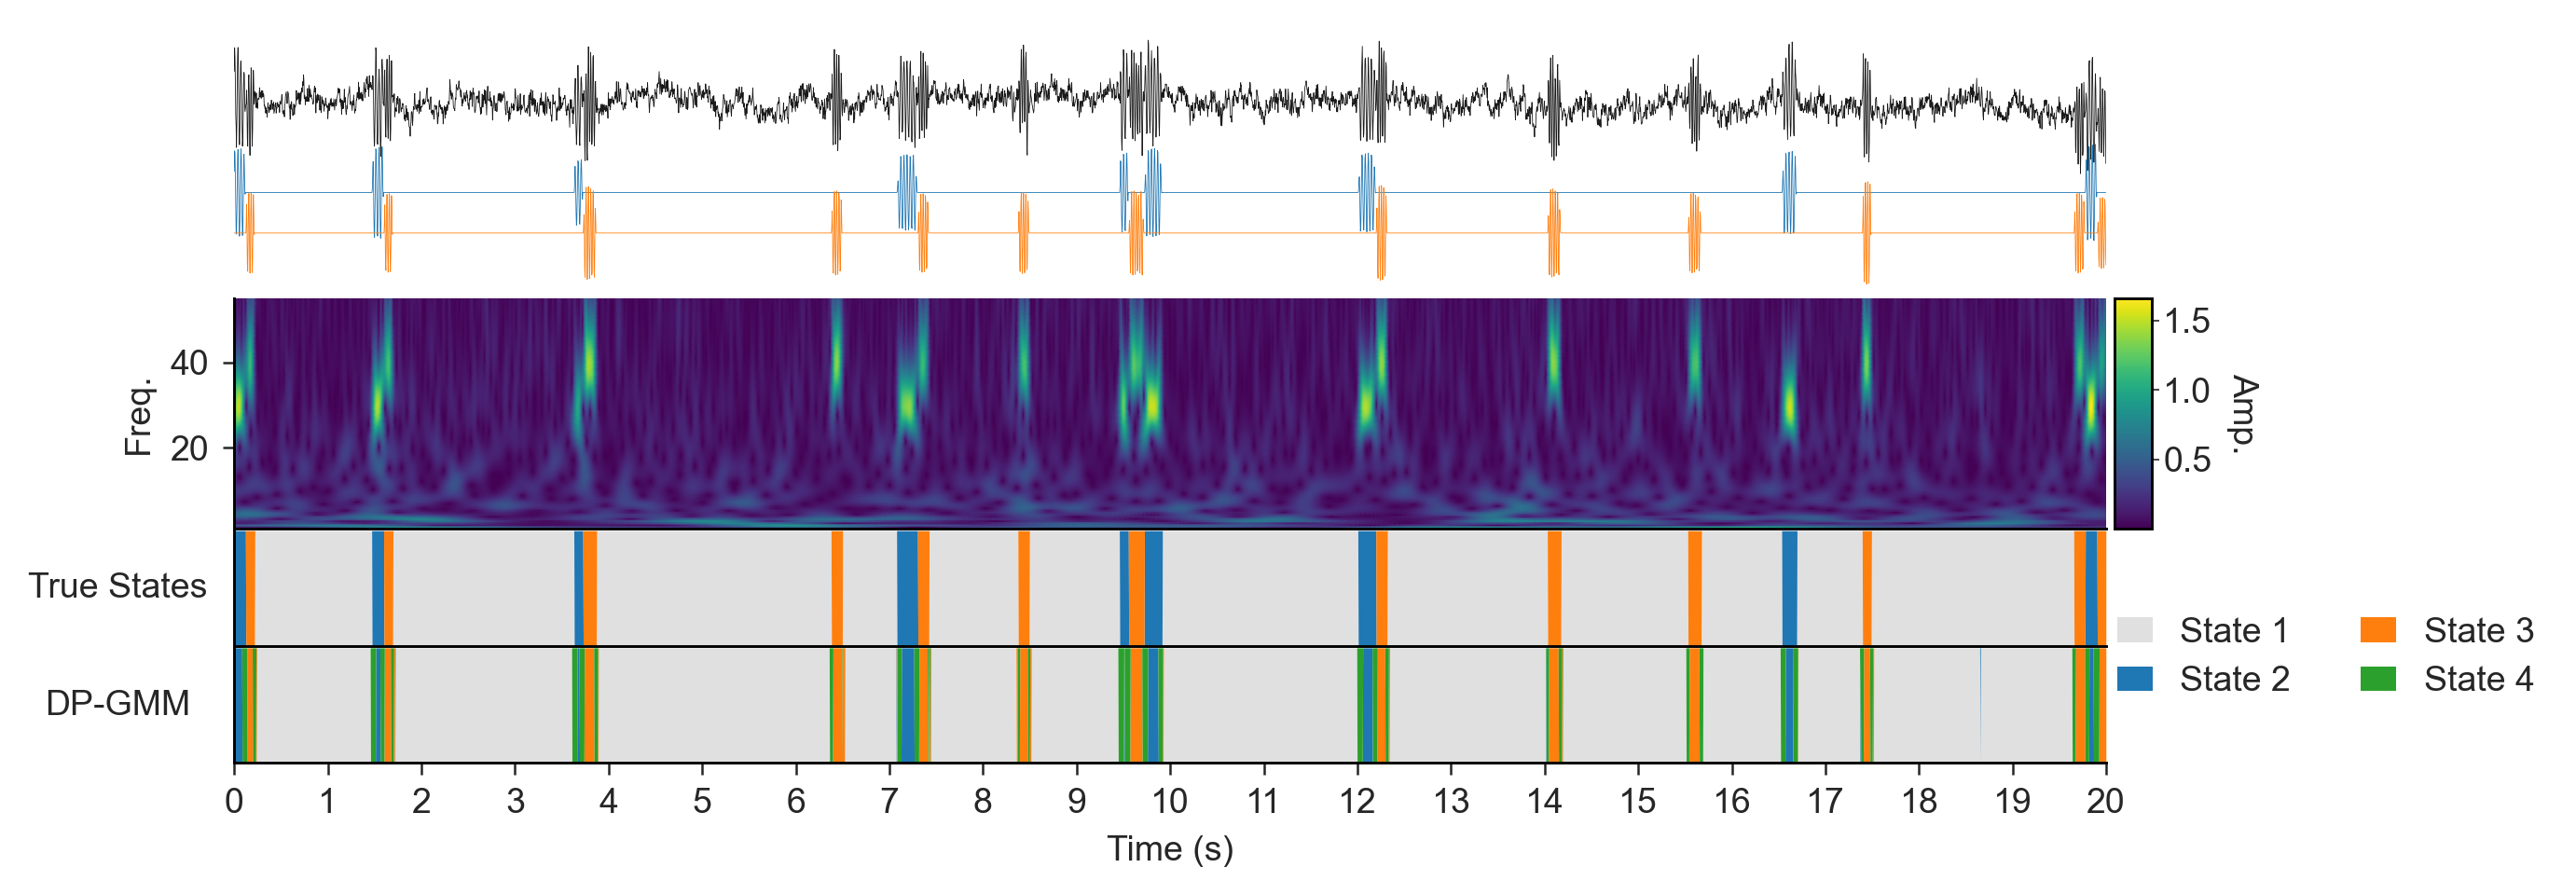

In [522]:


import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes







plot_t = 20
#compute wavelet
t, f, amp = compute_wavelet(trimmed_signal[:plot_t*fs], fs, f_min = 1, f_max = 80, df = 0.5, wavelet = "cmor1.5-1.0")






cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(num_active_states)]
grey = ["#E0E0E0"]
colors = grey + colors
state_labels = [f"State {i+1}" for i in range(num_active_states)]



mosaic = [["b1", "b1"],
          ["b2", "b2"],
          ["b3", "b3"],
          ["b4", "b4"],
         ]

fig, axes = plt.subplot_mosaic(
    mosaic,
    figsize=(FIG_WIDTH, 3),  # a hair taller
    constrained_layout=True,
    gridspec_kw={"height_ratios":[0.7,0.6,0.3,0.3]}
)
fig.set_constrained_layout_pads(w_pad=0., h_pad=0., hspace=0.01)





axes["b1"].plot(trimmed_time_vec[:plot_t*fs], 0.3*(trimmed_signal[:plot_t*fs]), lw=0.2, color="k")
axes["b1"].grid(False)
axes["b1"].set_frame_on(False)
#axes["b1"].set_title(f"Raw signal (SNR = {snr_db} dB)", pad= 0.3)


axes["b1"].plot(trimmed_time_vec[:plot_t*fs], 0.3*(-2+ trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 1)), lw=0.2, color=colors[1])
axes["b1"].plot(trimmed_time_vec[:plot_t*fs], 0.3*(-3+ trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 2)), lw=0.2, color=colors[2])




axes["b1"].set_yticks([])
axes["b1"].set_xticks([])






for s in ("top","right","bottom","left"):
    axes["b1"].spines[s].set_visible(False)
axes["b1"].set_frame_on(False)
axes["b1"].tick_params(axis='both', which='both',
                       bottom=False, top=False, left=False, right=False,
                       labelbottom=False, labelleft=False)





im = axes["b2"].imshow(
    amp, extent=[t[0], t[-1], f[0], f[-1]],
    origin="lower", aspect="auto", cmap="viridis",
    vmin=amp.min(), vmax=amp.max()
)
axes["b2"].set_ylabel("Freq.")
#axes["b2"].set_title("Wavelet Transform", pad = 0.3)





#axes["b2"].tick_params(axis='y', which='both', left=True, labelleft=True, l)
axes["b2"].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, labeltop=False)
axes["b2"].yaxis.set_major_locator(MultipleLocator(20))

axes["b2"].set_ylim(1, 55)


cax = inset_axes(
    axes["b2"],              # parent axis
    width="2%",              # width as percentage of a2
    height="100%",           # match the height
    loc="center right",      # position inside a2
    borderpad=-1.3             # negative value moves it outside slightly
)

# Add the colorbar to the inset axis
cb = fig.colorbar(im, cax=cax)
cb.set_label("Amp.", rotation = 270, labelpad = 12)
cb.ax.tick_params(which="both", length=2, width=0.4, pad=1)



axes["b3"].stackplot(trimmed_time_vec[:plot_t*fs], states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = state_labels)
axes["b3"].set_ylabel(f"True States", rotation = 0, labelpad=30, va="center")
axes["b3"].tick_params(axis='y', which='both', left=False, labelleft=False)


axes["b4"].stackplot(trimmed_time_vec[:plot_t*fs], dpgmm_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = state_labels)
axes["b4"].set_ylabel(f"DP-GMM", rotation = 0, labelpad=30, va="center")




for key in ["b3"]:
    axes[key].tick_params(axis='x', which='both', bottom=False, labelbottom=False, length = 0)
    axes[key].tick_params(axis='y', which='both', left=False, labelleft=False)
    axes[key].set_yticks([])
    axes[key].set_xticks([])
    axes[key].spines["bottom"].set_visible(True)
    axes[key].set_ylim(0, 1)

for key in ["b1","b2", "b3", "b4"]:
    axes[key].sharex(axes["b1"])




axes["b4"].set_xlabel("Time (s)")
axes["b4"].xaxis.set_major_locator(MultipleLocator(1.0))
#axes["b6"].tick_params(axis='x', which='both', bottom=True, labelbottom=True, length = 0)
axes["b4"].tick_params(axis='y', which='both', left=False, labelleft=False)
axes["b4"].set_ylim(0, 1)
axes["b4"].set_xlim(0, plot_t)


axes["b4"].spines["bottom"].set_visible(True)   # keep x-axis frame






handles, labels = axes["b4"].get_legend_handles_labels()

fig.legend(handles, labels,
           loc="center left",          # anchor to left of the bbox
           ncol = 2,
           bbox_to_anchor=(0.981, 0.25), # (x, y) in figure coordinates
           frameon=False,
           handlelength=1)







/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


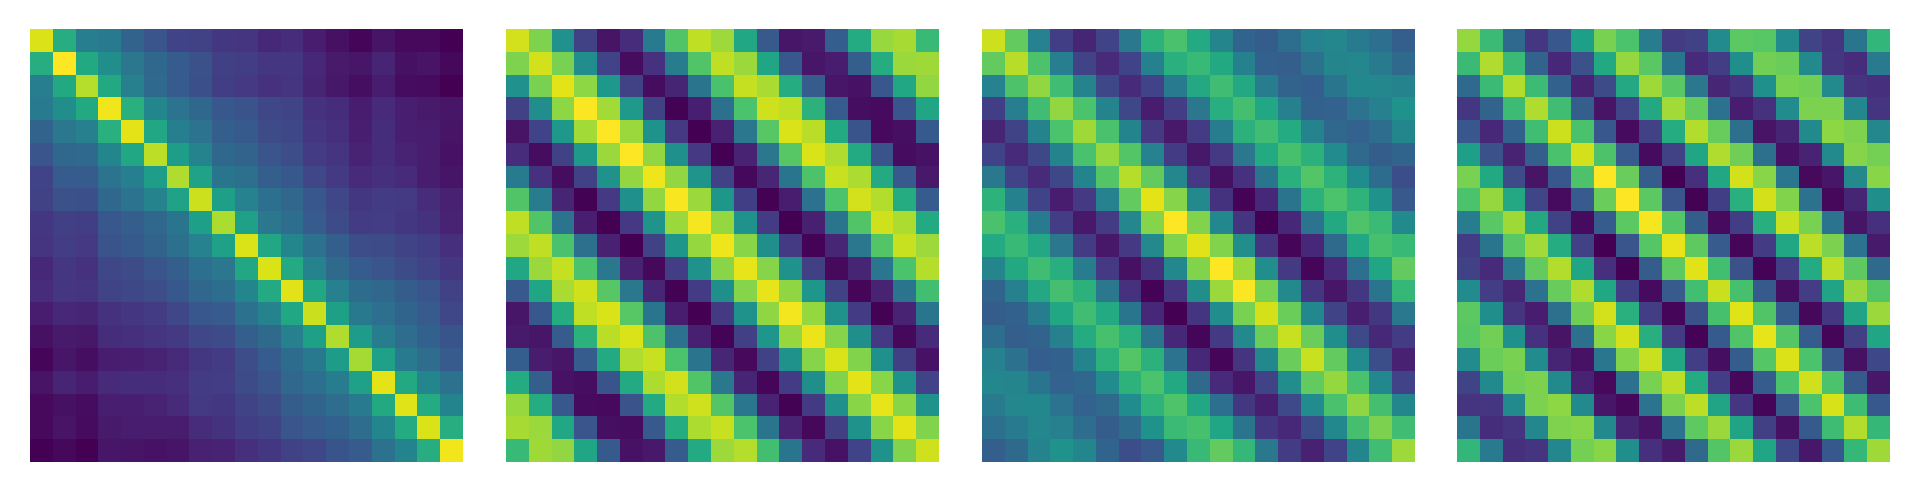

In [523]:
covs = dpgmm_res["est_params"]["covs"]


fig, ax = plt.subplots(1, covs.shape[0], figsize = (covs.shape[0]*2, 2), gridspec_kw = {"wspace":0.1})
for i ,cov in enumerate(covs):
    ax[i].imshow(cov,  cmap = "viridis")
    ax[i].set_axis_off()



# 4 states scenario

In [159]:
sim_cond = "4states_500Hz"
data_dir = "../data/simulations"
data_file = f"{data_dir}/{sim_cond}_data.npz"


sim_data = np.load(data_file)

signal = sim_data["signal_sample"]
states = sim_data["states_sample"]
bursts = sim_data["bursts_sample"]


import pickle
performance_dir = "../data/performance"
save_path = os.path.join(performance_dir, f"{sim_cond}_res.pkl")

# Load
with open(save_path, "rb") as f:
    res = pickle.load(f)



In [160]:
res = pd.DataFrame(res)

In [161]:
from nds_toolbox.preprocessing.features import compute_tde, trim_data, choose_embedding_dim

In [163]:

n_seconds = 60*3  # Total duration in seconds.
fs = 500

snr_db = 2

freq = np.array([20, 30, 40])  #ground truth = 4 states (including noise state)
num_emb = choose_embedding_dim(np.mean(freq), fs, min_cycles = 2.5, ensure_odd = True)
tde_signal = compute_tde(signal, num_emb)



trimmed_states = trim_data(states, num_embeddings = num_emb, verbose = False)
trimmed_signal = trim_data(signal, num_embeddings = num_emb, verbose = False)
trimmed_bursts = trim_data(bursts, num_embeddings = num_emb, verbose = False)
trimmed_time_vec = np.linspace(0, len(trimmed_states)/fs, len(trimmed_states))




num_states = int(np.ceil(np.log(len(trimmed_signal))))
print(num_states)

Chosen window size = 0.083 (sec): minimum cycles of 2.5 at 30.0 Hz
Chosen embedding dimension = 43: sampling rate = 500 Hz
21 data points were lost from both ends.
data shape: (89958, 43)
12


In [164]:
res

,method,signal,true_states,burst_f,fs,snr,est_params,loss_best,model_id_best,seed_best,...,pred_t,total_time,num_states,num_emb,est_states,order,summary_stats,mcc,loss,best_model_id
0,DP-GMM,"[0.3501775639540696, 0.41021854625444537, -0.2...","[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[20, 30, 40]",500,2,"{'alpha': 0.7428254, 'weights': [0.6953572, 0....",0.5518693,0.0,2.261167e+09,...,2.123067,582.542505,12,43,"[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[0, 1, 3, 2, 4, 5, 6, 7, 8, 9, 10, 11]",{'fractional_occupancies': [0.7451922008048201...,0.860828,0.5518693,NaN
1,DP-GMM (Imputed),"[0.3501775639540696, 0.41021854625444537, -0.2...","[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[20, 30, 40]",500,2,"{'alpha': 0.7428254, 'weights': [0.6953572, 0....",0.5518693,0.0,2.261167e+09,...,2.123067,582.542505,12,43,"[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[0, 1, 3, 2, 4, 5, 6, 7, 8, 9, 10, 11]",{'fractional_occupancies': [0.7688032192801085...,0.938126,0.5518693,NaN
2,HMM,"[0.3501775639540696, 0.41021854625444537, -0.2...","[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[20, 30, 40]",500,2,"{'initial_probs': [0.2737585, 0.118609704, 0.1...",0.526602,NaN,NaN,...,0.732422,385.694778,12,43,"[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[6, 10, 8, 2, 0, 1, 3, 4, 5, 7, 9, 11]","{'fractional_occupancies': [0.362357989283888,...",0.476174,0.526602,0.0
3,HMM (Imputed),"[0.3501775639540696, 0.41021854625444537, -0.2...","[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[20, 30, 40]",500,2,"{'initial_probs': [0.2737585, 0.118609704, 0.1...",0.526602,NaN,NaN,...,0.732422,385.694778,12,43,"[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...","[6, 10, 8, 2, 0, 1, 3, 4, 5, 7, 9, 11]",{'fractional_occupancies': [0.4304230863291758...,0.534381,0.526602,0.0


In [165]:
res.query("method == 'DP-GMM'").est_params.values[0].keys()

dict_keys(['alpha', 'weights', 'means', 'covs', 'untrunc_means', 'untrunc_covs', 'untrunc_weights', 'trunc_info', 'num_states_active'])

In [166]:

from nds_toolbox.models.dpgmm_numpyro import truncate, get_states
from sklearn.metrics import matthews_corrcoef

In [170]:
res.query("method == 'DP-GMM'").est_params.values[0].keys()

dict_keys(['alpha', 'weights', 'means', 'covs', 'untrunc_means', 'untrunc_covs', 'untrunc_weights', 'trunc_info', 'num_states_active'])

In [177]:
order_gmm

array([ 0,  1,  3,  2,  4,  5,  6,  7,  8,  9, 10, 11])

In [173]:

gmm_states = res.query("method == 'DP-GMM (Imputed)'").est_states.to_numpy()[0]
gmm_states_onehot = np.eye(num_states)[gmm_states]
gmm_mcc = res.query("method == 'DP-GMM (Imputed)'").mcc.values[0]


gmm_sumary_stats = res.query("method == 'DP-GMM (Imputed)'")["summary_stats"].values[0]
gmm_fo = gmm_sumary_stats["fractional_occupancies"]
gmm_f, gmm_psds = gmm_sumary_stats["spectra"]



order_gmm = res.query("method == 'DP-GMM (Imputed)'").order.to_numpy()[0]
alpha, weights, gmm_means, gmm_covs, untrunc_means, untrunc_covs, untrunc_weights, trunc_info, nun_active_states  = res.query("method == 'DP-GMM'").est_params.values[0].values()

untrunc_means = untrunc_means[order_gmm]
untrunc_covs = untrunc_covs[order_gmm]
untrunc_weights = untrunc_weights[order_gmm]

#trunc_means, trunc_covs, trunc_weights = truncate(1, gmm_means, gmm_covs, weights, verbose = True)
#gmm_states = get_states(tde_signal, trunc_means, trunc_covs, trunc_weights)
#gmm_mcc = matthews_corrcoef(trimmed_states, gmm_states)


hmm_states = res.query("method == 'HMM (Imputed)'").est_states.to_numpy()[0]
hmm_states_onehot = np.eye(num_states)[hmm_states]
hmm_mcc = res.query("method == 'HMM (Imputed)'").mcc.values[0]

hmm_sumary_stats = res.query("method == 'HMM (Imputed)'")["summary_stats"].values[0]
#hmm_fo = hmm_sumary_stats["fractional_occupancies"]
hmm_f, hmm_psds = hmm_sumary_stats["spectra"]



order_hmm = res.query("method == 'HMM (Imputed)'").order.to_numpy()[0]
init_probs, trans_mat, hmm_means, hmm_covs, stationary_dist = res.query("method == 'HMM (Imputed)'").est_params.values[0].values()




/var/folders/5z/yggynsqj6632pbql_bb3kqm40000gn/T/ipykernel_27383/3592749920.py:167: UserWarning: Using the axes or figure transform requires a bounding box in the respective coordinates. Using bbox_to_anchor=(0, 0, 1, 1) now.
  ax_b = inset_axes(axes["b"],
/var/folders/5z/yggynsqj6632pbql_bb3kqm40000gn/T/ipykernel_27383/3592749920.py:198: UserWarning: Using the axes or figure transform requires a bounding box in the respective coordinates. Using bbox_to_anchor=(0, 0, 1, 1) now.
  ab_c = inset_axes(axes["c"],


IndexError: list index out of range

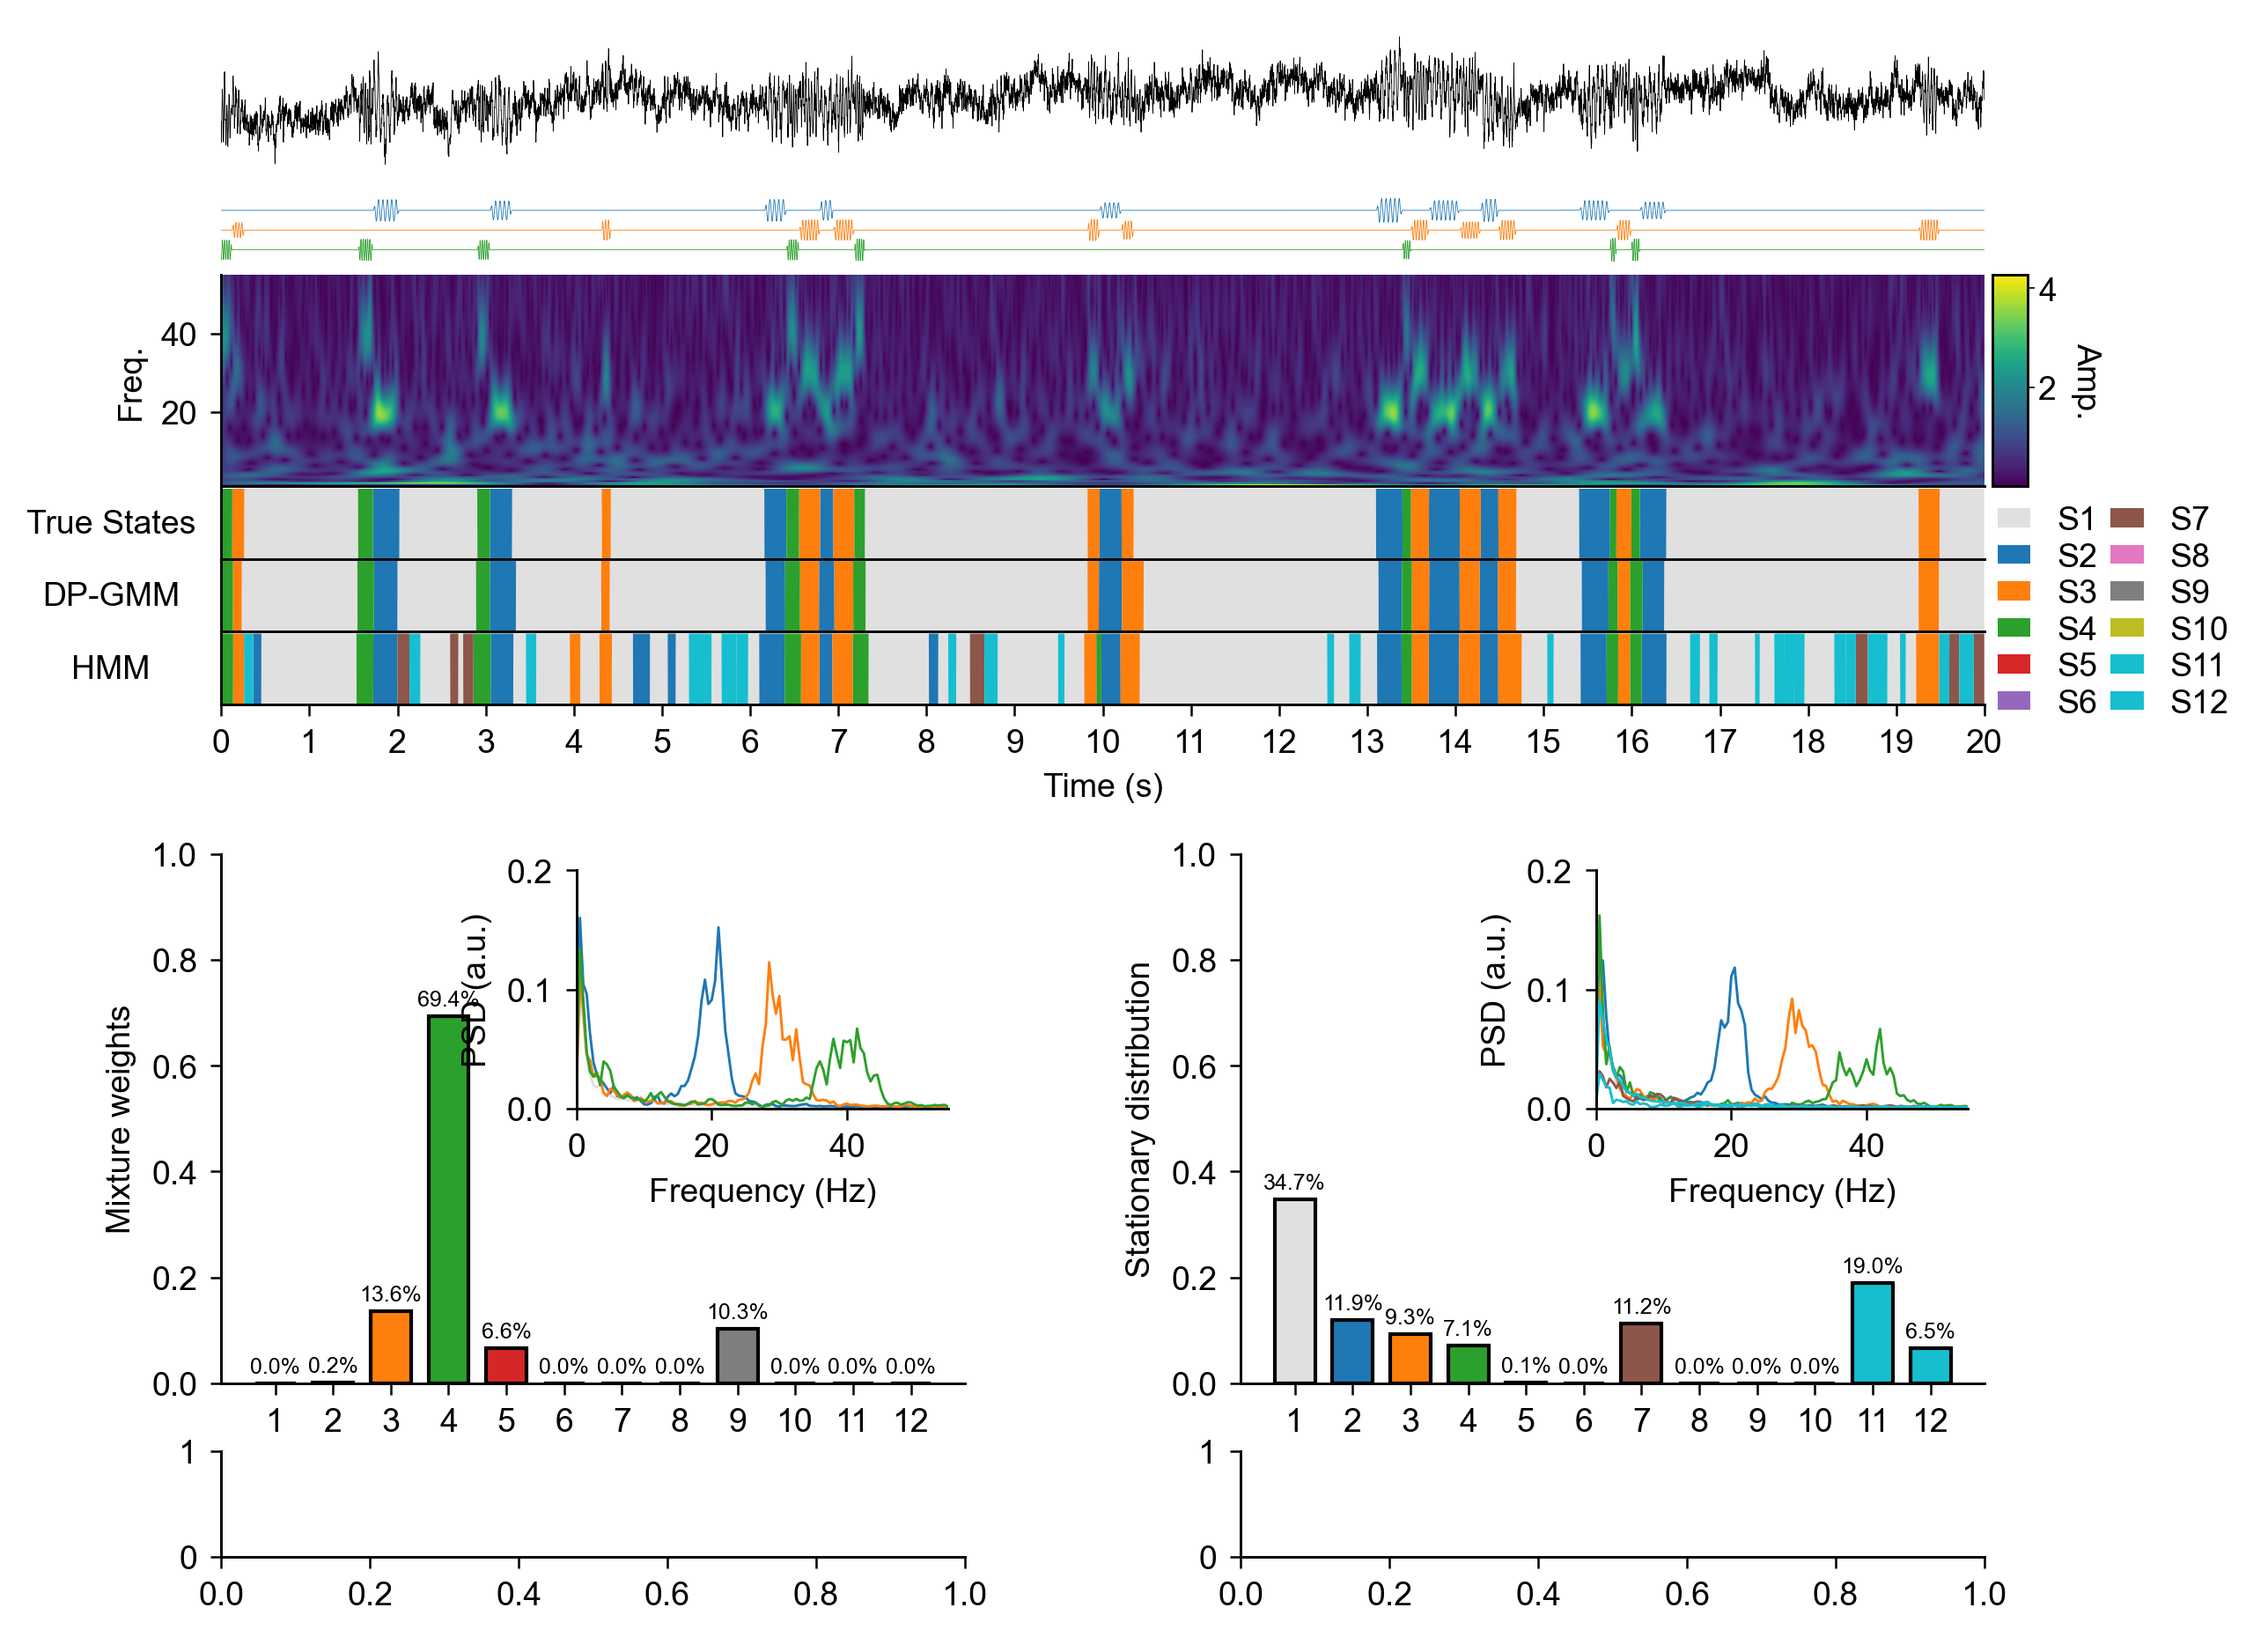

In [174]:

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(num_states)]
grey = ["#E0E0E0"]
colors = grey + colors
state_labels = [f"S{i+1}" for i in range(num_states)]

plot_t = 20


trimmed_states_onehot = np.eye(num_states)[trimmed_states]
t, f, amp = compute_wavelet(trimmed_signal[:plot_t*fs], fs, f_min = 1, f_max = 80, df = 0.5, wavelet = "cmor1.5-1.0")

mosaic = [["a1", "a1"],
          ["a2", "a2"],
          ["a3", "a3"],
          ["a4", "a4"],
          ["a5", "a5"],
          ["gap", "gap"],
          ["c", "b"],
          ["e", "d"],
         ]

fig, axes = plt.subplot_mosaic(
    mosaic,
    figsize=(FIG_WIDTH, 6.),  # a hair taller
    constrained_layout=True,
    gridspec_kw={"height_ratios":[0.7,0.6,0.2,0.2,0.2, 0.1 ,1.5, 0.3]}
)
fig.set_constrained_layout_pads(w_pad=0.0, h_pad=0., hspace=0.01)
axes["gap"].set_visible(False)


axes["a1"].plot(trimmed_time_vec[:plot_t*fs], trimmed_signal[:plot_t*fs], lw=0.2, color="k")
axes["a1"].set_frame_on(False)
#axes["a1"].set_title(f"Raw signal (SNR = {snr_db} dB)",pad= 0.3)

scale_burst = 1.7

axes["a1"].plot(trimmed_time_vec[:plot_t*fs], -5+ scale_burst * (trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 1)), lw=0.2, color=colors[1])
axes["a1"].plot(trimmed_time_vec[:plot_t*fs], -6+ scale_burst * (trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 2)), lw=0.2, color=colors[2])
axes["a1"].plot(trimmed_time_vec[:plot_t*fs], -7+ scale_burst * (trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 3)), lw=0.2, color=colors[3])



axes["a1"].set_yticks([])
axes["a1"].set_xticks([])





#axes["b1"].set_ylabel(f"{plot_f}Hz", fontsize = TINY_SIZE, rotation = 0, labelpad = 20)

for s in ("top","right","bottom","left"):
    axes["a1"].spines[s].set_visible(False)
axes["a1"].set_frame_on(False)
axes["a1"].tick_params(axis='both', which='both',
                       bottom=False, top=False, left=False, right=False,
                       labelbottom=False, labelleft=False)





im = axes["a2"].imshow(
    amp, extent=[t[0], t[-1], f[0], f[-1]],
    origin="lower", aspect="auto", cmap="viridis",
    vmin=amp.min(), vmax=amp.max()
)
axes["a2"].set_ylabel("Freq.")
#axes["a2"].set_title("Wavelet Transform",pad = 0.3)


axes["a2"].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, labeltop=False)
axes["a2"].yaxis.set_major_locator(MultipleLocator(20))

axes["a2"].set_ylim(1, 55)
axes["a2"].sharex(axes["a1"])


cax = inset_axes(
    axes["a2"],              # parent axis
    width="2%",              # width as percentage of a2
    height="100%",           # match the height
    loc="center right",      # position inside a2
    borderpad=-1.3             # negative value moves it outside slightly
)

# Add the colorbar to the inset axis
cb = fig.colorbar(im, cax=cax)
cb.set_label("Amp.", rotation = 270, labelpad = 12)
cb.ax.tick_params(which="both", length=2, width=0.4, pad=1)



axes["a3"].stackplot(trimmed_time_vec[:plot_t*fs], trimmed_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = state_labels)
axes["a3"].set_ylabel(f"True States", rotation = 0, labelpad=30, va="center")

axes["a4"].stackplot(trimmed_time_vec[:plot_t*fs], gmm_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = [f"MCC = {gmm_mcc:.2f}"] + [None]*(num_states-1))
axes["a4"].set_ylabel(f"DP-GMM", rotation = 0, labelpad=30, va="center")

axes["a5"].stackplot(trimmed_time_vec[:plot_t*fs], hmm_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels =  f"MCC = {hmm_mcc:.2f}")
axes["a5"].set_ylabel(f"HMM", rotation = 0, labelpad=30, va="center")



for key in ["a1","a2", "a3", "a4", "a5"]:
    axes[key].sharex(axes["a1"])

for key in ["a3", "a4"]:
    axes[key].tick_params(axis='x', which='both', bottom=True, labelbottom=False, length = 0)
    axes[key].tick_params(axis='y', which='both', left=False, labelleft=False)
    axes[key].set_yticks([])
    axes[key].set_xticks([])
    axes[key].spines["bottom"].set_visible(True)
    axes[key].set_ylim(0, 1)
    axes[key].set_xlim(0, plot_t)



axes["a5"].set_xlabel("Time (s)")
axes["a5"].xaxis.set_major_locator(MultipleLocator(1.0))
#axes["a5"].xaxis.set_minor_locator(MultipleLocator(0.5))
#axes["a5"].tick_params(axis='x', which='both', bottom=True, labelbottom=True, length = 0)
axes["a5"].tick_params(axis='y', which='both', left=False, labelleft=False)
axes["a5"].set_ylim(0, 1)
axes["a5"].set_xlim(0, plot_t)


axes["a5"].spines["bottom"].set_visible(True)   # keep x-axis frame




handles, labels = axes["a3"].get_legend_handles_labels()

fig.legend(handles, labels,
           loc="center left",          # anchor to left of the bbox
           bbox_to_anchor=(0.98, 0.63), # (x, y) in figure coordinates
           frameon=False,
           handlelength=1,
           handleheight=0.5,
           labelspacing = 0.2,
           ncol = 2,
           columnspacing = 0.4,
           )





for k, w in enumerate(stationary_dist):
    axes["b"].bar(k, w, width = 0.7, color = colors[k], zorder = 1, align = "center", edgecolor = "k")
    axes["b"].text(k, w + 0.02,"%.1f%%" % (w * 100.0), horizontalalignment="center", color = "k", fontsize = MY_FONT_SIZE - 3 )
    axes["b"].set_ylabel("Stationary distribution")
    axes["b"].set_xticks(np.arange(num_states), labels = np.arange(1, num_states + 1))
    axes["b"].tick_params(axis='y', )
    #axes["b"].spines["top"].set_visible(True)
    #axes["b"].spines["right"].set_visible(True)
    axes["b"].set_ylim(0, 1)

ax_b = inset_axes(axes["b"],
                      width = "50%", height = "45%",
                      loc = "upper right",
                      bbox_transform = axes["b"].transAxes,
                      borderpad = 0.5,)


for i in range(num_states):
    ax_b.plot(hmm_f[i], hmm_psds[i], color = colors[i], lw = 0.7)
    ax_b.set_xlim(0, 55)
    ax_b.set_ylim(0, 0.2)
    ax_b.set_xlabel("Frequency (Hz)", )
    ax_b.set_ylabel("PSD (a.u.)",)






for k, w in enumerate(untrunc_weights):
    axes["c"].bar(k, w, width = 0.7, color = colors[k], zorder = 1, align = "center", edgecolor = "k")
    axes["c"].text(k, w + 0.02,"%.1f%%" % (w * 100.0), horizontalalignment="center", color = "k" , fontsize = MY_FONT_SIZE - 3 )
    axes["c"].set_ylabel("Mixture weights")
    axes["c"].set_xticks(np.arange(num_states), labels = np.arange(1, num_states + 1))
    axes["c"].tick_params(axis='y')

   #axes["c"].spines["top"].set_visible(True)
    #axes["c"].spines["right"].set_visible(True)
    axes["c"].set_ylim(0, 1)


ab_c = inset_axes(axes["c"],
                  width = "50%", height = "45%",
                      loc = "upper right",
                      bbox_transform = axes["c"].transAxes,
                      borderpad = 0.5,)

for i in range(num_states):

    ab_c.plot(gmm_f[i], gmm_psds[i], color = colors[i], lw = 0.7)
    ab_c.set_xlim(0, 55)
    ab_c.set_xlabel("Frequency (Hz)")
    ab_c.set_ylabel("PSD (a.u.)")
    ab_c.set_ylim(0, 0.20)
    #ab_c.tick_params(axis="both", which="both", bottom = False, top = False, left = False, right = False)
    #ab_c.grid(False)


axes["d"].set_xlabel("HMM States")
axes["e"].set_xlabel("DP-GMM States")

for key in ["d", "e"]:
    axes[key].set_xticks([])
    axes[key].set_yticks([])
    axes[key].spines[:].set_visible(False)


fig.canvas.draw()
fig.savefig(
    f"../figures/{sim_cond}_results.jpg",
    bbox_inches="tight"
)


plt.show()



/var/folders/5z/yggynsqj6632pbql_bb3kqm40000gn/T/ipykernel_29629/319322124.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


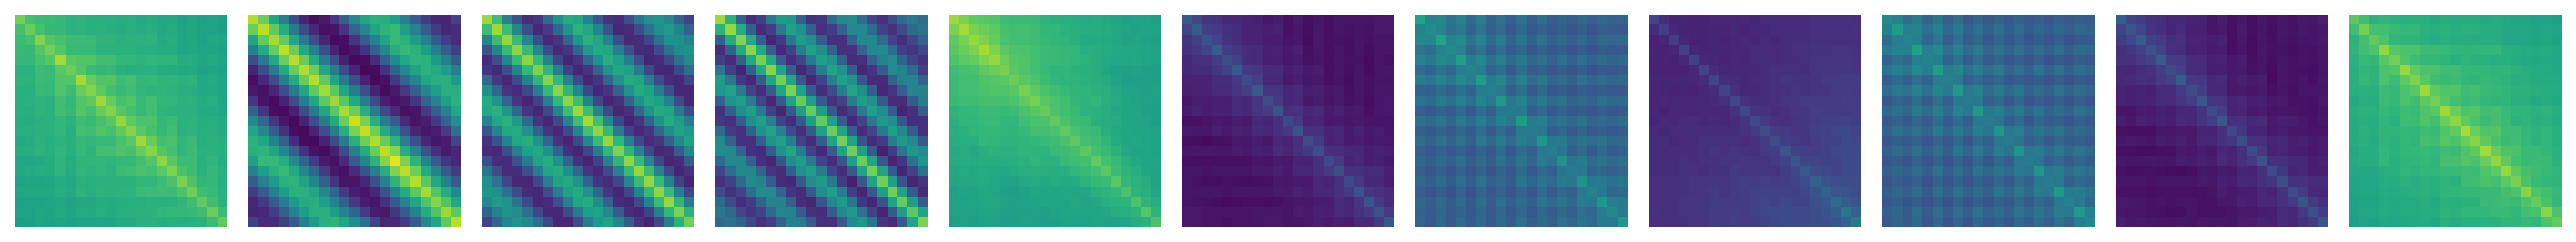

In [45]:
vmin  = np.min([untrunc_covs, hmm_covs])               # global minimum
vmax  = np.max([untrunc_covs, hmm_covs])               # global maximum
norm  = plt.Normalize(vmin, vmax)      # shared normalisation
fig, ax = plt.subplots(1, hmm_covs.shape[0], figsize = (untrunc_covs.shape[0]*2, 2), gridspec_kw = {"wspace":0.1})
for i ,cov in enumerate(hmm_covs):
    ax[i].imshow(cov, cmap = "viridis", norm = norm)
    ax[i].set_axis_off()

fig.savefig(
    f"../figures/{sim_cond}_hmm_covs.jpg",
    bbox_inches="tight",
    pad_inches=0.05,)


/var/folders/5z/yggynsqj6632pbql_bb3kqm40000gn/T/ipykernel_29629/4033313953.py:6: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/opt/anaconda3/envs/pymc_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


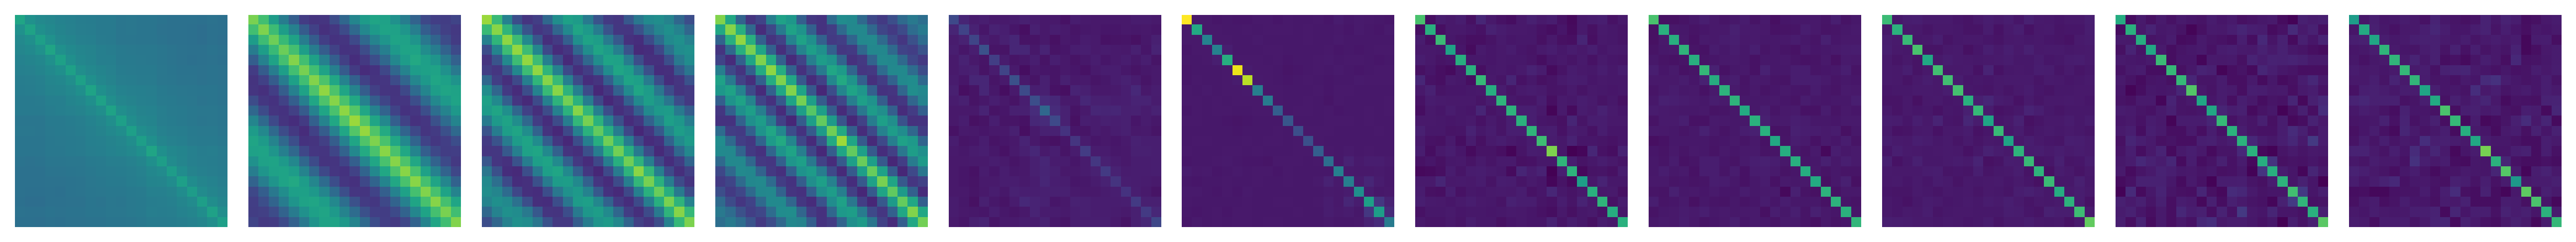

In [46]:

fig, ax = plt.subplots(1, untrunc_covs.shape[0], figsize = (untrunc_covs.shape[0]*2, 2), gridspec_kw = {"wspace":0.1})
for i ,cov in enumerate(untrunc_covs):
    ax[i].imshow(cov,  cmap = "viridis", norm = norm)
    ax[i].set_axis_off()

fig.savefig(
    f"../figures/{sim_cond}_gpgmm_covs.jpg",
    bbox_inches="tight",
    pad_inches=0.05,)


## states before imputation


In [47]:
_gmm_mcc = res.query("method == 'DP-GMM'").mcc.values[0]
_gmm_states = res.query("method == 'DP-GMM'").est_states.to_numpy()[0]
_gmm_states_onehot = np.eye(num_states)[_gmm_states]

_hmm_mcc = res.query("method == 'HMM'").mcc.values[0]
_hmm_states = res.query("method == 'HMM'").est_states.to_numpy()[0]
_hmm_states_onehot = np.eye(num_states)[_hmm_states]


print("dp-gmm", _gmm_mcc)
print("dp-gmm (imputed)", gmm_mcc)

print("hmm", _hmm_mcc)
print("hmm (imputed)", hmm_mcc)


"""
dp-gmm 0.8618107993142023
dp-gmm (imputed) 0.938337224764793
hmm 0.3483492480108877
hmm (imputed) 0.3112647340620908
"""

dp-gmm 0.8693541137545504
dp-gmm (imputed) 0.9350720693206954
hmm 0.3483492480108877
hmm (imputed) 0.3112647340620908


'\ndp-gmm 0.8618107993142023\ndp-gmm (imputed) 0.938337224764793\nhmm 0.3483492480108877\nhmm (imputed) 0.3112647340620908\n'

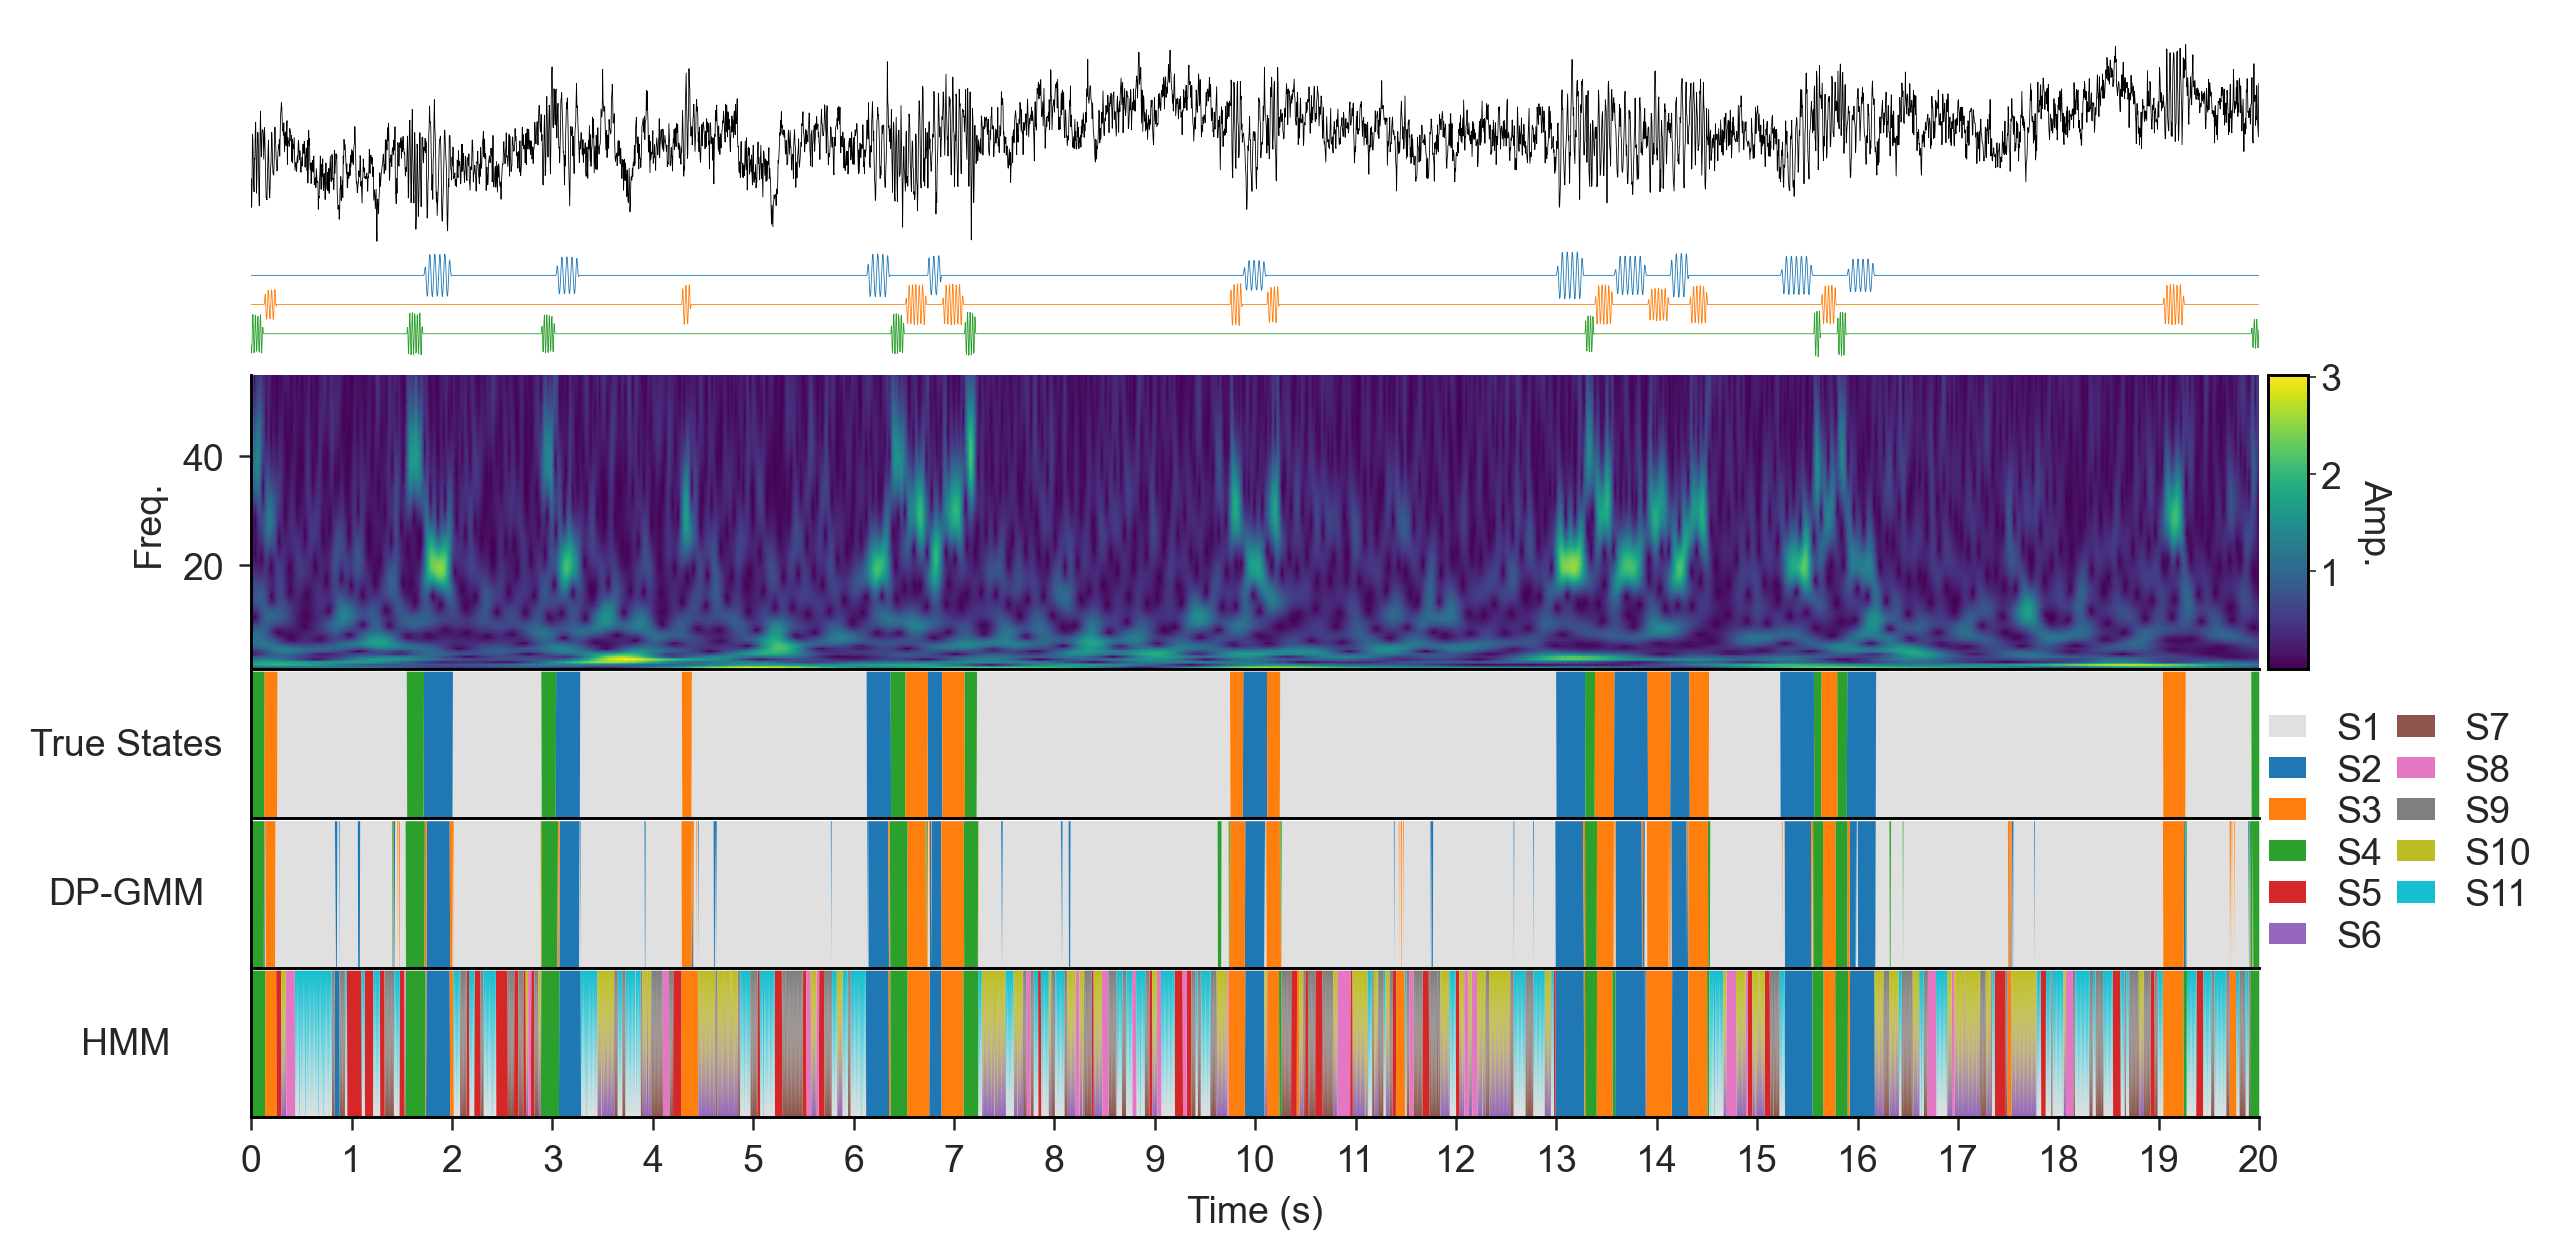

In [51]:

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(num_states)]
grey = ["#E0E0E0"]
colors = grey + colors
state_labels = [f"S{i+1}" for i in range(num_states)]

plot_t = 20


trimmed_states_onehot = np.eye(num_states)[trimmed_states]
t, f, amp = compute_wavelet(trimmed_signal[:plot_t*fs], fs, f_min = 1, f_max = 80, df = 0.5, wavelet = "cmor1.5-1.0")

mosaic = [["a1", "a1"],
          ["a2", "a2"],
          ["a3", "a3"],
          ["a4", "a4"],
          ["a5", "a5"],
         ]

fig, axes = plt.subplot_mosaic(
    mosaic,
    figsize=(FIG_WIDTH, 4.),  # a hair taller
    constrained_layout=True,
    gridspec_kw={"height_ratios":[0.7,0.6,0.3,0.3,0.3]}
)

fig.set_constrained_layout_pads(w_pad=0., h_pad=0., hspace=0.01)



axes["a1"].plot(trimmed_time_vec[:plot_t*fs], trimmed_signal[:plot_t*fs], lw=0.2, color="k")
axes["a1"].set_frame_on(False)
#axes["a1"].set_title(f"Raw signal (SNR = {snr_db} dB)",pad= 0.3)

scale_burst = 1.7

axes["a1"].plot(trimmed_time_vec[:plot_t*fs], -5+ scale_burst * (trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 1)), lw=0.2, color=colors[1])
axes["a1"].plot(trimmed_time_vec[:plot_t*fs], -6+ scale_burst * (trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 2)), lw=0.2, color=colors[2])
axes["a1"].plot(trimmed_time_vec[:plot_t*fs], -7+ scale_burst * (trimmed_bursts[:plot_t*fs] * (trimmed_states[:plot_t*fs] == 3)), lw=0.2, color=colors[3])



axes["a1"].set_yticks([])
axes["a1"].set_xticks([])





#axes["b1"].set_ylabel(f"{plot_f}Hz", fontsize = TINY_SIZE, rotation = 0, labelpad = 20)

for s in ("top","right","bottom","left"):
    axes["a1"].spines[s].set_visible(False)
axes["a1"].set_frame_on(False)
axes["a1"].tick_params(axis='both', which='both',
                       bottom=False, top=False, left=False, right=False,
                       labelbottom=False, labelleft=False)





im = axes["a2"].imshow(
    amp, extent=[t[0], t[-1], f[0], f[-1]],
    origin="lower", aspect="auto", cmap="viridis",
    vmin=amp.min(), vmax=amp.max()
)
axes["a2"].set_ylabel("Freq.")
#axes["a2"].set_title("Wavelet Transform",pad = 0.3)


axes["a2"].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, labeltop=False)
axes["a2"].yaxis.set_major_locator(MultipleLocator(20))

axes["a2"].set_ylim(1, 55)
axes["a2"].sharex(axes["a1"])


cax = inset_axes(
    axes["a2"],              # parent axis
    width="2%",              # width as percentage of a2
    height="100%",           # match the height
    loc="center right",      # position inside a2
    borderpad=-1.3             # negative value moves it outside slightly
)

# Add the colorbar to the inset axis
cb = fig.colorbar(im, cax=cax)
cb.set_label("Amp.", rotation = 270, labelpad = 12)
cb.ax.tick_params(which="both", length=2, width=0.4, pad=1)



axes["a3"].stackplot(trimmed_time_vec[:plot_t*fs], trimmed_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = state_labels)
axes["a3"].set_ylabel(f"True States", rotation = 0, labelpad=30, va="center")

axes["a4"].stackplot(trimmed_time_vec[:plot_t*fs], _gmm_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels = [f"MCC = {_gmm_mcc:.2f}"] + [None]*(num_states-1))
axes["a4"].set_ylabel(f"DP-GMM", rotation = 0, labelpad=30, va="center")

axes["a5"].stackplot(trimmed_time_vec[:plot_t*fs], _hmm_states_onehot[:plot_t*fs].T, linewidth = 0, colors = colors, labels =  f"MCC = {_hmm_mcc:.2f}")
axes["a5"].set_ylabel(f"HMM", rotation = 0, labelpad=30, va="center")



for key in ["a1","a2", "a3", "a4", "a5"]:
    axes[key].sharex(axes["a1"])

for key in ["a3", "a4"]:
    axes[key].tick_params(axis='x', which='both', bottom=True, labelbottom=False, length = 0)
    axes[key].tick_params(axis='y', which='both', left=False, labelleft=False)
    axes[key].set_yticks([])
    axes[key].set_xticks([])
    axes[key].spines["bottom"].set_visible(True)
    axes[key].set_ylim(0, 1)
    axes[key].set_xlim(0, plot_t)



axes["a5"].set_xlabel("Time (s)")
axes["a5"].xaxis.set_major_locator(MultipleLocator(1.0))
#axes["a5"].xaxis.set_minor_locator(MultipleLocator(0.5))
#axes["a5"].tick_params(axis='x', which='both', bottom=True, labelbottom=True, length = 0)
axes["a5"].tick_params(axis='y', which='both', left=False, labelleft=False)
axes["a5"].set_ylim(0, 1)
axes["a5"].set_xlim(0, plot_t)


axes["a5"].spines["bottom"].set_visible(True)   # keep x-axis frame




handles, labels = axes["a3"].get_legend_handles_labels()

fig.legend(handles, labels,
           loc="center left",          # anchor to left of the bbox
           bbox_to_anchor=(0.98, 0.33), # (x, y) in figure coordinates
           frameon=False,
           handlelength=1,
           handleheight=0.5,
           labelspacing = 0.2,
           ncol = 2,
           columnspacing = 0.4,
           )



fig.savefig(
    f"../figures/{sim_cond}_before_imputation.jpg",
    bbox_inches="tight",
    pad_inches=0.05,)


plt.show()



## HMM

In [55]:
import pickle
save_path = os.path.join(performance_dir, f"{sim_cond}_HMM_results.pkl")

# Load
with open(save_path, "rb") as f:
    res = pickle.load(f)

df_list = [pd.DataFrame(r) for r in res]
df = pd.concat(df_list, axis = 0, ignore_index = True)

df.head()


,method,signal,true_states,burst_f,fs,snr,est_params,best_model_id,loss_best,loss_all,fit_t,pred_t,total_time,num_states,num_emb,est_states,order,summary_stats,mcc,loss
0,HMM,"[0.598276138815683, 0.8167041652397233, 1.4131...",None,"[20, 30, 40]",250,0,"{'initial_probs': [0.74486524, 0.25513476], 't...",7,0.546423,"[[1.4314460714299742, 1.250953059730719, 1.151...",73.301494,0.523111,73.824605,2,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0]",None,None,0.546423
1,HMM,"[0.598276138815683, 0.8167041652397233, 1.4131...",None,"[20, 30, 40]",250,0,"{'initial_probs': [0.62651044, 0.20530105, 0.1...",2,0.539855,"[[1.6324689039241207, 1.2568464254477476, 1.15...",48.039872,0.367093,48.406966,3,21,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 2, 1]",None,None,0.539855
2,HMM,"[0.598276138815683, 0.8167041652397233, 1.4131...",None,"[20, 30, 40]",250,0,"{'initial_probs': [0.40047932, 0.14736506, 0.2...",0,0.530635,"[[1.4887848861504835, 1.4236964855674614, 1.27...",86.767325,0.171692,86.939017,4,21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[2, 1, 3, 0]",None,None,0.530635
3,HMM,"[0.598276138815683, 0.8167041652397233, 1.4131...",None,"[20, 30, 40]",250,0,"{'initial_probs': [0.32911584, 0.18618357, 0.1...",4,0.527656,"[[1.4836739567833206, 1.2856269277421006, 1.31...",106.047387,0.188655,106.236042,5,21,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[4, 2, 0, 3, 1]",None,None,0.527656
4,HMM,"[0.598276138815683, 0.8167041652397233, 1.4131...",None,"[20, 30, 40]",250,0,"{'initial_probs': [0.20053026, 0.22559878, 0.2...",3,0.518811,"[[1.5965215600881493, 1.1739165587918023, 1.13...",139.007899,0.206383,139.214281,6,21,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","[1, 0, 4, 3, 5, 2]",None,None,0.518811


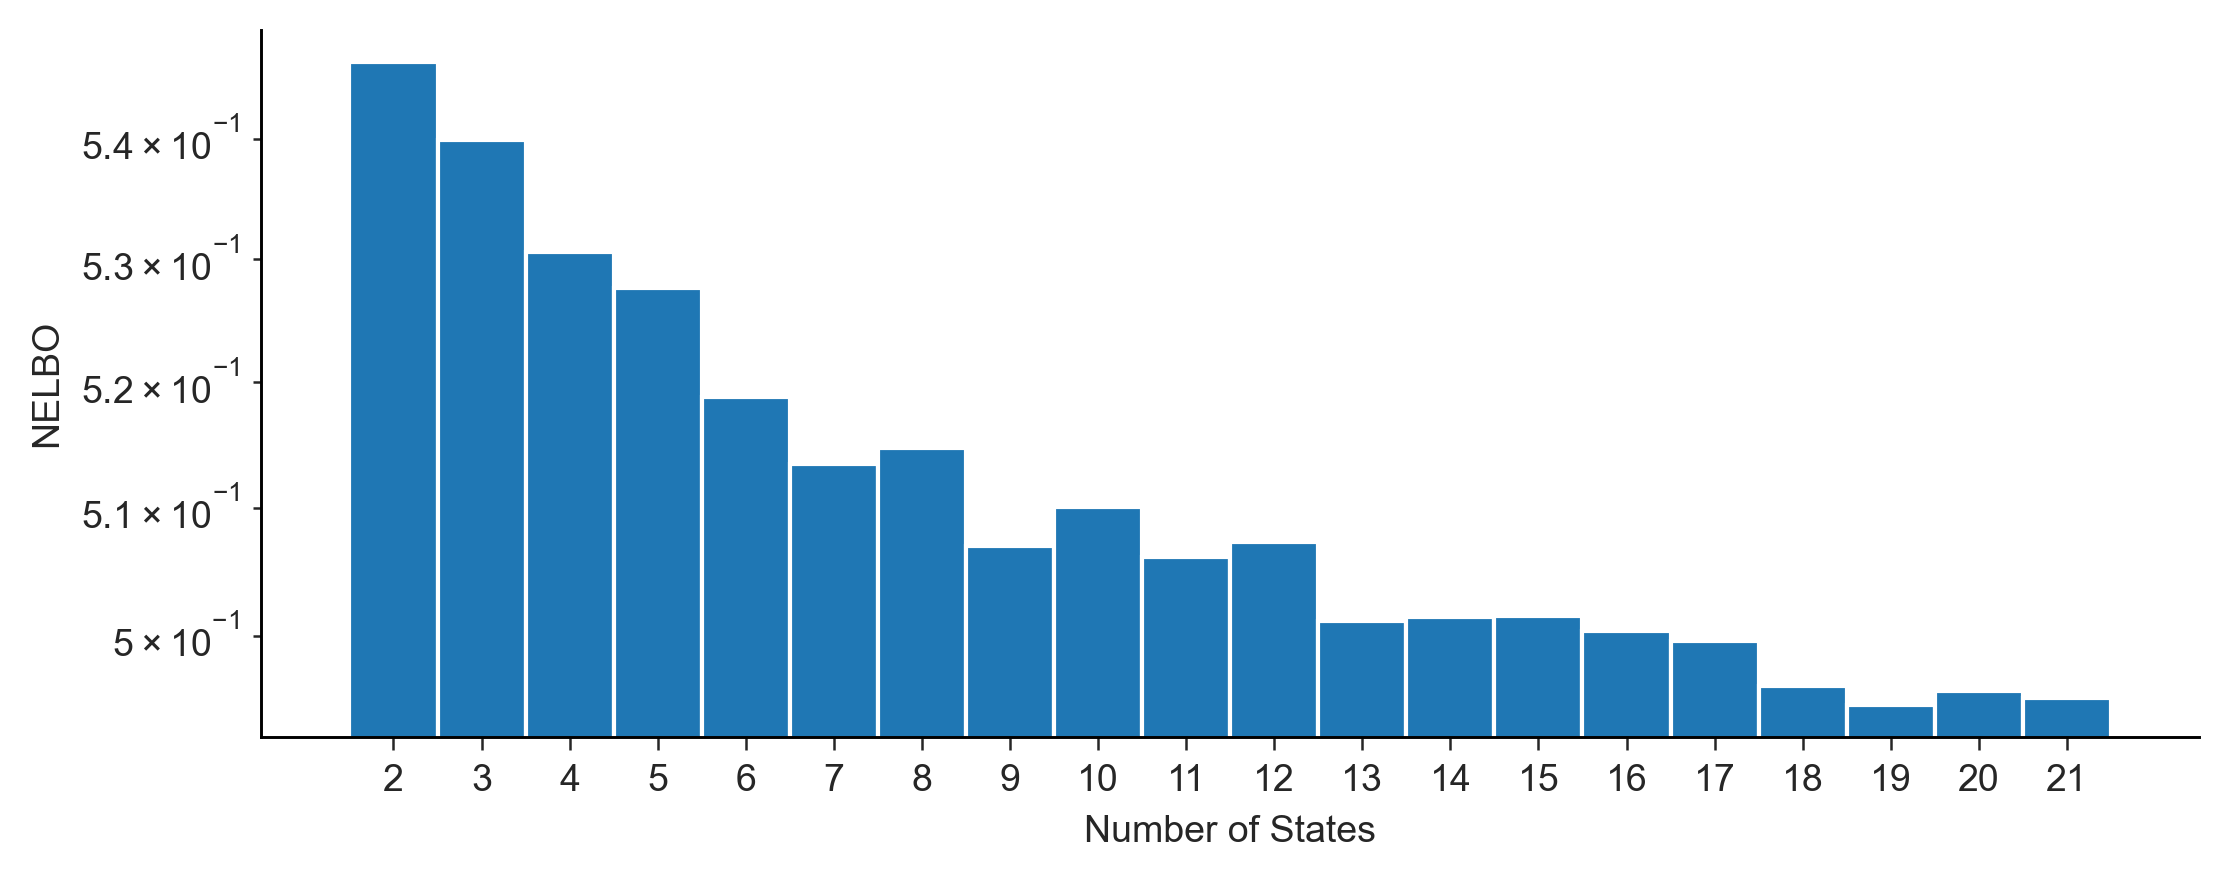

In [58]:
hmm_res = df.query("method == 'HMM'")
num_states_vec = hmm_res.num_states.to_numpy().astype(int)


hmm_color   = "#1f77b4"



elbos = hmm_res["loss_best"]
fig, ax = plt.subplots(figsize = (FIG_WIDTH, 3))
ax.bar(num_states_vec, elbos, color = hmm_color, width = 1, align = "center")
ax.set_yscale("log")
ax.set_xticks(num_states_vec)
ax.set_ylabel("NELBO")
ax.set_xlabel("Number of States")


fig.savefig(
    f"../figures/{sim_cond}_HMM_nelbo.jpg",
    bbox_inches="tight",
    pad_inches=0.05,)






